# Phân tích snake

### Model DQN với curriculum

Import và đọc cả 5 seed

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

# Chạy được cả khi Jupyter mở tại root hoặc thư mục notebook
ROOT = Path.cwd() 
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

results_dir = ROOT / "results" / "phase4" / "dqn_curriculum"
SEED = range(5) # 5 seeds
frames = []
for seed in SEED:
    csv_path = results_dir / f"seed_{seed}" / "episodes.csv"
    seed_df = pd.read_csv(csv_path)

    seed_df["seed"] = seed
    frames.append(seed_df)

episodes = pd.concat(frames, ignore_index=True)
# chuyển đổi cột "episode" sang kiểu int
episodes["episode"] = episodes["episode"].astype(int)
episodes["score"] = episodes["score"].astype(float)
episodes["steps"] = episodes["steps"].astype(int)
episodes["level"] = pd.Categorical(
    episodes["level"],
    categories=["level1", "level2", "level3", "level4"],
    ordered=True,
)
# death_cause rỗng ở episode đạt target không phải lỗi dữ liệu.
# Đây là episode kết thúc thành công vì master level.
episodes["death_cause"] = episodes["death_cause"].fillna("")
episodes["mastered_level"] = episodes["mastered_level"].fillna("")

episodes["outcome"] = episodes["death_cause"]
episodes.loc[
    episodes["mastered_level"].ne(""),
    "outcome"
] = "level_mastered"

episodes.loc[
    episodes["outcome"].eq(""),
    "outcome"
] = "unknown"

print("Shape:", episodes.shape)
display(episodes.head())

Shape: (15000, 9)


,episode,level,score,steps,death_cause,leveled_up,mastered_level,seed,outcome
0,1,level1,0.0,4,wall,False,,0,wall
1,2,level1,0.0,19,wall,False,,0,wall
2,3,level1,0.0,22,wall,False,,0,wall
3,4,level1,0.0,11,wall,False,,0,wall
4,5,level1,0.0,7,wall,False,,0,wall


Kiểm tra dữ liệu từng seed

In [2]:
data_check = (
    episodes.groupby("seed", observed=True)
    .agg(
        number_of_episodes=("episode", "count"),
        first_episode=("episode", "min"),
        last_episode=("episode", "max"),
        mean_score=("score", "mean"),
        max_score=("score", "max"),
        mean_steps=("steps", "mean"),
    )
    .round(3)
)

display(data_check)

,number_of_episodes,first_episode,last_episode,mean_score,max_score,mean_steps
seed,,,,,,
0,3000,1,3000,3.378,45.0,55.427
1,3000,1,3000,4.266,46.0,68.432
2,3000,1,3000,6.355,43.0,88.406
3,3000,1,3000,4.427,45.0,66.124
4,3000,1,3000,3.791,46.0,68.103


In [3]:
assert data_check["number_of_episodes"].eq(3000).all()
assert data_check["first_episode"].eq(1).all()
assert data_check["last_episode"].eq(3000).all()

print("Cả 5 seed đều có đủ 3.000 episode.")

Cả 5 seed đều có đủ 3.000 episode.


Bảng score theo seed và level

In [4]:
score_summary = (
    episodes.groupby(["seed", "level"], observed=True)
    .agg(
        episodes=("episode", "count"),
        mean_score=("score", "mean"),
        median_score=("score", "median"),
        std_score=("score", "std"),
        max_score=("score", "max"),
        p90_score=("score", lambda x: x.quantile(0.90)),
        mean_steps=("steps", "mean"),
    )
    .round(3)
    .reset_index()
)

display(score_summary)

,seed,level,episodes,mean_score,median_score,std_score,max_score,p90_score,mean_steps
0,0,level1,888,1.526,0.0,3.010,25.0,4.0,23.378
1,0,level2,504,2.006,0.5,4.254,35.0,5.0,43.333
2,0,level3,1031,6.470,1.0,9.642,45.0,23.0,91.997
3,0,level4,577,1.901,0.0,4.934,36.0,4.4,49.971
4,1,level1,863,1.714,0.0,3.340,25.0,5.0,24.527
5,1,level2,540,3.385,1.0,6.379,35.0,13.0,59.659
6,1,level3,1006,6.874,1.0,9.633,45.0,22.0,98.036
7,1,level4,591,4.357,0.0,8.566,46.0,19.0,90.168
8,2,level1,901,1.173,0.0,2.162,25.0,3.0,19.855
9,2,level2,564,3.679,1.0,6.896,35.0,15.0,61.656


Bảng dạng pivot để so sánh score trung bình

In [5]:
mean_score_table = score_summary.pivot(
    index="seed",
    columns="level",
    values="mean_score",
)

display(mean_score_table.round(3))

level,level1,level2,level3,level4
seed,,,,
0,1.526,2.006,6.470,1.901
1,1.714,3.385,6.874,4.357
2,1.173,3.679,10.379,NaN
3,1.556,1.751,8.874,0.303
4,1.547,2.309,3.253,7.791


Bảng score cao nhất

In [6]:
max_score_table = score_summary.pivot(
    index="seed",
    columns="level",
    values="max_score",
)

display(max_score_table)

level,level1,level2,level3,level4
seed,,,,
0,25.0,35.0,45.0,36.0
1,25.0,35.0,45.0,46.0
2,25.0,35.0,43.0,NaN
3,25.0,35.0,45.0,5.0
4,25.0,35.0,45.0,46.0


Learning curve của cả 5 seed

In [7]:
ROLLING_WINDOW = 100

episodes = episodes.sort_values(
    ["seed", "episode"]
).reset_index(drop=True)

episodes["rolling_score"] = (
    episodes.groupby(["seed", "level"], observed=True)["score"]
    .transform(
        lambda x: x.rolling(
            window=ROLLING_WINDOW,
            min_periods=20,
        ).mean()
    )
)

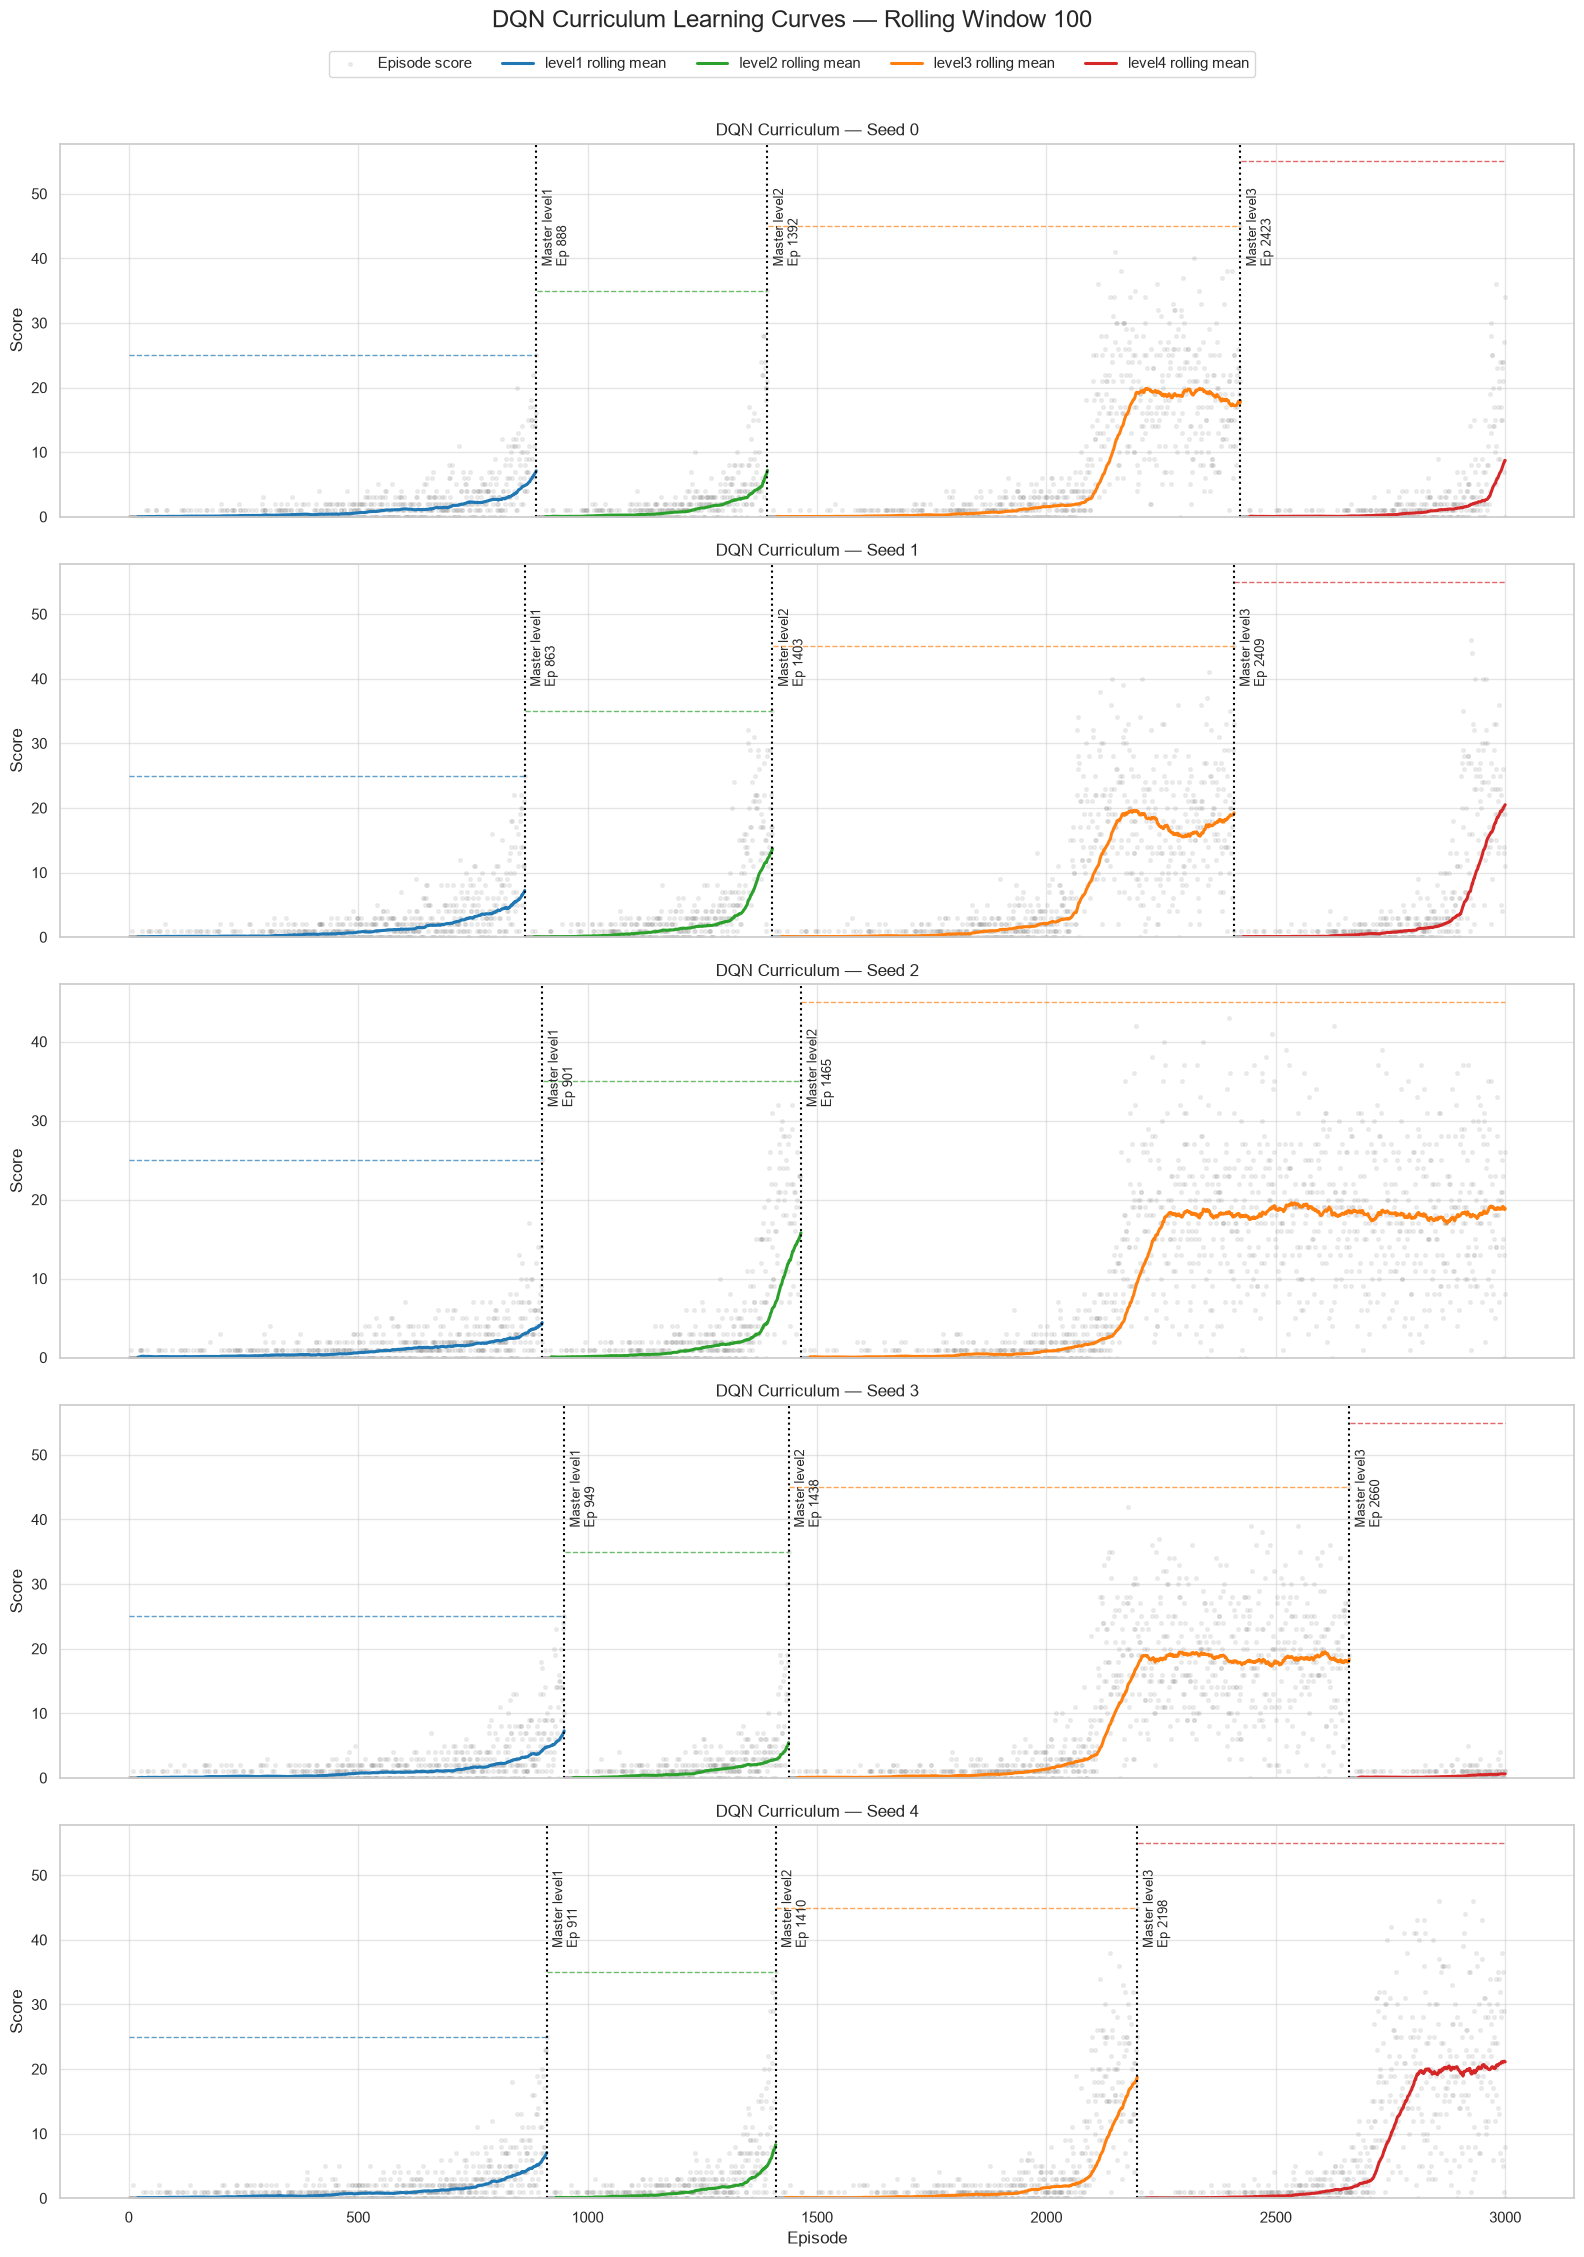

In [9]:
level_colors = {
    "level1": "#1f77b4",
    "level2": "#2ca02c",
    "level3": "#ff7f0e",
    "level4": "#d62728",
}

target_scores = {
    "level1": 25,
    "level2": 35,
    "level3": 45,
    "level4": 55,
}

fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(16, 22),
    sharex=True,
)

for seed, ax in zip(SEED, axes):
    seed_data = episodes[episodes["seed"] == seed]

    # Điểm thô từng episode
    ax.scatter(
        seed_data["episode"],
        seed_data["score"],
        s=7,
        color="gray",
        alpha=0.12,
        label="Episode score",
    )

    # Rolling score được vẽ riêng theo từng level
    for level in ["level1", "level2", "level3", "level4"]:
        level_data = seed_data[seed_data["level"] == level]

        if level_data.empty:
            continue

        ax.plot(
            level_data["episode"],
            level_data["rolling_score"],
            color=level_colors[level],
            linewidth=2.2,
            label=f"{level} rolling mean",
        )

        # Target của level trên đúng đoạn episode level đó xuất hiện
        ax.hlines(
            y=target_scores[level],
            xmin=level_data["episode"].min(),
            xmax=level_data["episode"].max(),
            color=level_colors[level],
            linestyle="--",
            linewidth=1,
            alpha=0.7,
        )

    # Mốc master level
    mastered_rows = seed_data[seed_data["mastered_level"].ne("")]

    for _, row in mastered_rows.iterrows():
        ax.axvline(
            row["episode"],
            color="black",
            linestyle=":",
            linewidth=1.5,
        )
        ax.text(
            row["episode"] + 10,
            ax.get_ylim()[1] * 0.88,
            f"Master {row['mastered_level']}\nEp {row['episode']}",
            fontsize=9,
            rotation=90,
            va="top",
        )

    ax.set_title(f"DQN Curriculum — Seed {seed}")
    ax.set_ylabel("Score")
    ax.set_ylim(bottom=0)

axes[-1].set_xlabel("Episode")

# Lấy legend duy nhất
handles, labels = axes[0].get_legend_handles_labels()
unique = dict(zip(labels, handles))
fig.legend(
    unique.values(),
    unique.keys(),
    loc="upper center",
    ncol=5,
    bbox_to_anchor=(0.5, 1.01),
)

fig.suptitle(
    f"DQN Curriculum Learning Curves — Rolling Window {ROLLING_WINDOW}",
    fontsize=17,
    y=1.025,
)

plt.tight_layout()
plt.show()

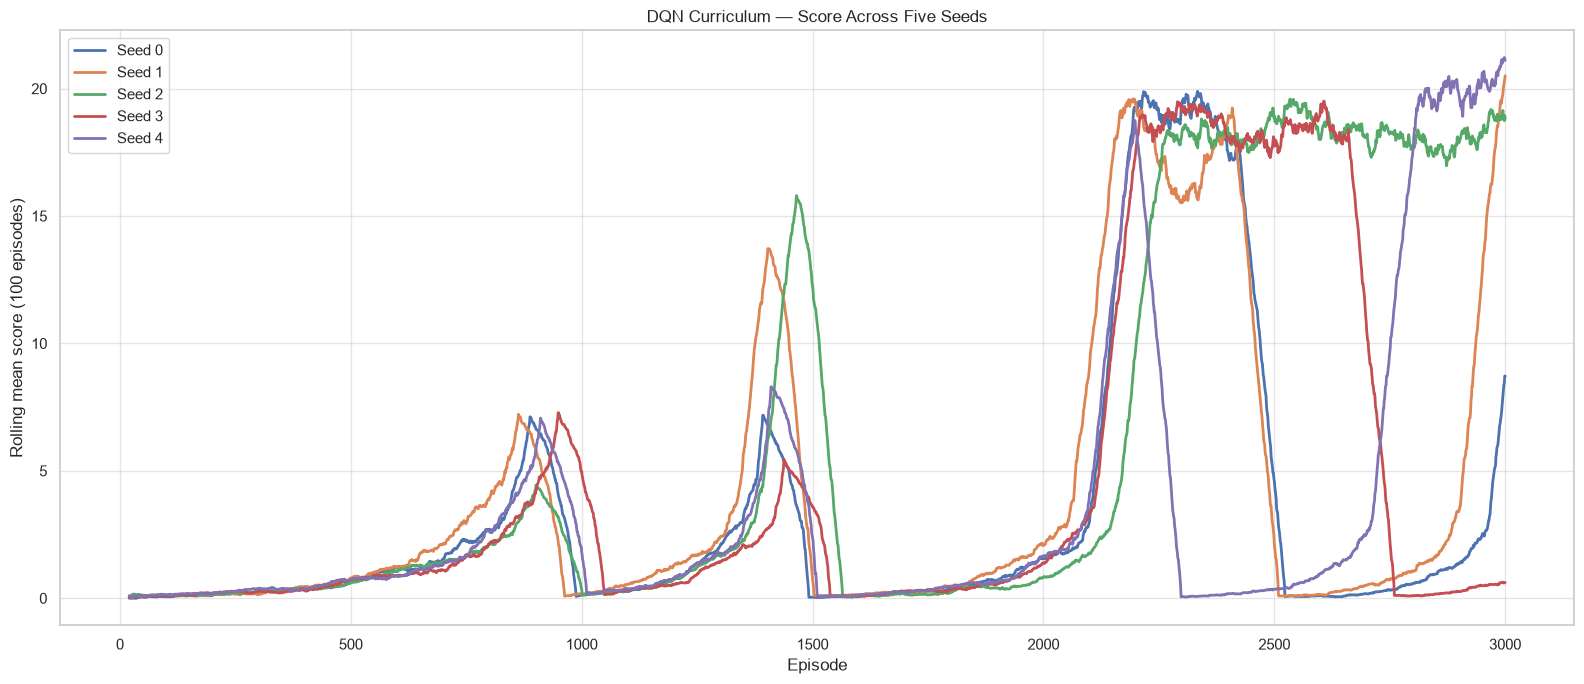

In [10]:
plt.figure(figsize=(16, 7))

for seed in SEED:
    seed_data = episodes[episodes["seed"] == seed]

    # Rolling toàn bộ run dùng cho mục đích so sánh seed.
    # Không dùng cột rolling_score theo level ở đây.
    full_rolling = (
        seed_data["score"]
        .rolling(window=100, min_periods=20)
        .mean()
    )

    plt.plot(
        seed_data["episode"],
        full_rolling,
        linewidth=2,
        label=f"Seed {seed}",
    )

plt.title("DQN Curriculum — Score Across Five Seeds")
plt.xlabel("Episode")
plt.ylabel("Rolling mean score (100 episodes)")
plt.legend()
plt.tight_layout()
plt.show()

Phân phối score theo level và seed

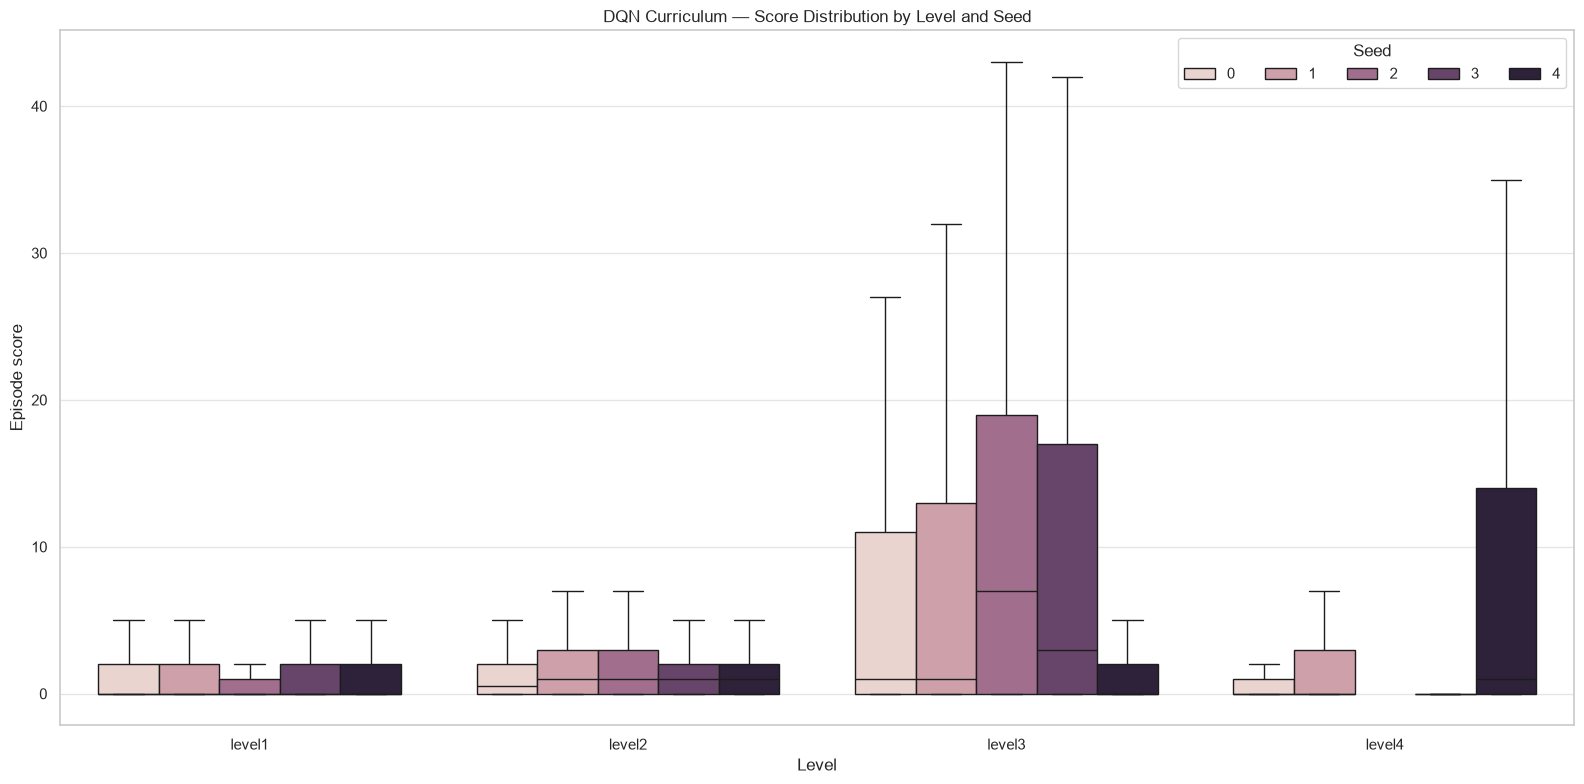

In [11]:
plt.figure(figsize=(16, 8))

sns.boxplot(
    data=episodes,
    x="level",
    y="score",
    hue="seed",
    showfliers=False,
)

plt.title("DQN Curriculum — Score Distribution by Level and Seed")
plt.xlabel("Level")
plt.ylabel("Episode score")
plt.legend(title="Seed", ncol=5)
plt.tight_layout()
plt.show()

Level-up timeline

In [12]:
mastery_timeline = (
    episodes.loc[
        episodes["mastered_level"].ne(""),
        [
            "seed",
            "episode",
            "level",
            "score",
            "mastered_level",
        ],
    ]
    .sort_values(["seed", "episode"])
    .reset_index(drop=True)
)

display(mastery_timeline)

,seed,episode,level,score,mastered_level
0,0,888,level1,25.0,level1
1,0,1392,level2,35.0,level2
2,0,2423,level3,45.0,level3
3,1,863,level1,25.0,level1
4,1,1403,level2,35.0,level2
5,1,2409,level3,45.0,level3
6,2,901,level1,25.0,level1
7,2,1465,level2,35.0,level2
8,3,949,level1,25.0,level1
9,3,1438,level2,35.0,level2


In [13]:
mastery_table = mastery_timeline.pivot(
    index="seed",
    columns="mastered_level",
    values="episode",
)

mastery_table = mastery_table.reindex(
    columns=["level1", "level2", "level3", "level4"]
)

display(mastery_table)

mastered_level,level1,level2,level3,level4
seed,,,,
0,888.0,1392.0,2423.0,NaN
1,863.0,1403.0,2409.0,NaN
2,901.0,1465.0,NaN,NaN
3,949.0,1438.0,2660.0,NaN
4,911.0,1410.0,2198.0,NaN


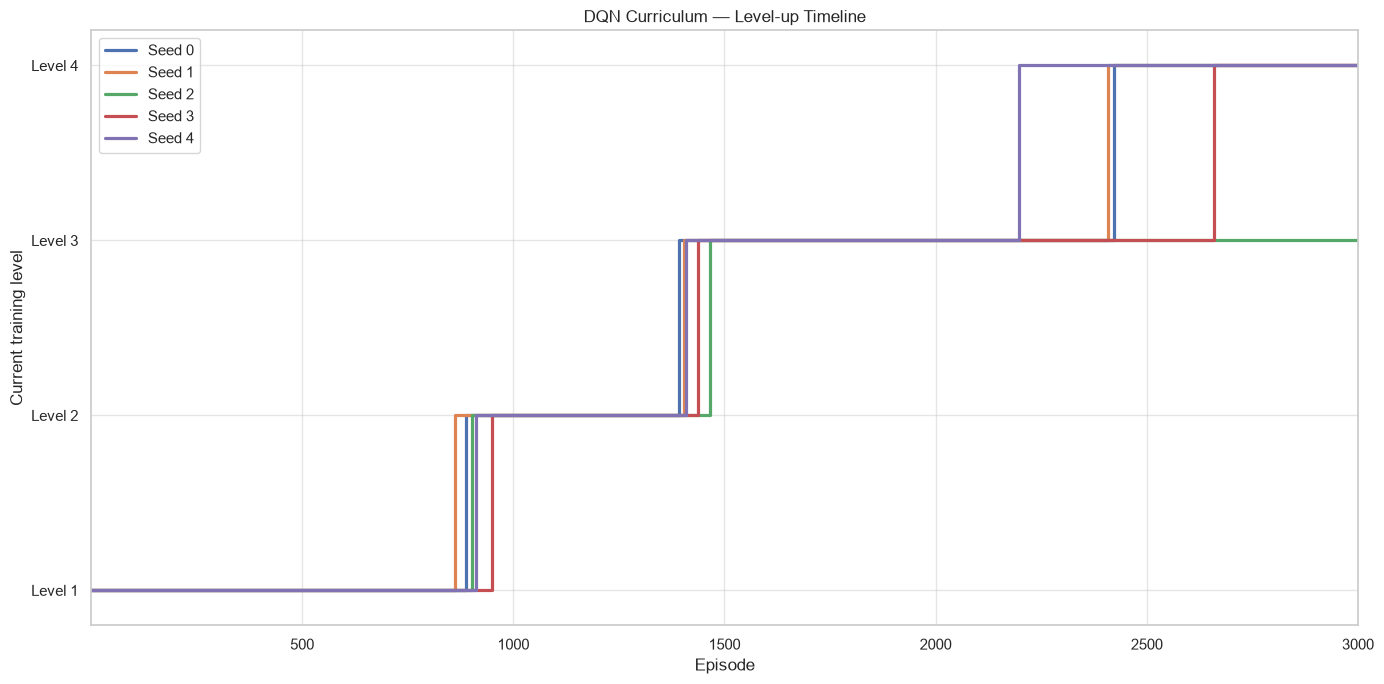

In [15]:
level_to_y = {
    "level1": 1,
    "level2": 2,
    "level3": 3,
    "level4": 4,
}

plt.figure(figsize=(14, 7))

for seed in SEED:
    seed_mastery = mastery_timeline[
        mastery_timeline["seed"] == seed
    ].copy()

    if seed_mastery.empty:
        continue

    x = [1]
    y = [1]

    for _, row in seed_mastery.iterrows():
        next_level_number = level_to_y[row["mastered_level"]] + 1

        x.extend([row["episode"], row["episode"]])
        y.extend([y[-1], next_level_number])

    x.append(3000)
    y.append(y[-1])

    plt.step(
        x,
        y,
        where="post",
        linewidth=2.3,
        label=f"Seed {seed}",
    )

plt.yticks(
    [1, 2, 3, 4],
    ["Level 1", "Level 2", "Level 3", "Level 4"],
)
plt.xlim(1, 3000)
plt.ylim(0.8, 4.2)
plt.xlabel("Episode")
plt.ylabel("Current training level")
plt.title("DQN Curriculum — Level-up Timeline")
plt.legend()
plt.tight_layout()
plt.show()

Thống kê nguyên nhân chết

In [16]:
death_summary = (
    episodes.groupby(
        ["seed", "level", "outcome"],
        observed=True,
    )
    .size()
    .rename("count")
    .reset_index()
)

death_summary["percentage"] = (
    death_summary["count"]
    / death_summary.groupby(
        ["seed", "level"],
        observed=True,
    )["count"].transform("sum")
    * 100
)

death_summary["percentage"] = death_summary["percentage"].round(2)

display(death_summary)

,seed,level,outcome,count,percentage
0,0,level1,level_mastered,1,0.11
1,0,level1,self,97,10.92
2,0,level1,wall,790,88.96
3,0,level2,level_mastered,1,0.20
4,0,level2,self,84,16.67
...,...,...,...,...,...
56,4,level3,self,122,15.48
57,4,level3,wall,451,57.23
58,4,level4,obstacle,216,26.93
59,4,level4,self,237,29.55


In [17]:
death_count_table = death_summary.pivot_table(
    index=["seed", "level"],
    columns="outcome",
    values="count",
    fill_value=0,
)

display(death_count_table)

outcome      level_mastered  obstacle   self   wall
seed level                                         
0    level1             1.0       0.0   97.0  790.0
     level2             1.0       0.0   84.0  419.0
     level3             1.0     258.0  279.0  493.0
     level4             0.0     195.0   53.0  329.0
1    level1             1.0       0.0  109.0  753.0
     level2             1.0       0.0  128.0  411.0
     level3             1.0     241.0  305.0  459.0
     level4             0.0     198.0  121.0  272.0
2    level1             1.0       0.0   80.0  820.0
     level2             1.0       0.0  130.0  433.0
     level3             0.0     290.0  662.0  583.0
3    level1             1.0       0.0  102.0  846.0
     level2             1.0       0.0   82.0  406.0
     level3             1.0     234.0  459.0  528.0
     level4             0.0     127.0    5.0  208.0
4    level1             1.0       0.0  108.0  802.0
     level2             1.0       0.0   75.0  423.0
     level3             1.0     214.0  122.0  451.0
     level4             0.0     216.0  237.0  349.0

In [18]:
death_rate_table = death_summary.pivot_table(
    index=["seed", "level"],
    columns="outcome",
    values="percentage",
    fill_value=0,
)

display(death_rate_table.round(2))

outcome      level_mastered  obstacle   self   wall
seed level                                         
0    level1            0.11      0.00  10.92  88.96
     level2            0.20      0.00  16.67  83.13
     level3            0.10     25.02  27.06  47.82
     level4            0.00     33.80   9.19  57.02
1    level1            0.12      0.00  12.63  87.25
     level2            0.19      0.00  23.70  76.11
     level3            0.10     23.96  30.32  45.63
     level4            0.00     33.50  20.47  46.02
2    level1            0.11      0.00   8.88  91.01
     level2            0.18      0.00  23.05  76.77
     level3            0.00     18.89  43.13  37.98
3    level1            0.11      0.00  10.75  89.15
     level2            0.20      0.00  16.77  83.03
     level3            0.08     19.15  37.56  43.21
     level4            0.00     37.35   1.47  61.18
4    level1            0.11      0.00  11.86  88.04
     level2            0.20      0.00  15.03  84.77
     level3            0.13     27.16  15.48  57.23
     level4            0.00     26.93  29.55  43.52

Stacked bar death cause cho từng seed và level

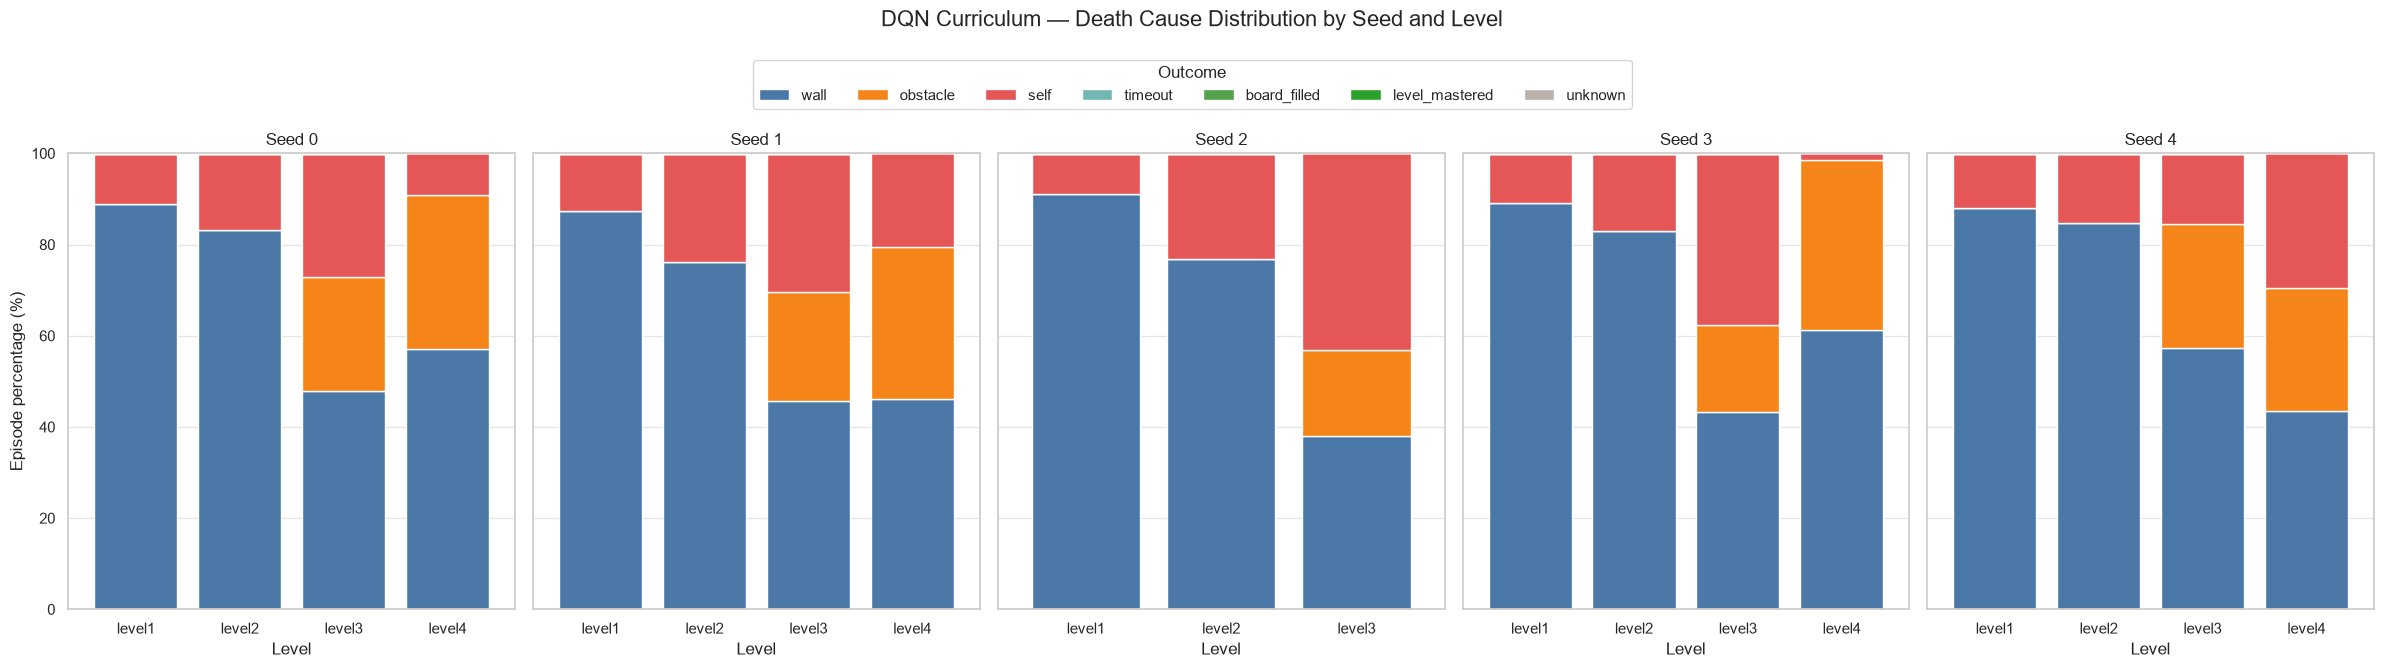

In [20]:
death_order = [
    "wall",
    "obstacle",
    "self",
    "timeout",
    "board_filled",
    "level_mastered",
    "unknown",
]

death_colors = {
    "wall": "#4c78a8",
    "obstacle": "#f58518",
    "self": "#e45756",
    "timeout": "#72b7b2",
    "board_filled": "#54a24b",
    "level_mastered": "#2ca02c",
    "unknown": "#bab0ac",
}

death_plot = (
    death_summary.pivot_table(
        index=["seed", "level"],
        columns="outcome",
        values="percentage",
        fill_value=0,
    )
    .reindex(columns=death_order, fill_value=0)
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=5,
    figsize=(24, 6),
    sharey=True,
)

for seed, ax in zip(SEED, axes):
    seed_plot = death_plot.loc[seed]

    seed_plot.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        color=[
            death_colors[column]
            for column in seed_plot.columns
        ],
        width=0.8,
        legend=False,
    )

    ax.set_title(f"Seed {seed}")
    ax.set_xlabel("Level")
    ax.set_ylabel("Episode percentage (%)" if seed == 0 else "")
    ax.tick_params(axis="x", rotation=0)
    ax.set_ylim(0, 100)

handles, labels = axes[-1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Outcome",
    loc="upper center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, 1.04),
)

fig.suptitle(
    "DQN Curriculum — Death Cause Distribution by Seed and Level",
    fontsize=16,
    y=1.11,
)

plt.tight_layout()
plt.show()

Death cause thay đổi theo thời gian

In [21]:
ROLLING_DEATH_WINDOW = 100
tracked_causes = ["wall", "obstacle", "self"]

for cause in tracked_causes:
    episodes[f"is_{cause}"] = (
        episodes["outcome"] == cause
    ).astype(float)

    episodes[f"rolling_{cause}_rate"] = (
        episodes.groupby("seed")[f"is_{cause}"]
        .transform(
            lambda x: x.rolling(
                ROLLING_DEATH_WINDOW,
                min_periods=20,
            ).mean() * 100
        )
    )

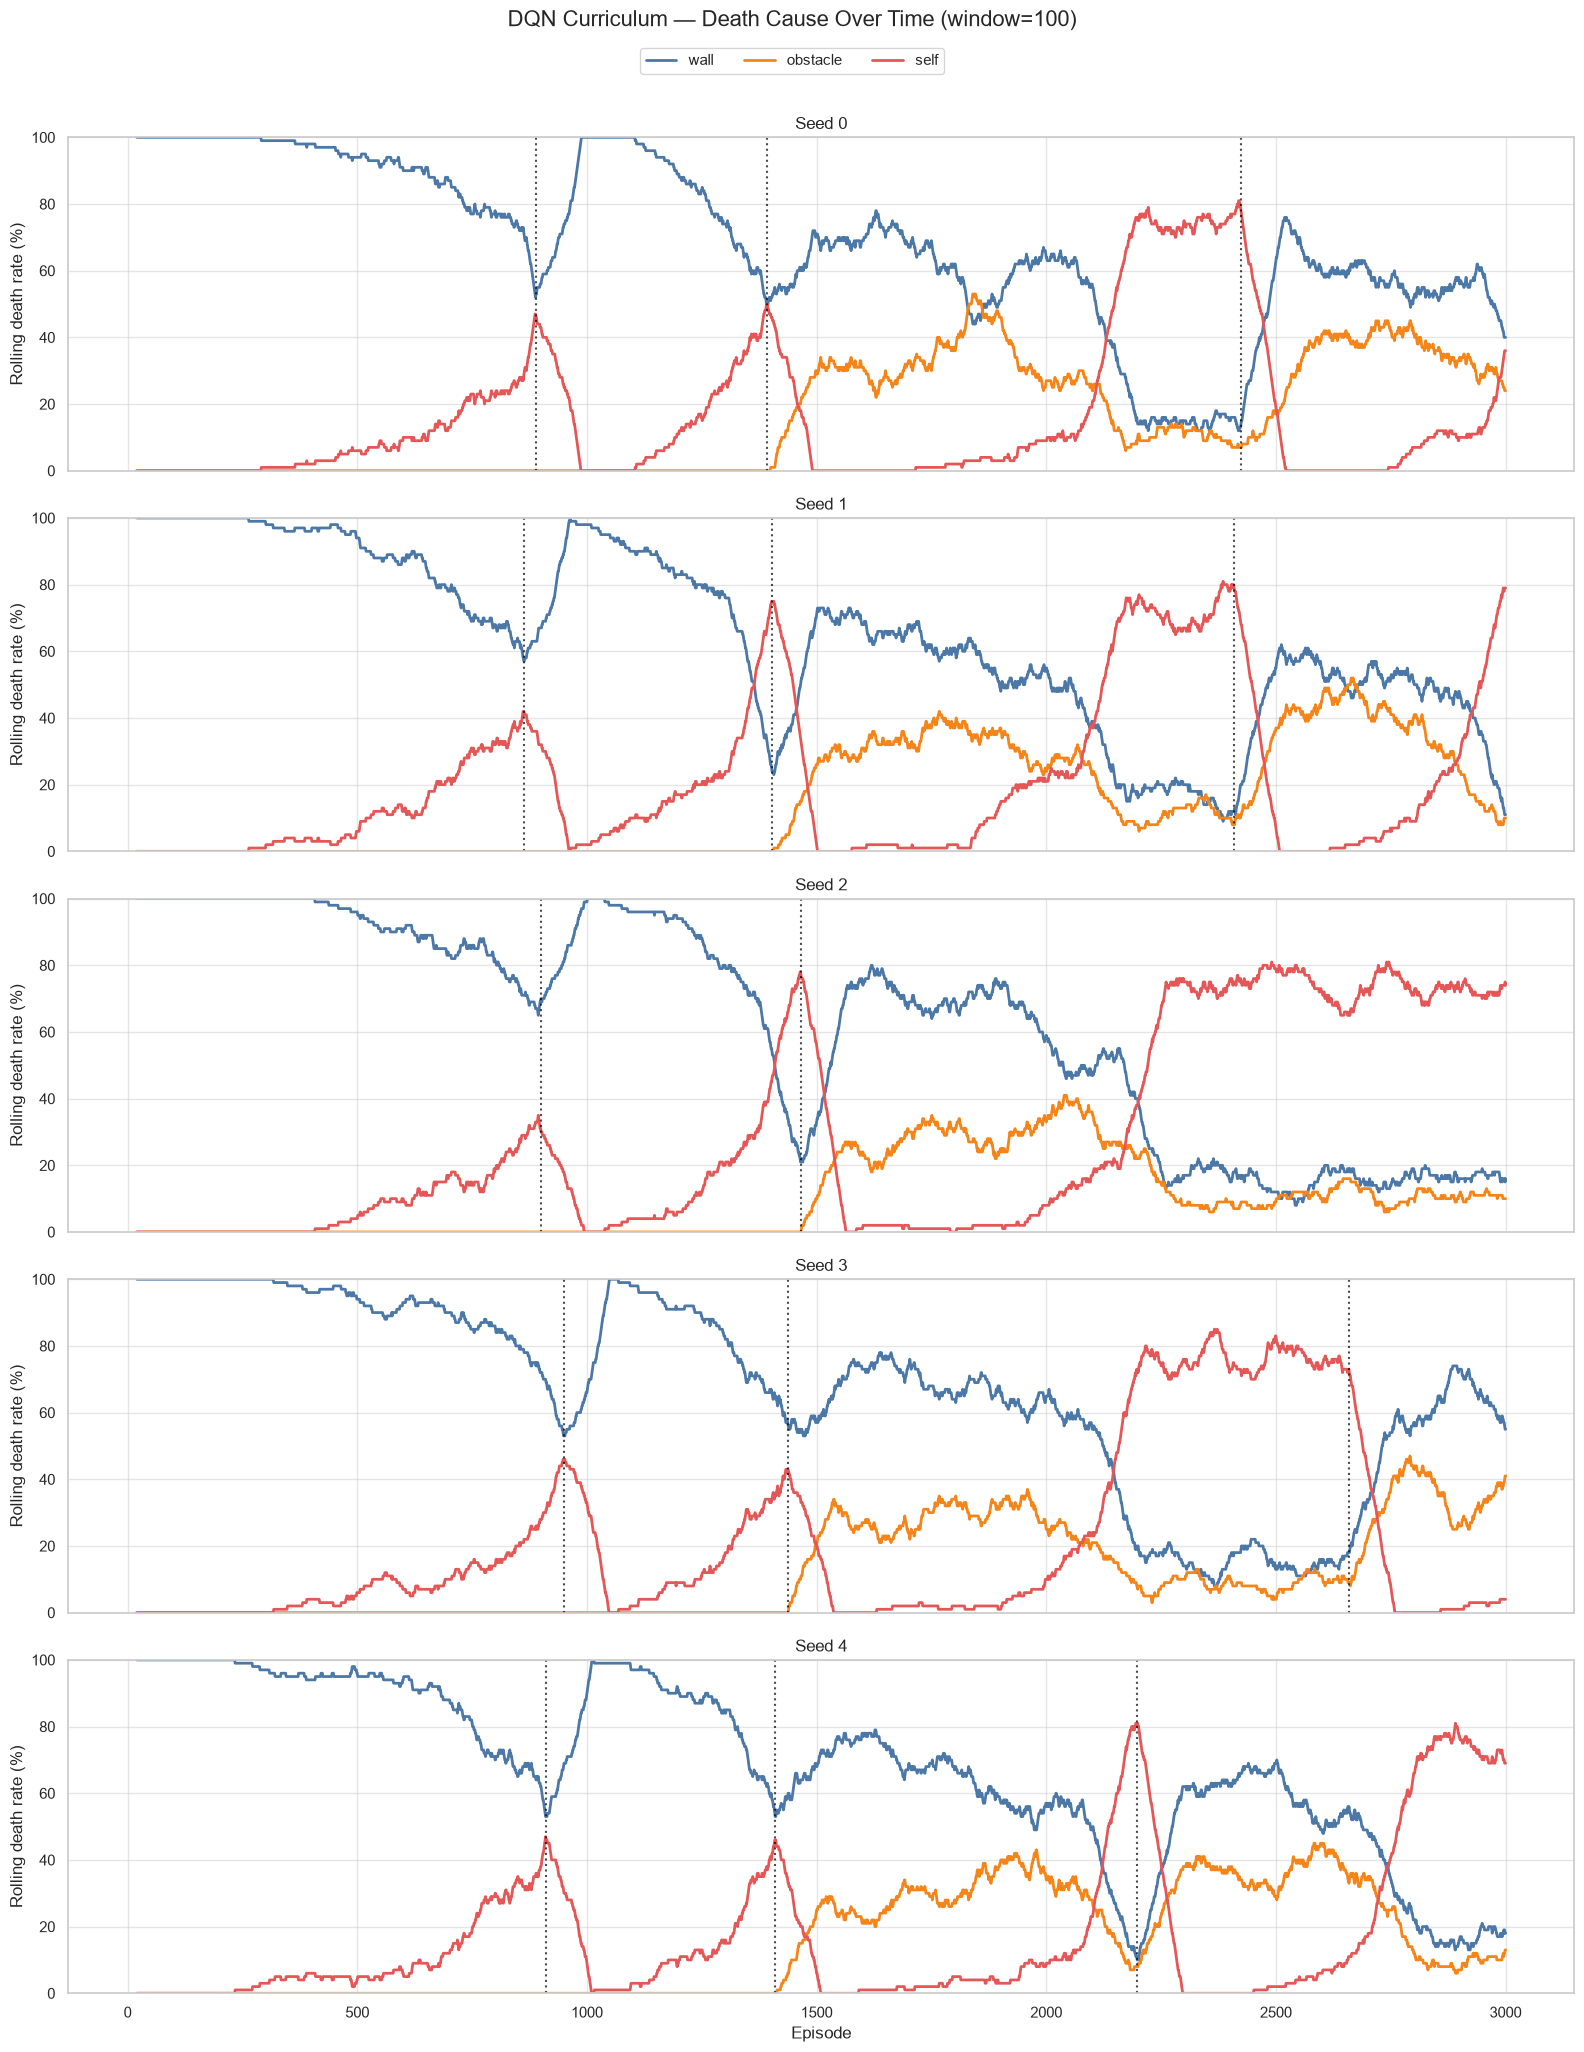

In [23]:
fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(16, 20),
    sharex=True,
    sharey=True,
)

cause_colors = {
    "wall": "#4c78a8",
    "obstacle": "#f58518",
    "self": "#e45756",
}

for seed, ax in zip(SEED, axes):
    seed_data = episodes[episodes["seed"] == seed]

    for cause in tracked_causes:
        ax.plot(
            seed_data["episode"],
            seed_data[f"rolling_{cause}_rate"],
            label=cause,
            color=cause_colors[cause],
            linewidth=2,
        )

    # Mốc chuyển level
    seed_mastery = seed_data[
        seed_data["mastered_level"].ne("")
    ]

    for _, row in seed_mastery.iterrows():
        ax.axvline(
            row["episode"],
            color="black",
            linestyle=":",
            alpha=0.7,
        )

    ax.set_title(f"Seed {seed}")
    ax.set_ylabel("Rolling death rate (%)")
    ax.set_ylim(0, 100)

axes[-1].set_xlabel("Episode")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.01),
)

fig.suptitle(
    f"DQN Curriculum — Death Cause Over Time "
    f"(window={ROLLING_DEATH_WINDOW})",
    fontsize=16,
    y=1.025,
)

plt.tight_layout()
plt.show()

Score trước và sau khi chuyển level

In [24]:
TRANSITION_WINDOW = 100

transition_rows = []

for _, mastery in mastery_timeline.iterrows():
    seed = mastery["seed"]
    mastery_episode = mastery["episode"]
    mastered_level = mastery["mastered_level"]

    seed_data = episodes[episodes["seed"] == seed]

    before = seed_data[
        seed_data["episode"].between(
            mastery_episode - TRANSITION_WINDOW,
            mastery_episode - 1,
        )
    ]

    after = seed_data[
        seed_data["episode"].between(
            mastery_episode + 1,
            mastery_episode + TRANSITION_WINDOW,
        )
    ]

    transition_rows.append(
        {
            "seed": seed,
            "mastered_level": mastered_level,
            "mastery_episode": mastery_episode,
            "mean_score_before": before["score"].mean(),
            "mean_score_after": after["score"].mean(),
            "score_change": (
                after["score"].mean()
                - before["score"].mean()
            ),
        }
    )

transition_analysis = pd.DataFrame(transition_rows).round(3)
display(transition_analysis)

,seed,mastered_level,mastery_episode,mean_score_before,mean_score_after,score_change
0,0,level1,888,6.88,0.07,-6.81
1,0,level2,1392,6.84,0.04,-6.80
2,0,level3,2423,17.59,0.07,-17.52
3,1,level1,863,6.98,0.08,-6.90
4,1,level2,1403,13.43,0.10,-13.33
5,1,level3,2409,19.00,0.10,-18.90
6,2,level1,901,4.20,0.12,-4.08
7,2,level2,1465,15.51,0.06,-15.45
8,3,level1,949,7.03,0.14,-6.89
9,3,level2,1438,5.13,0.09,-5.04


Hàm đọc dữ liệu dùng chung

In [25]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

PHASE4_DIR = ROOT / "results" / "phase4"

LEVEL_ORDER = ["level1", "level2", "level3", "level4"]

LEVEL_COLORS = {
    "level1": "#1f77b4",
    "level2": "#2ca02c",
    "level3": "#ff7f0e",
    "level4": "#d62728",
}

DEATH_ORDER = [
    "wall",
    "obstacle",
    "self",
    "timeout",
    "board_filled",
    "unknown",
]

DEATH_COLORS = {
    "wall": "#4c78a8",
    "obstacle": "#f58518",
    "self": "#e45756",
    "timeout": "#72b7b2",
    "board_filled": "#54a24b",
    "unknown": "#bab0ac",
}


def load_episode_logs(configuration, seeds=range(5)):
    frames = []

    for seed in seeds:
        csv_path = (
            PHASE4_DIR
            / configuration
            / f"seed_{seed}"
            / "episodes.csv"
        )

        seed_df = pd.read_csv(csv_path)
        seed_df["seed"] = seed
        seed_df["configuration"] = configuration
        frames.append(seed_df)

    data = pd.concat(frames, ignore_index=True)

    data["episode"] = data["episode"].astype(int)
    data["score"] = data["score"].astype(float)
    data["steps"] = data["steps"].astype(int)

    data["level"] = pd.Categorical(
        data["level"],
        categories=LEVEL_ORDER,
        ordered=True,
    )

    data["death_cause"] = (
        data["death_cause"]
        .fillna("")
        .replace("", "unknown")
    )

    data["mastered_level"] = (
        data["mastered_level"]
        .fillna("")
    )

    return data.sort_values(
        ["seed", "episode"]
    ).reset_index(drop=True)

In [26]:
dqn_fixed = load_episode_logs("dqn_fixed")
dqn_random = load_episode_logs("dqn_random_dr")

print("DQN Fixed:", dqn_fixed.shape)
print("DQN Random DR:", dqn_random.shape)

DQN Fixed: (15000, 9)
DQN Random DR: (15000, 9)


DQN Fixed

In [27]:
fixed_level_counts = (
    dqn_fixed.groupby(
        ["seed", "level"],
        observed=True,
    )
    .size()
    .rename("episodes")
    .reset_index()
)

display(fixed_level_counts)

,seed,level,episodes
0,0,level4,3000
1,1,level4,3000
2,2,level4,3000
3,3,level4,3000
4,4,level4,3000


In [28]:
assert dqn_fixed["level"].dropna().eq("level4").all()
assert dqn_fixed.groupby("seed").size().eq(3000).all()

print("DQN Fixed: cả 5 seed đều train 3.000 episode trên Level 4.")

DQN Fixed: cả 5 seed đều train 3.000 episode trên Level 4.


Bảng score của 5 seed

In [29]:
fixed_score_summary = (
    dqn_fixed.groupby("seed")
    .agg(
        episodes=("episode", "count"),
        mean_score=("score", "mean"),
        median_score=("score", "median"),
        std_score=("score", "std"),
        max_score=("score", "max"),
        p90_score=("score", lambda x: x.quantile(0.90)),
        mean_steps=("steps", "mean"),
        max_steps=("steps", "max"),
    )
    .round(3)
)

display(fixed_score_summary)

,episodes,mean_score,median_score,std_score,max_score,p90_score,mean_steps,max_steps
seed,,,,,,,,
0,3000,17.297,18.0,11.910,55.0,33.0,281.789,1040
1,3000,17.321,18.0,11.962,57.0,33.0,285.734,1080
2,3000,16.631,17.0,11.858,56.0,32.0,277.213,1110
3,3000,17.192,17.0,12.071,57.0,33.0,284.107,1143
4,3000,17.046,17.0,11.621,61.0,32.0,281.002,1067


In [30]:
fixed_progress_rows = []

for seed, seed_data in dqn_fixed.groupby("seed"):
    first_500 = seed_data.nsmallest(500, "episode")
    last_500 = seed_data.nlargest(500, "episode")

    fixed_progress_rows.append(
        {
            "seed": seed,
            "first_500_mean": first_500["score"].mean(),
            "last_500_mean": last_500["score"].mean(),
            "improvement": (
                last_500["score"].mean()
                - first_500["score"].mean()
            ),
        }
    )

fixed_progress = pd.DataFrame(
    fixed_progress_rows
).round(3)

display(fixed_progress)

,seed,first_500_mean,last_500_mean,improvement
0,0,0.700,21.628,20.928
1,1,0.534,20.154,19.620
2,2,0.328,20.186,19.858
3,3,0.512,20.862,20.350
4,4,0.600,20.224,19.624


Learning curve Fixed cho từng seed

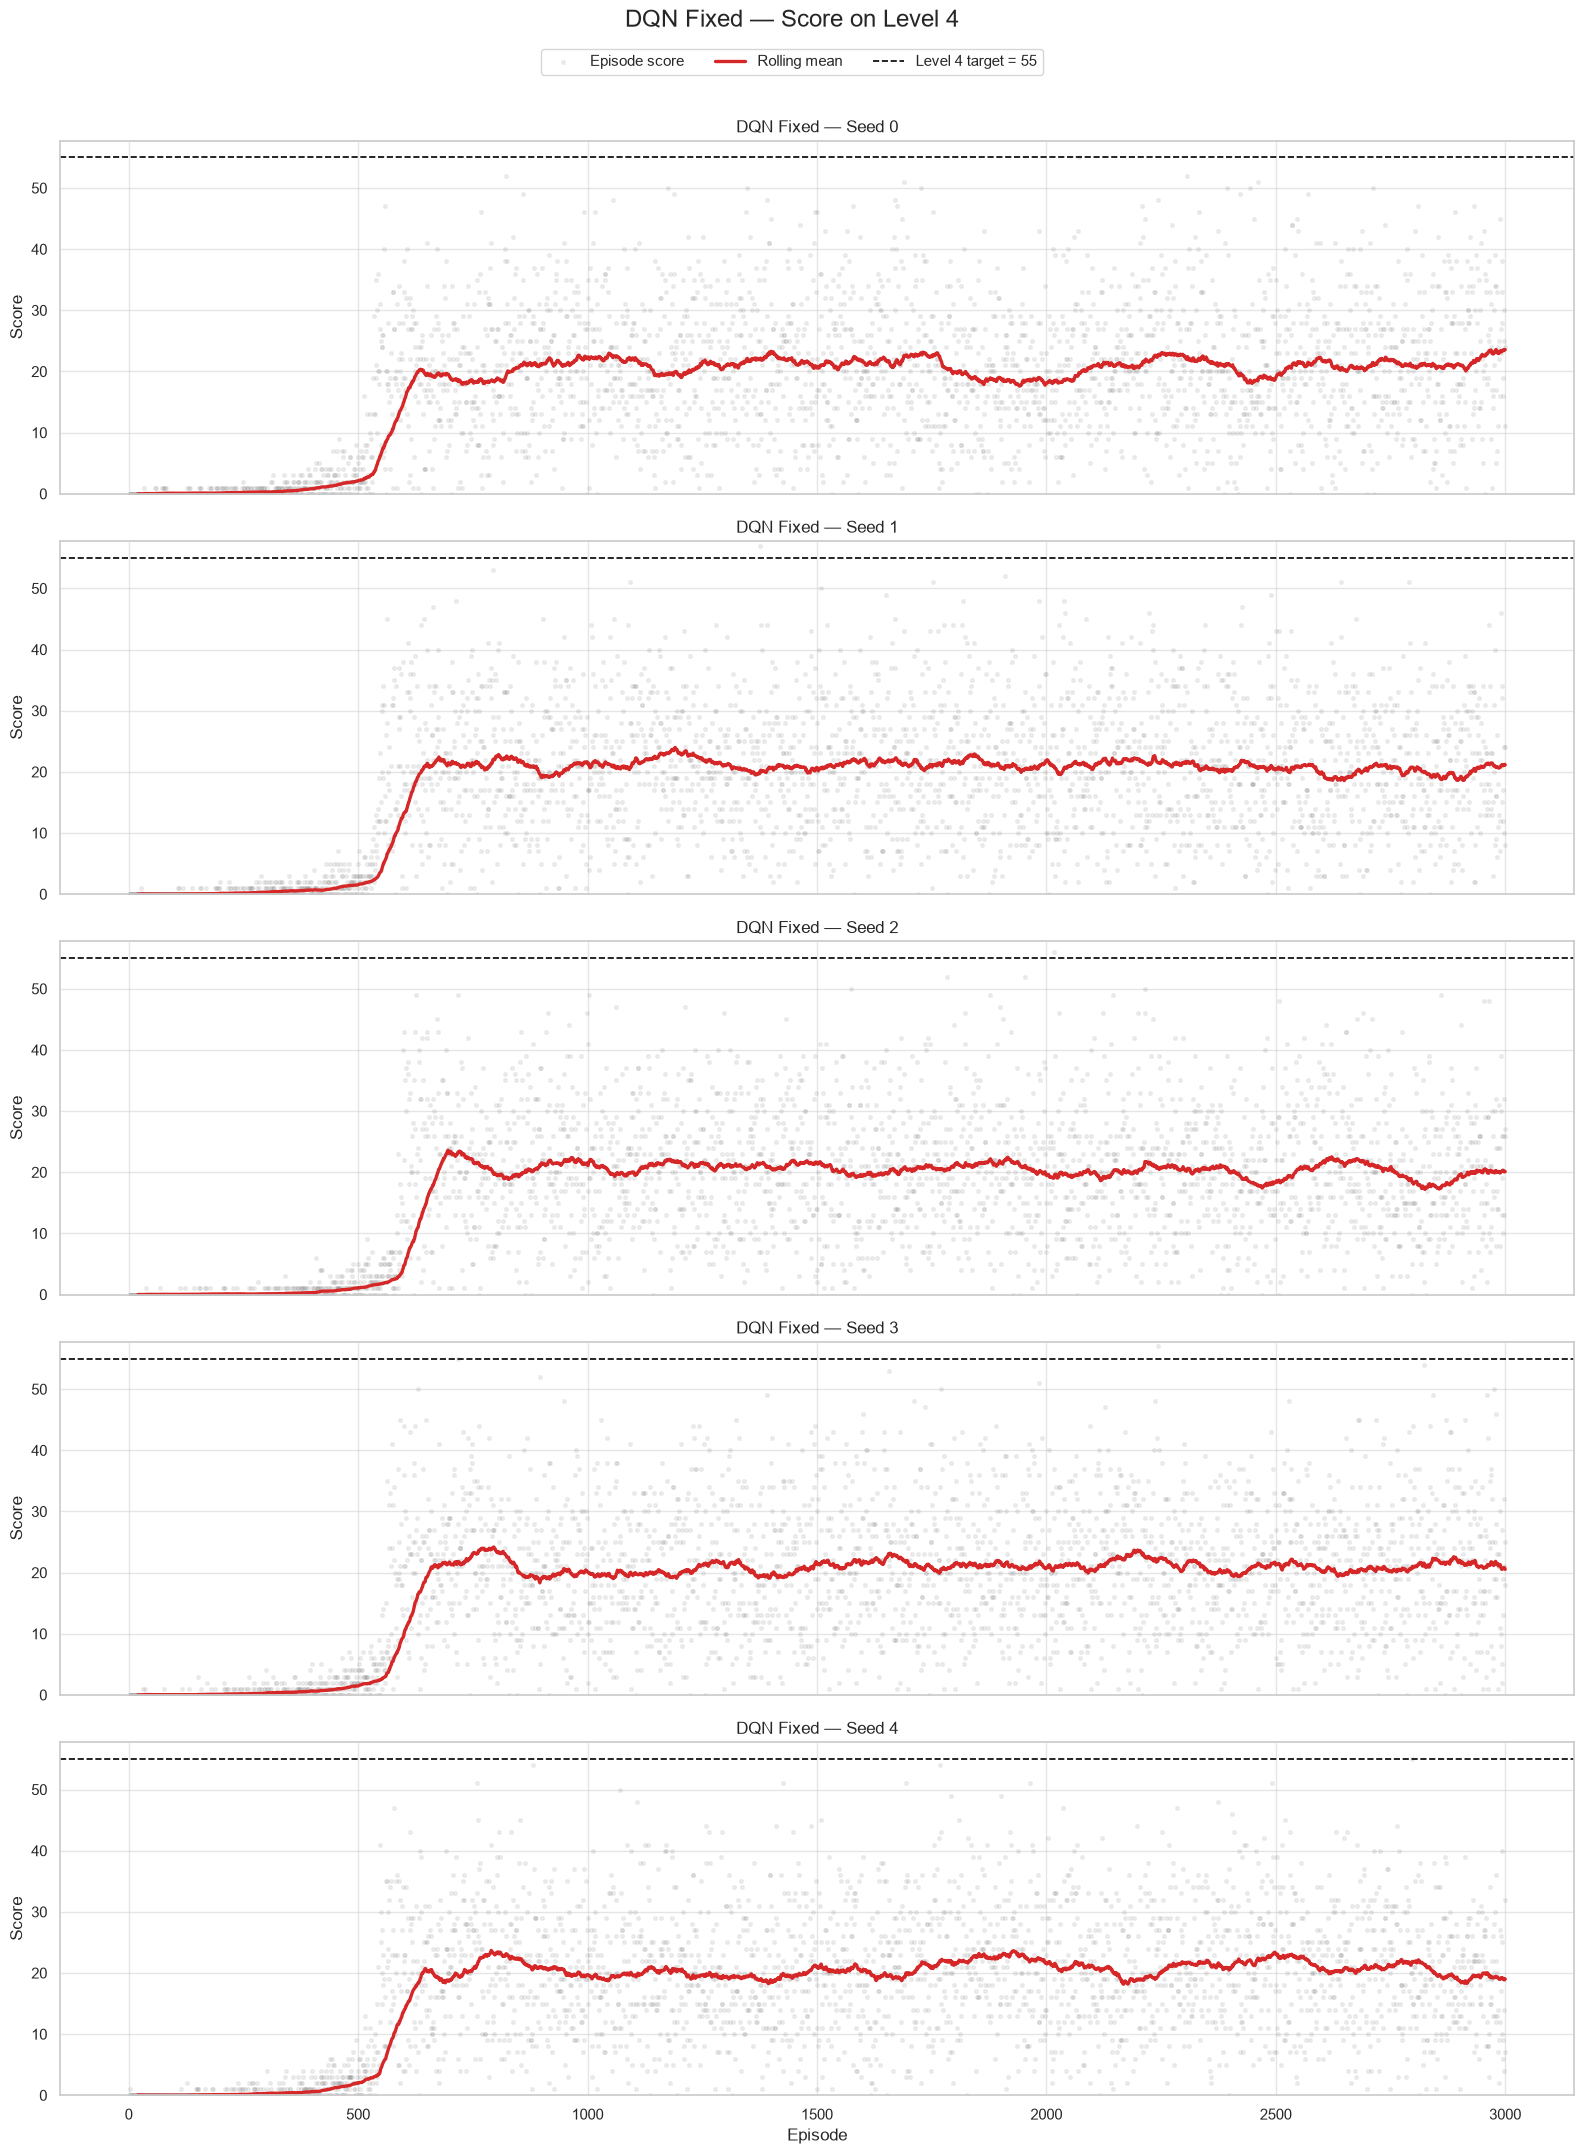

In [31]:
ROLLING_WINDOW = 100

dqn_fixed["rolling_score"] = (
    dqn_fixed.groupby("seed")["score"]
    .transform(
        lambda x: x.rolling(
            ROLLING_WINDOW,
            min_periods=20,
        ).mean()
    )
)

fig, axes = plt.subplots(
    nrows=5,
    ncols=1,
    figsize=(16, 21),
    sharex=True,
    sharey=True,
)

for seed, ax in zip(range(5), axes):
    seed_data = dqn_fixed[
        dqn_fixed["seed"] == seed
    ]

    ax.scatter(
        seed_data["episode"],
        seed_data["score"],
        s=7,
        alpha=0.12,
        color="gray",
        label="Episode score",
    )

    ax.plot(
        seed_data["episode"],
        seed_data["rolling_score"],
        linewidth=2.4,
        color=LEVEL_COLORS["level4"],
        label="Rolling mean",
    )

    # Target Level 4 chỉ mang tính tham chiếu.
    # Fixed không dùng target này để kết thúc episode.
    ax.axhline(
        55,
        color="black",
        linestyle="--",
        linewidth=1.2,
        label="Level 4 target = 55",
    )

    ax.set_title(f"DQN Fixed — Seed {seed}")
    ax.set_ylabel("Score")
    ax.set_ylim(bottom=0)

axes[-1].set_xlabel("Episode")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.01),
)

fig.suptitle(
    "DQN Fixed — Score on Level 4",
    fontsize=17,
    y=1.025,
)

plt.tight_layout()
plt.show()

So sánh learning curve 5 seed Fixed

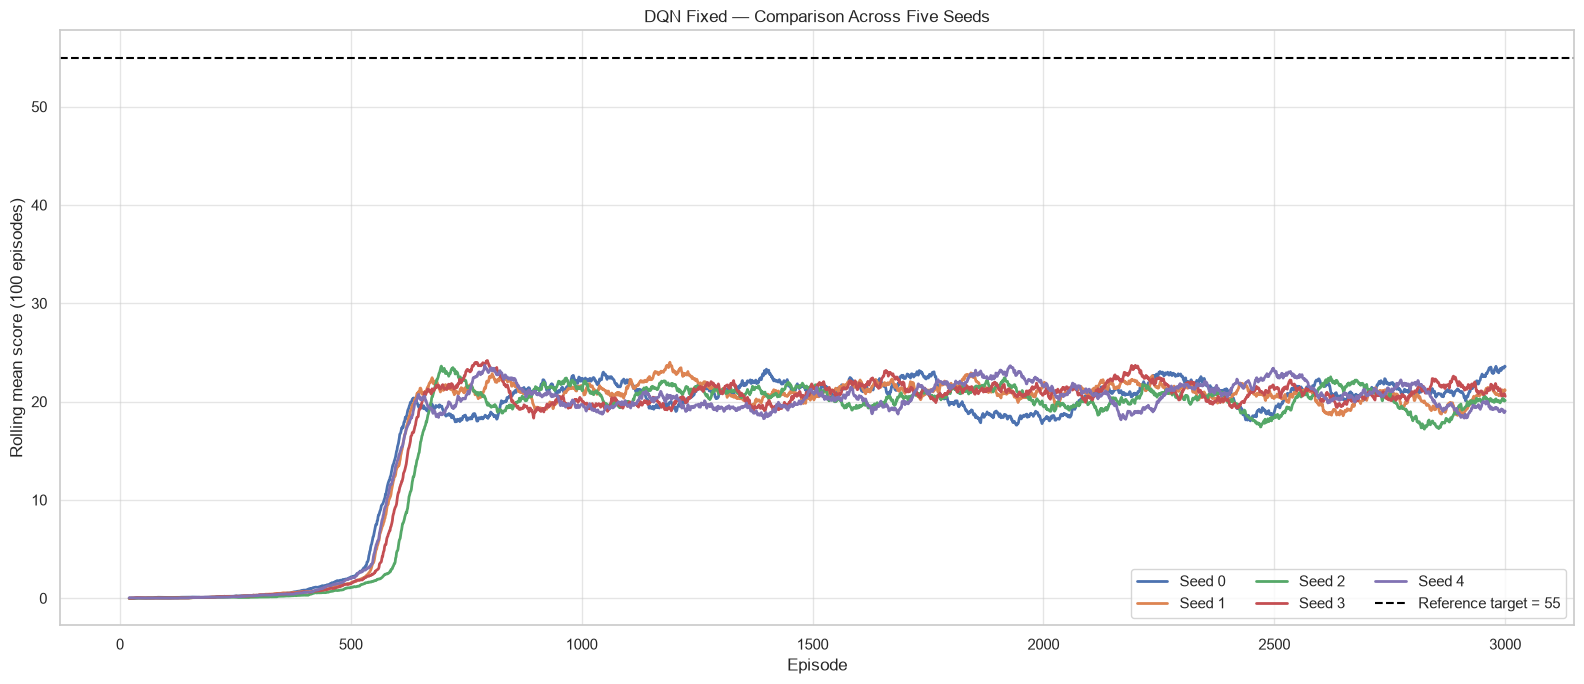

In [32]:
plt.figure(figsize=(16, 7))

for seed in range(5):
    seed_data = dqn_fixed[
        dqn_fixed["seed"] == seed
    ]

    plt.plot(
        seed_data["episode"],
        seed_data["rolling_score"],
        linewidth=2,
        label=f"Seed {seed}",
    )

plt.axhline(
    55,
    color="black",
    linestyle="--",
    label="Reference target = 55",
)

plt.title("DQN Fixed — Comparison Across Five Seeds")
plt.xlabel("Episode")
plt.ylabel("Rolling mean score (100 episodes)")
plt.legend(ncol=3)
plt.tight_layout()
plt.show()

Death cause Fixed

In [33]:
fixed_death_summary = (
    dqn_fixed.groupby(
        ["seed", "death_cause"],
        observed=True,
    )
    .size()
    .rename("count")
    .reset_index()
)

fixed_death_summary["percentage"] = (
    fixed_death_summary["count"]
    / fixed_death_summary.groupby("seed")["count"]
    .transform("sum")
    * 100
)

display(
    fixed_death_summary.sort_values(
        ["seed", "death_cause"]
    ).round(2)
)

,seed,death_cause,count,percentage
0,0,obstacle,518,17.27
1,0,self,1867,62.23
2,0,wall,615,20.50
3,1,obstacle,474,15.80
4,1,self,1809,60.30
5,1,wall,717,23.90
6,2,obstacle,491,16.37
7,2,self,1781,59.37
8,2,wall,728,24.27
9,3,obstacle,489,16.30


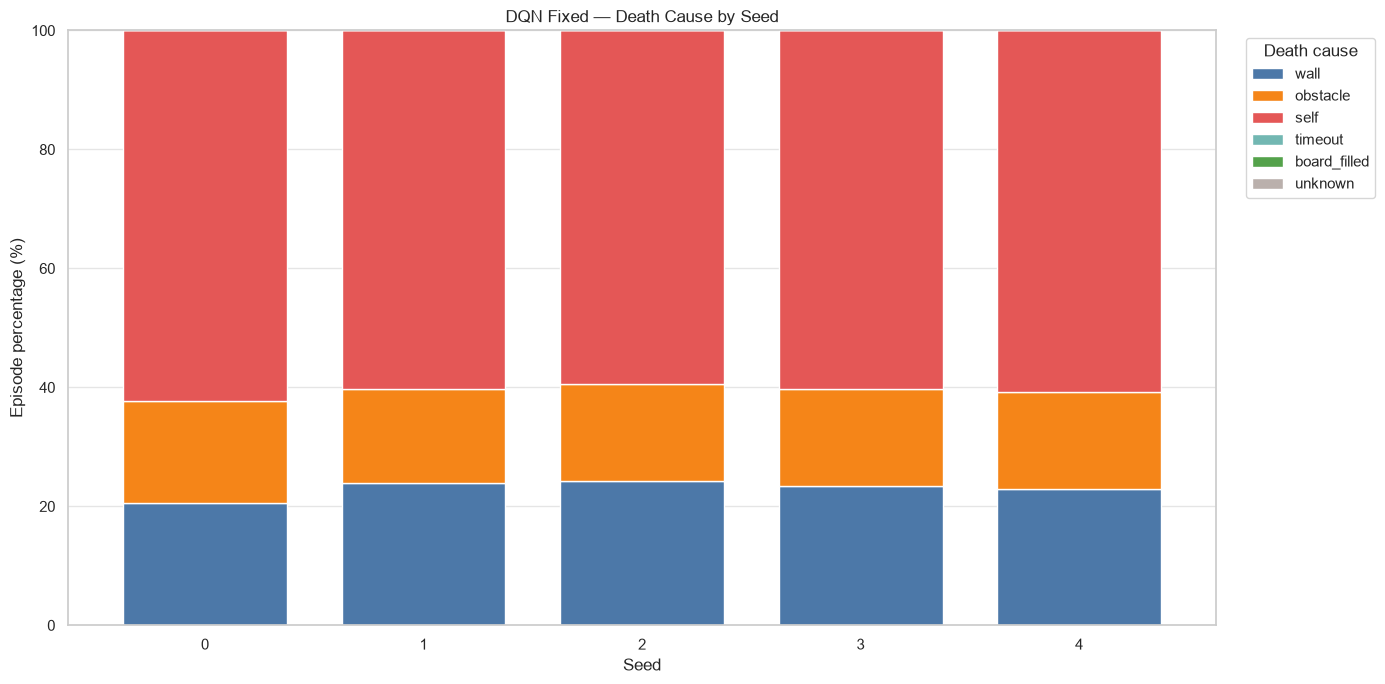

In [34]:
fixed_death_plot = (
    fixed_death_summary.pivot_table(
        index="seed",
        columns="death_cause",
        values="percentage",
        fill_value=0,
    )
    .reindex(columns=DEATH_ORDER, fill_value=0)
)

ax = fixed_death_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(14, 7),
    color=[
        DEATH_COLORS[cause]
        for cause in fixed_death_plot.columns
    ],
    width=0.75,
)

ax.set_title("DQN Fixed — Death Cause by Seed")
ax.set_xlabel("Seed")
ax.set_ylabel("Episode percentage (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)
ax.legend(
    title="Death cause",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

Death cause thay đổi theo episode của Fixed

In [35]:
FIXED_DEATH_WINDOW = 100
fixed_causes = ["wall", "obstacle", "self"]

for cause in fixed_causes:
    dqn_fixed[f"is_{cause}"] = (
        dqn_fixed["death_cause"] == cause
    ).astype(float)

    dqn_fixed[f"rolling_{cause}"] = (
        dqn_fixed.groupby("seed")[f"is_{cause}"]
        .transform(
            lambda x: x.rolling(
                FIXED_DEATH_WINDOW,
                min_periods=20,
            ).mean() * 100
        )
    )

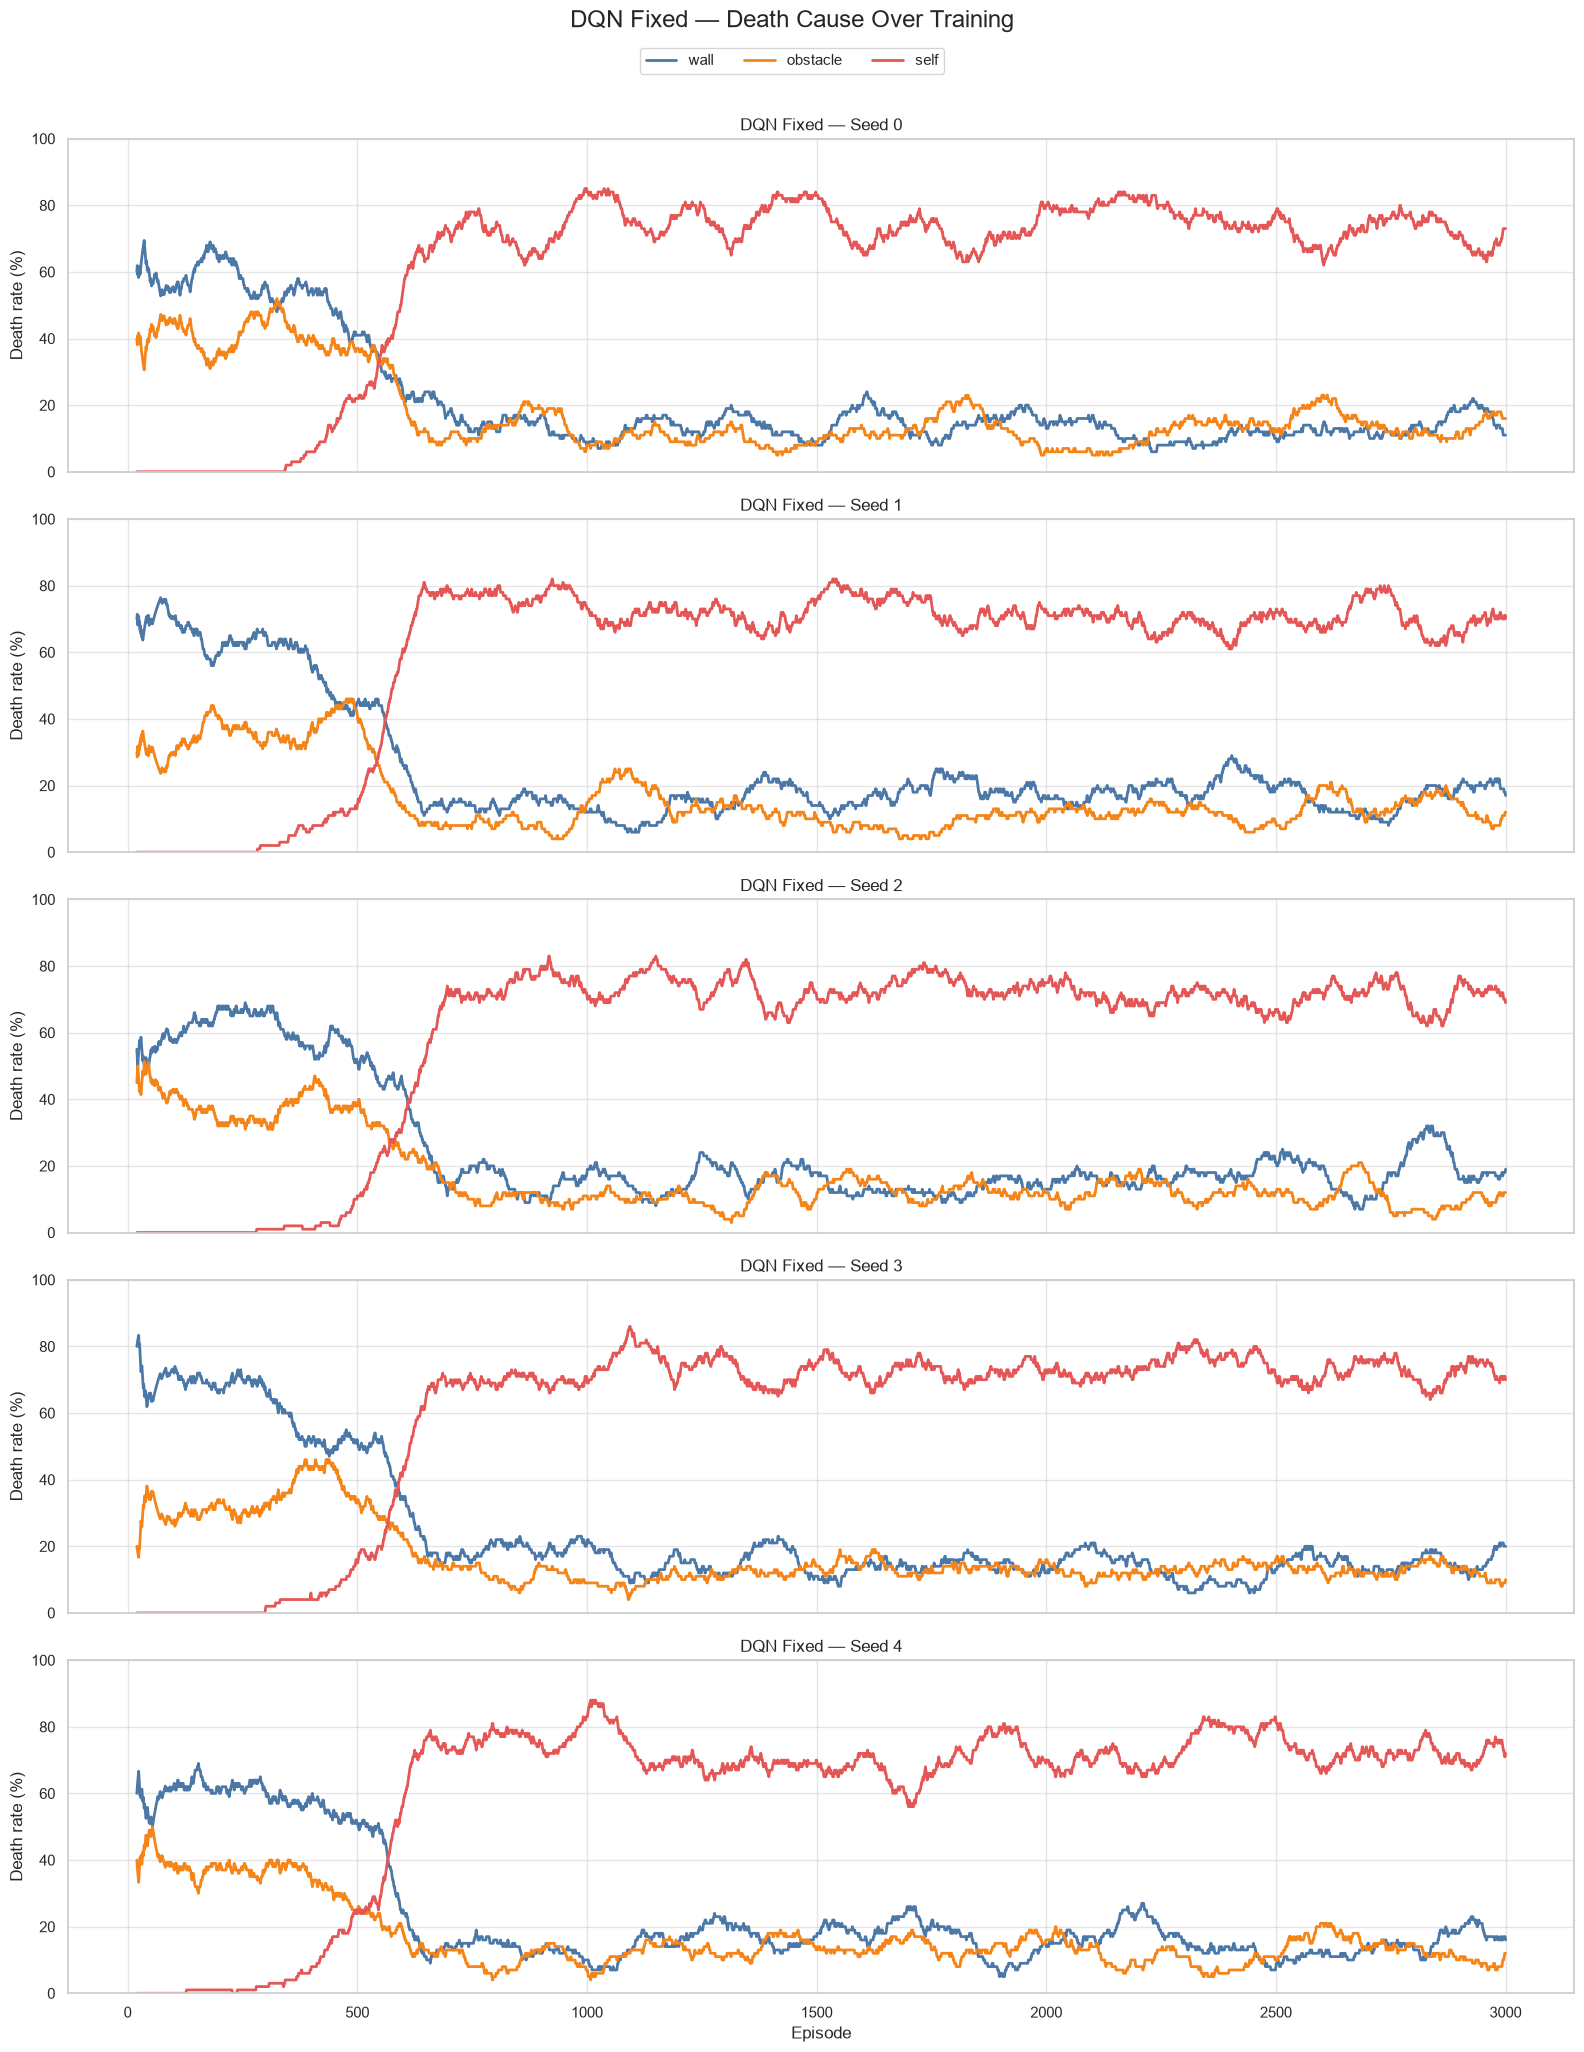

In [36]:
fig, axes = plt.subplots(
    5,
    1,
    figsize=(16, 20),
    sharex=True,
    sharey=True,
)

for seed, ax in zip(range(5), axes):
    seed_data = dqn_fixed[
        dqn_fixed["seed"] == seed
    ]

    for cause in fixed_causes:
        ax.plot(
            seed_data["episode"],
            seed_data[f"rolling_{cause}"],
            label=cause,
            color=DEATH_COLORS[cause],
            linewidth=2,
        )

    ax.set_title(f"DQN Fixed — Seed {seed}")
    ax.set_ylabel("Death rate (%)")
    ax.set_ylim(0, 100)

axes[-1].set_xlabel("Episode")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.01),
)

fig.suptitle(
    "DQN Fixed — Death Cause Over Training",
    fontsize=17,
    y=1.025,
)

plt.tight_layout()
plt.show()

DQN Random DR

In [37]:
random_level_counts = (
    dqn_random.groupby(
        ["seed", "level"],
        observed=True,
    )
    .size()
    .rename("episodes")
    .reset_index()
)

display(random_level_counts)

,seed,level,episodes
0,0,level1,752
1,0,level2,747
2,0,level3,730
3,0,level4,771
4,1,level1,748
5,1,level2,744
6,1,level3,765
7,1,level4,743
8,2,level1,734
9,2,level2,763


In [38]:
random_level_count_table = (
    random_level_counts.pivot(
        index="seed",
        columns="level",
        values="episodes",
    )
)

display(random_level_count_table)

level,level1,level2,level3,level4
seed,,,,
0,752,747,730,771
1,748,744,765,743
2,734,763,740,763
3,737,724,785,754
4,744,777,763,716


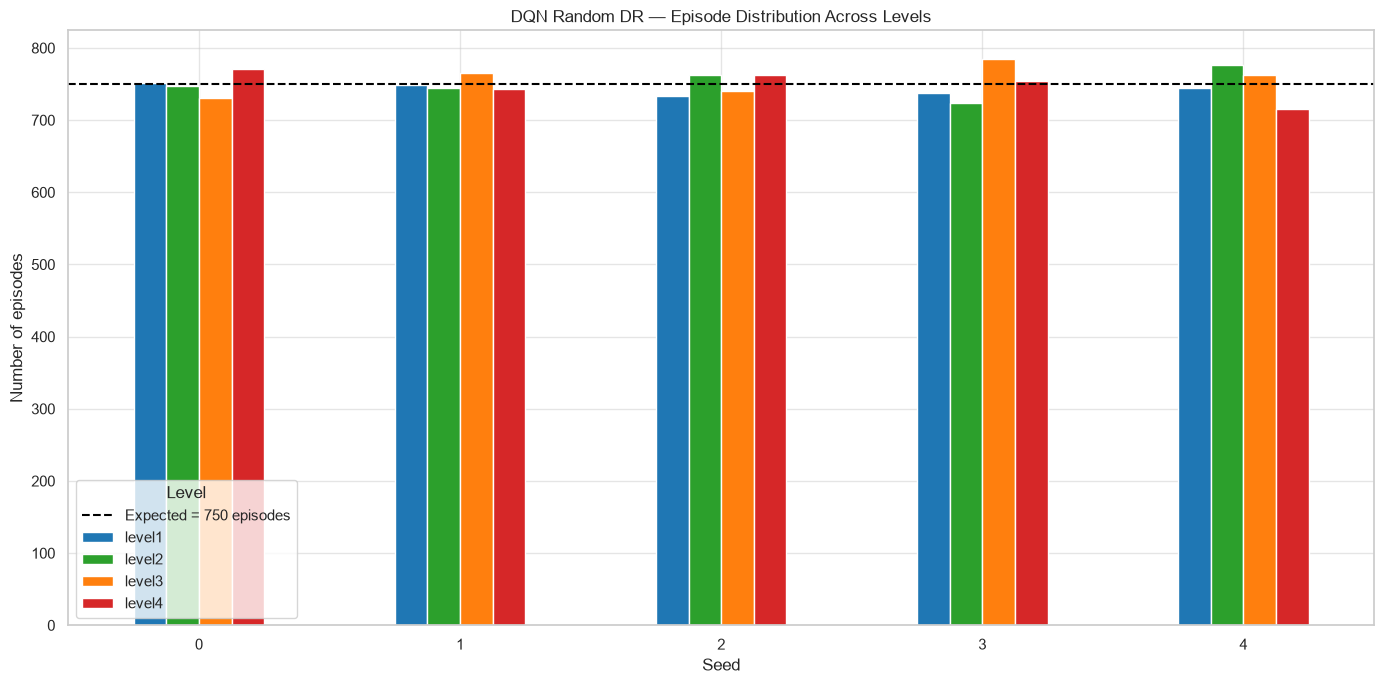

In [39]:
ax = random_level_count_table.plot(
    kind="bar",
    figsize=(14, 7),
    color=[
        LEVEL_COLORS[level]
        for level in random_level_count_table.columns
    ],
)

ax.axhline(
    750,
    color="black",
    linestyle="--",
    label="Expected = 750 episodes",
)

ax.set_title("DQN Random DR — Episode Distribution Across Levels")
ax.set_xlabel("Seed")
ax.set_ylabel("Number of episodes")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Level")

plt.tight_layout()
plt.show()

Bảng score theo seed và level

In [40]:
random_score_summary = (
    dqn_random.groupby(
        ["seed", "level"],
        observed=True,
    )
    .agg(
        episodes=("episode", "count"),
        mean_score=("score", "mean"),
        median_score=("score", "median"),
        std_score=("score", "std"),
        max_score=("score", "max"),
        p90_score=("score", lambda x: x.quantile(0.90)),
        mean_steps=("steps", "mean"),
    )
    .round(3)
    .reset_index()
)

display(random_score_summary)

,seed,level,episodes,mean_score,median_score,std_score,max_score,p90_score,mean_steps
0,0,level1,752,12.188,13.0,8.617,34.0,23.0,108.299
1,0,level2,747,16.767,17.0,10.644,52.0,30.0,209.134
2,0,level3,730,14.675,15.0,10.189,51.0,28.0,190.262
3,0,level4,771,17.123,18.0,11.951,55.0,33.0,286.182
4,1,level1,748,12.068,13.0,8.151,37.0,22.3,106.436
5,1,level2,744,15.622,16.0,10.666,47.0,29.0,195.250
6,1,level3,765,14.808,15.0,10.516,49.0,28.0,190.469
7,1,level4,743,16.032,16.0,11.847,54.0,32.0,265.367
8,2,level1,734,12.268,13.0,8.118,38.0,22.0,107.307
9,2,level2,763,16.178,17.0,10.633,47.0,30.0,201.596


In [41]:
random_mean_score_table = random_score_summary.pivot(
    index="seed",
    columns="level",
    values="mean_score",
)

display(random_mean_score_table.round(3))

level,level1,level2,level3,level4
seed,,,,
0,12.188,16.767,14.675,17.123
1,12.068,15.622,14.808,16.032
2,12.268,16.178,15.055,16.721
3,12.319,15.885,14.744,16.541
4,12.794,16.574,14.391,17.261


In [42]:
random_max_score_table = random_score_summary.pivot(
    index="seed",
    columns="level",
    values="max_score",
)

display(random_max_score_table)

level,level1,level2,level3,level4
seed,,,,
0,34.0,52.0,51.0,55.0
1,37.0,47.0,49.0,54.0
2,38.0,47.0,50.0,52.0
3,38.0,48.0,44.0,56.0
4,34.0,51.0,47.0,52.0


Learning curve tổng của Random DR

In [43]:
RANDOM_ROLLING_WINDOW = 100

dqn_random["rolling_score"] = (
    dqn_random.groupby("seed")["score"]
    .transform(
        lambda x: x.rolling(
            RANDOM_ROLLING_WINDOW,
            min_periods=20,
        ).mean()
    )
)

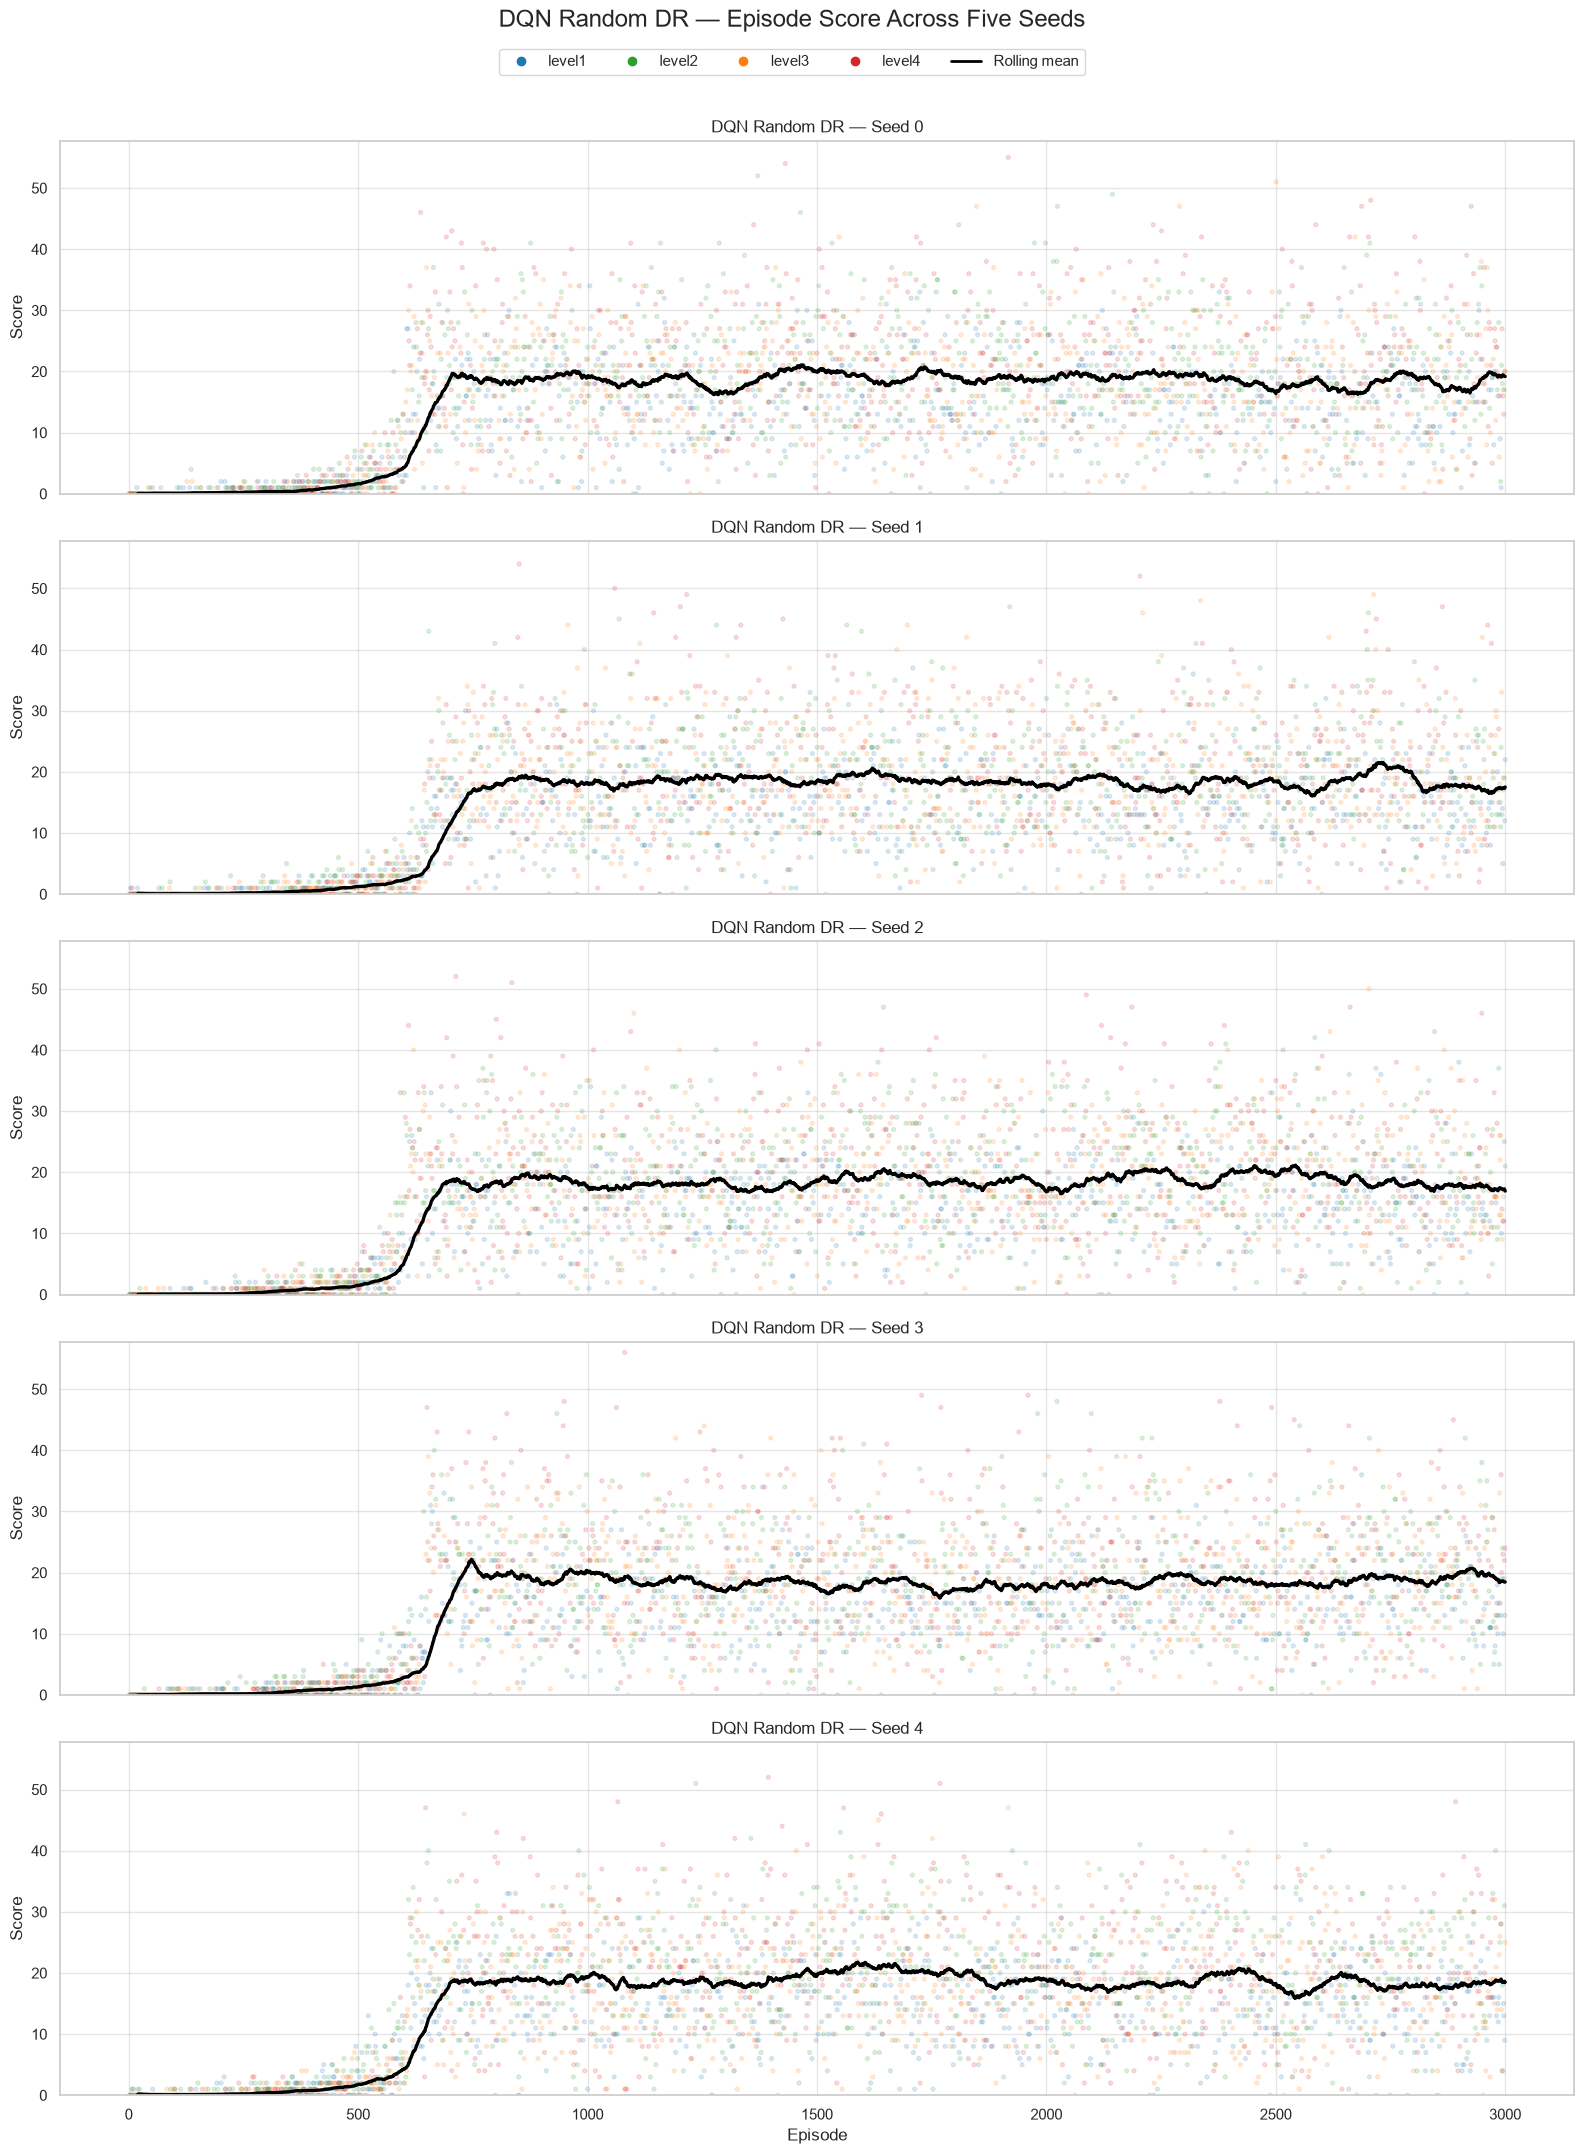

In [44]:
fig, axes = plt.subplots(
    5,
    1,
    figsize=(16, 21),
    sharex=True,
    sharey=True,
)

for seed, ax in zip(range(5), axes):
    seed_data = dqn_random[
        dqn_random["seed"] == seed
    ]

    ax.scatter(
        seed_data["episode"],
        seed_data["score"],
        c=seed_data["level"].map(LEVEL_COLORS),
        s=8,
        alpha=0.15,
    )

    ax.plot(
        seed_data["episode"],
        seed_data["rolling_score"],
        color="black",
        linewidth=2.4,
        label="Overall rolling mean",
    )

    ax.set_title(f"DQN Random DR — Seed {seed}")
    ax.set_ylabel("Score")
    ax.set_ylim(bottom=0)

axes[-1].set_xlabel("Episode")

legend_handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        color=LEVEL_COLORS[level],
        label=level,
    )
    for level in LEVEL_ORDER
]

legend_handles.append(
    plt.Line2D(
        [0],
        [0],
        color="black",
        linewidth=2,
        label="Rolling mean",
    )
)

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=5,
    bbox_to_anchor=(0.5, 1.01),
)

fig.suptitle(
    "DQN Random DR — Episode Score Across Five Seeds",
    fontsize=17,
    y=1.025,
)

plt.tight_layout()
plt.show()

Learning curve riêng cho từng level

In [45]:
BIN_SIZE = 100

dqn_random["episode_bin"] = (
    ((dqn_random["episode"] - 1) // BIN_SIZE)
    * BIN_SIZE
    + 1
)

random_binned = (
    dqn_random.groupby(
        ["seed", "episode_bin", "level"],
        observed=True,
    )
    .agg(
        mean_score=("score", "mean"),
        number_of_episodes=("score", "size"),
    )
    .reset_index()
)

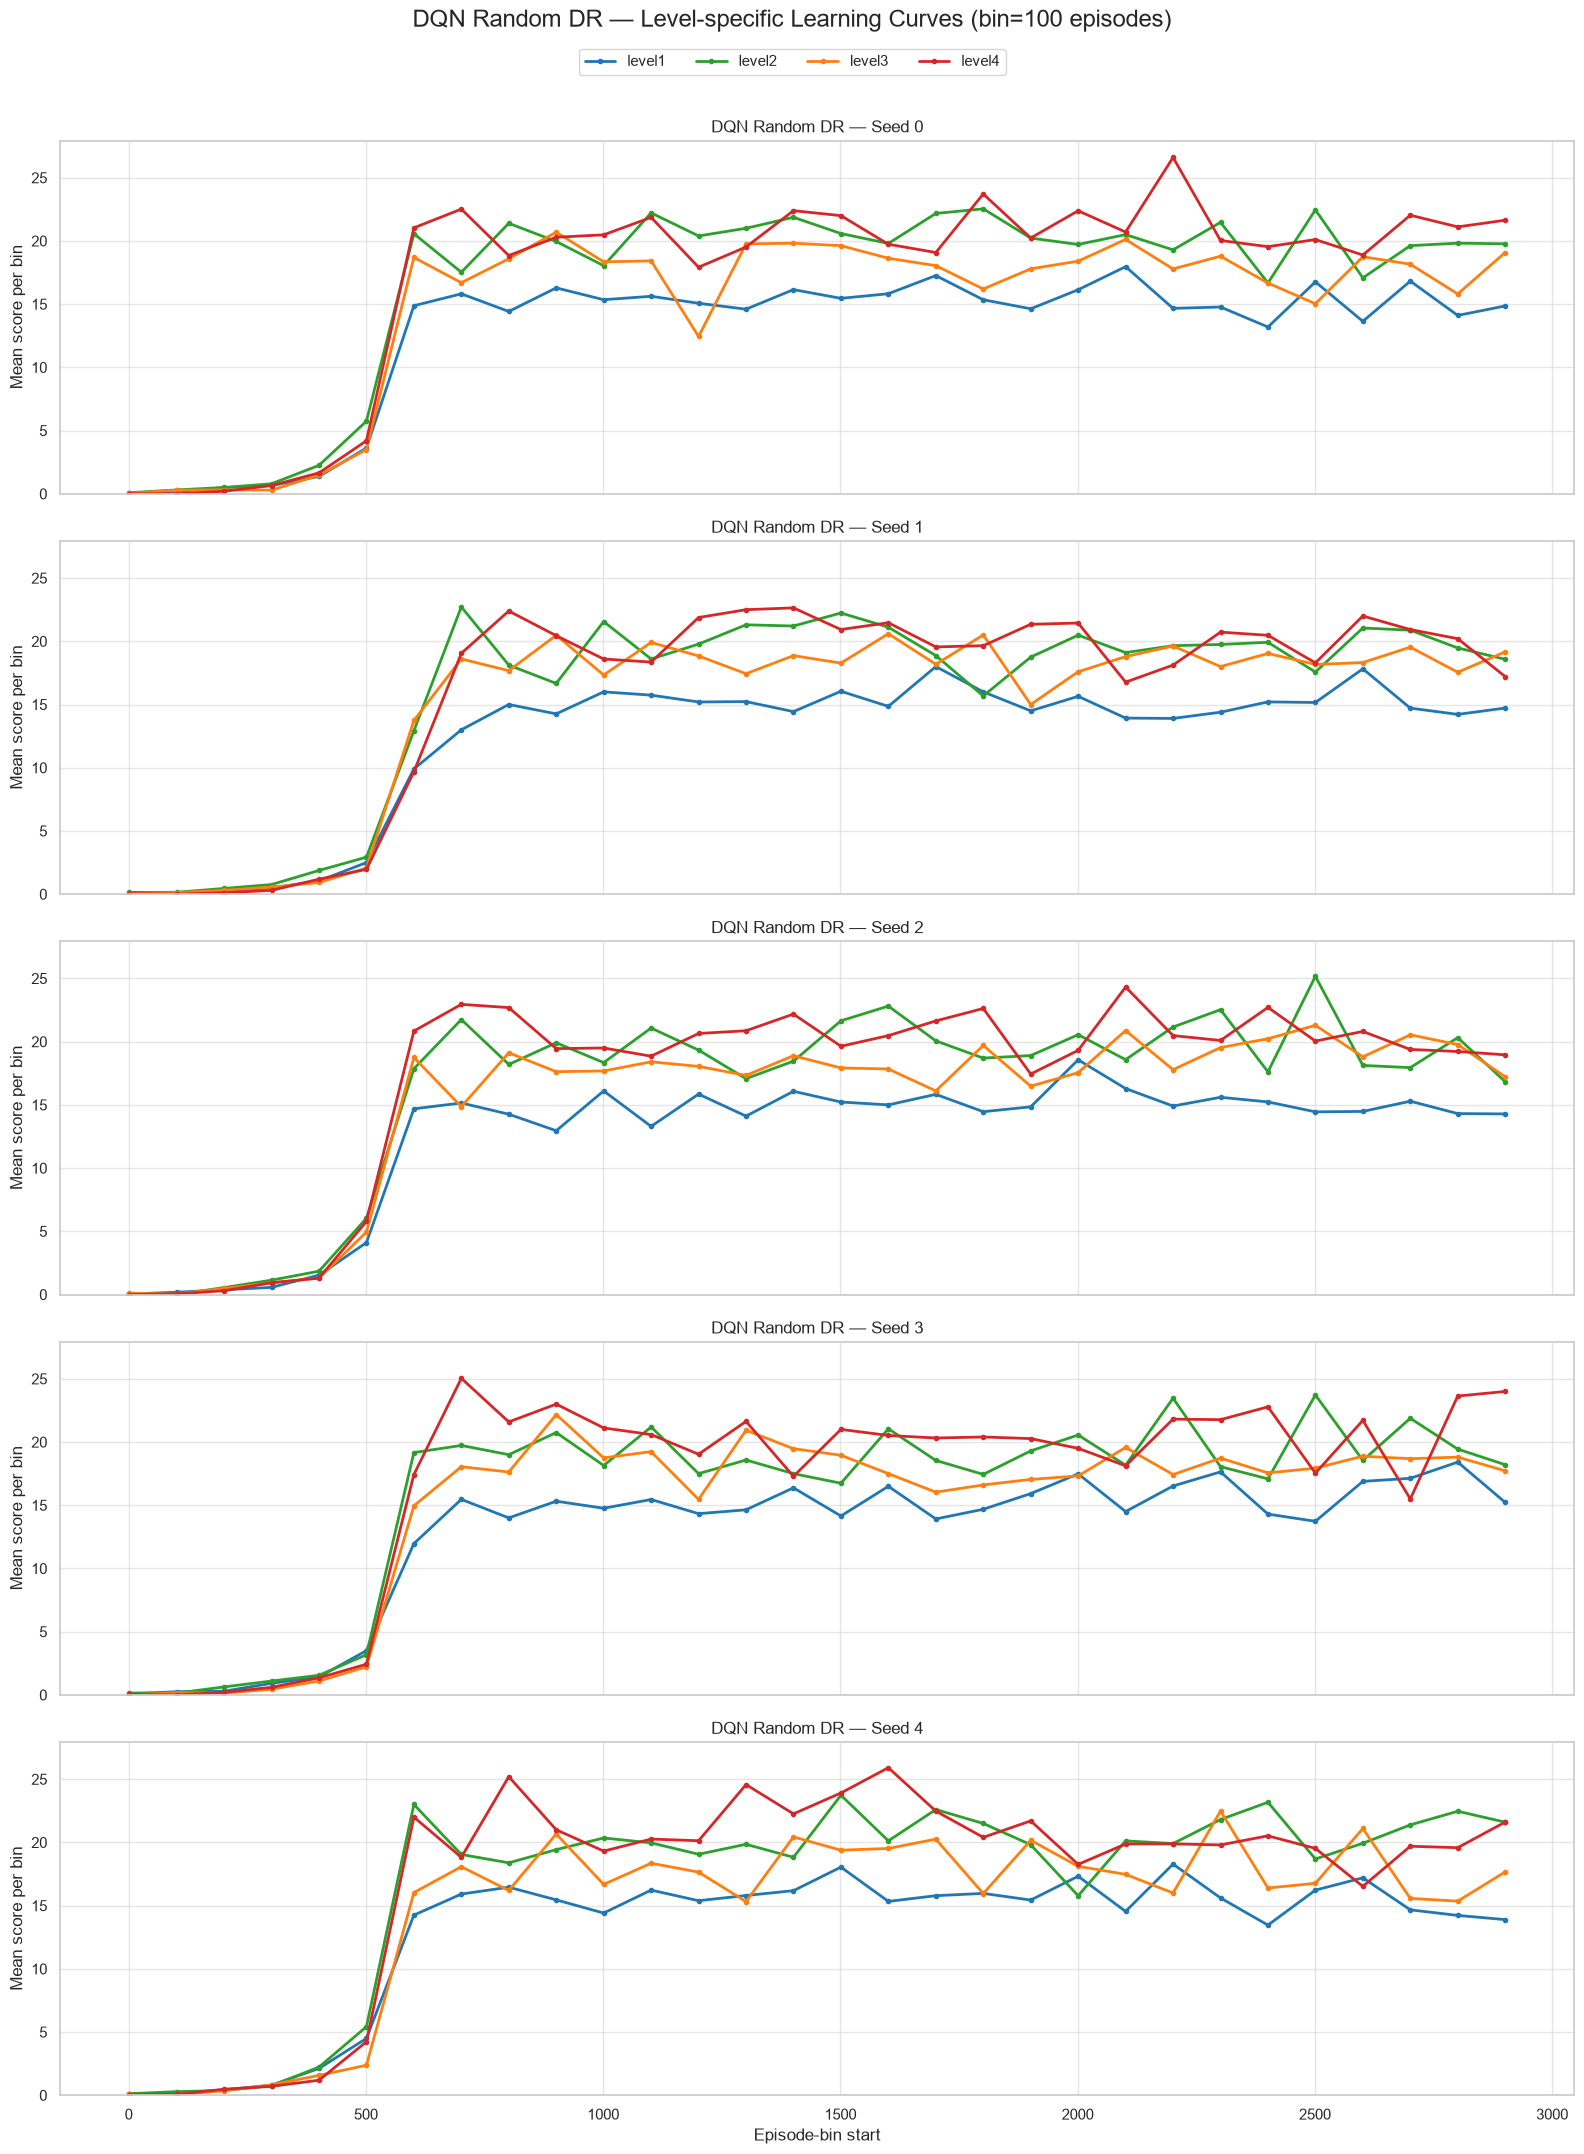

In [46]:
fig, axes = plt.subplots(
    5,
    1,
    figsize=(16, 21),
    sharex=True,
    sharey=True,
)

for seed, ax in zip(range(5), axes):
    seed_data = random_binned[
        random_binned["seed"] == seed
    ]

    for level in LEVEL_ORDER:
        level_data = seed_data[
            seed_data["level"] == level
        ]

        ax.plot(
            level_data["episode_bin"],
            level_data["mean_score"],
            color=LEVEL_COLORS[level],
            linewidth=2,
            marker="o",
            markersize=3,
            label=level,
        )

    ax.set_title(f"DQN Random DR — Seed {seed}")
    ax.set_ylabel("Mean score per bin")
    ax.set_ylim(bottom=0)

axes[-1].set_xlabel("Episode-bin start")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.01),
)

fig.suptitle(
    f"DQN Random DR — Level-specific Learning Curves "
    f"(bin={BIN_SIZE} episodes)",
    fontsize=17,
    y=1.025,
)

plt.tight_layout()
plt.show()

Đường trung bình 5 seed theo level

In [47]:
random_binned_across_seeds = (
    random_binned.groupby(
        ["episode_bin", "level"],
        observed=True,
    )
    .agg(
        mean_score=("mean_score", "mean"),
        std_across_seeds=("mean_score", "std"),
    )
    .reset_index()
)

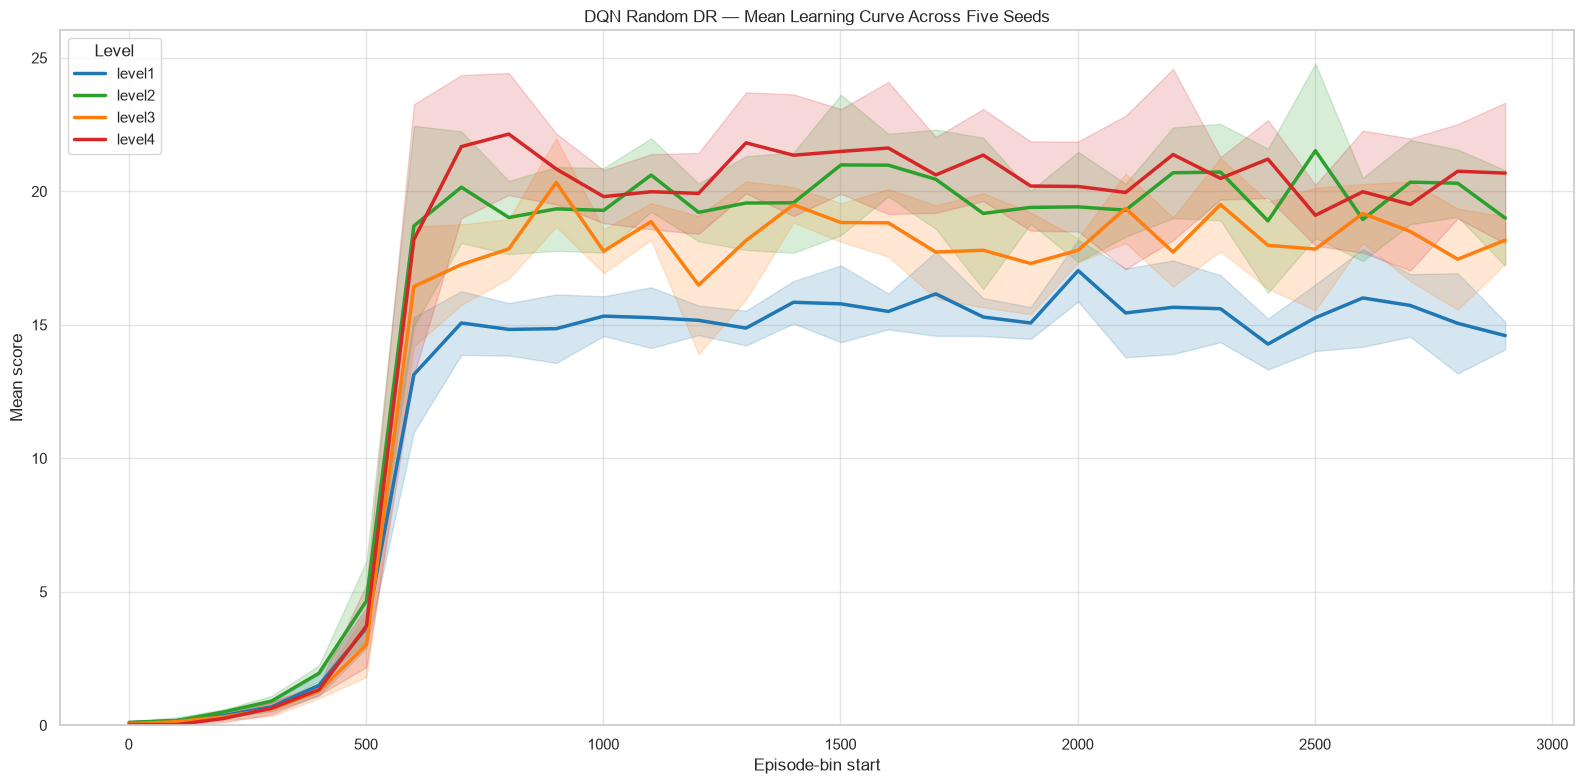

In [48]:
plt.figure(figsize=(16, 8))

for level in LEVEL_ORDER:
    level_data = random_binned_across_seeds[
        random_binned_across_seeds["level"] == level
    ]

    x = level_data["episode_bin"].to_numpy()
    mean = level_data["mean_score"].to_numpy()
    std = level_data["std_across_seeds"].to_numpy()

    plt.plot(
        x,
        mean,
        color=LEVEL_COLORS[level],
        linewidth=2.5,
        label=level,
    )

    plt.fill_between(
        x,
        mean - std,
        mean + std,
        color=LEVEL_COLORS[level],
        alpha=0.18,
    )

plt.title(
    "DQN Random DR — Mean Learning Curve Across Five Seeds"
)
plt.xlabel("Episode-bin start")
plt.ylabel("Mean score")
plt.ylim(bottom=0)
plt.legend(title="Level")
plt.tight_layout()
plt.show()

Phân phối score của Random DR

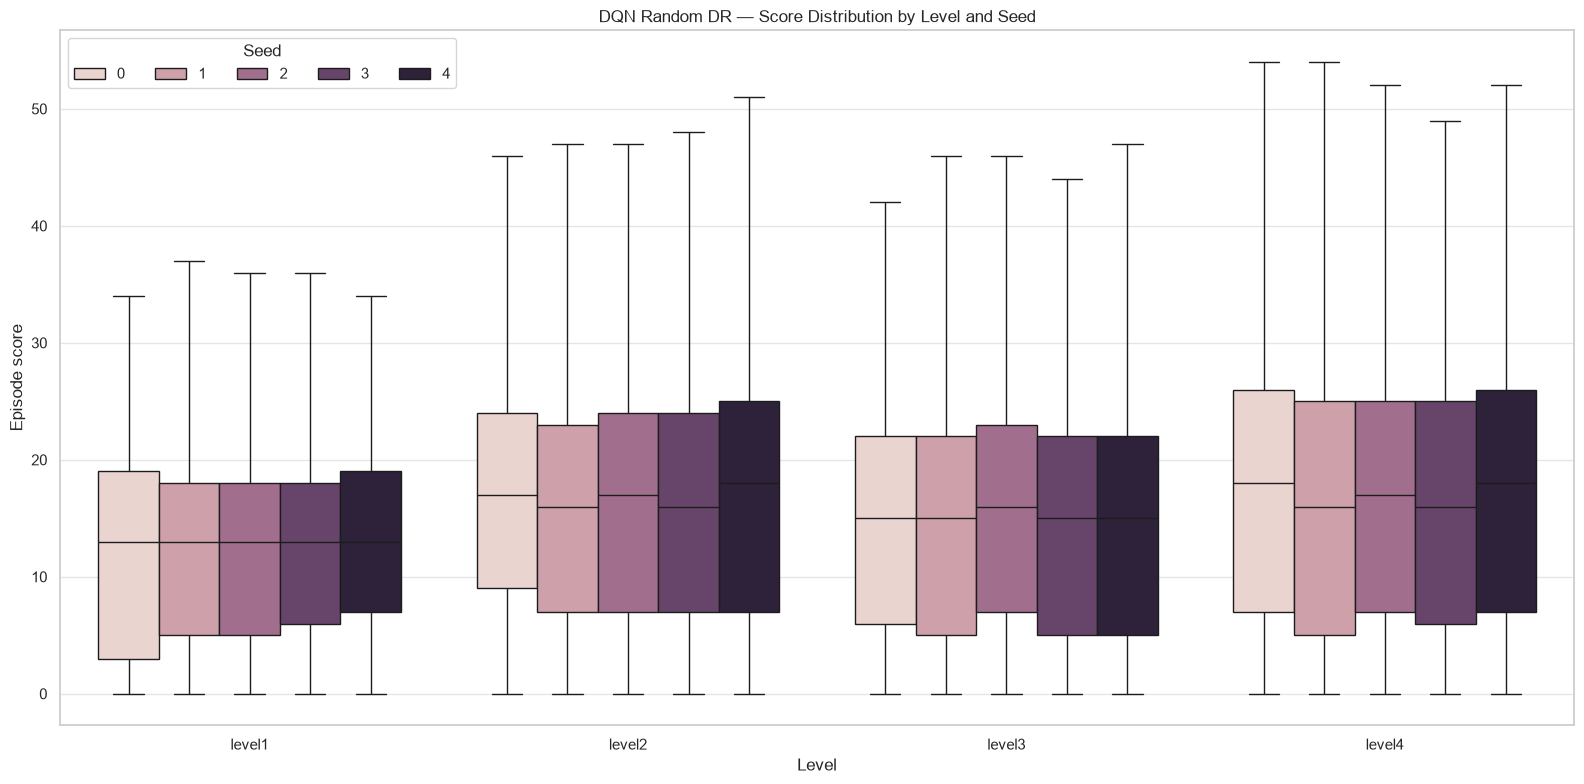

In [49]:
plt.figure(figsize=(16, 8))

sns.boxplot(
    data=dqn_random,
    x="level",
    y="score",
    hue="seed",
    showfliers=False,
)

plt.title("DQN Random DR — Score Distribution by Level and Seed")
plt.xlabel("Level")
plt.ylabel("Episode score")
plt.legend(title="Seed", ncol=5)
plt.tight_layout()
plt.show()

Death cause Random DR theo seed và level

In [50]:
random_death_summary = (
    dqn_random.groupby(
        ["seed", "level", "death_cause"],
        observed=True,
    )
    .size()
    .rename("count")
    .reset_index()
)

random_death_summary["percentage"] = (
    random_death_summary["count"]
    / random_death_summary.groupby(
        ["seed", "level"],
        observed=True,
    )["count"].transform("sum")
    * 100
)

random_death_summary["percentage"] = (
    random_death_summary["percentage"].round(2)
)

display(random_death_summary)

,seed,level,death_cause,count,percentage
0,0,level1,self,462,61.44
1,0,level1,wall,290,38.56
2,0,level2,self,511,68.41
3,0,level2,wall,236,31.59
4,0,level3,obstacle,123,16.85
5,0,level3,self,430,58.90
6,0,level3,wall,177,24.25
7,0,level4,obstacle,126,16.34
8,0,level4,self,476,61.74
9,0,level4,wall,169,21.92


Stacked bar death cause Random DR

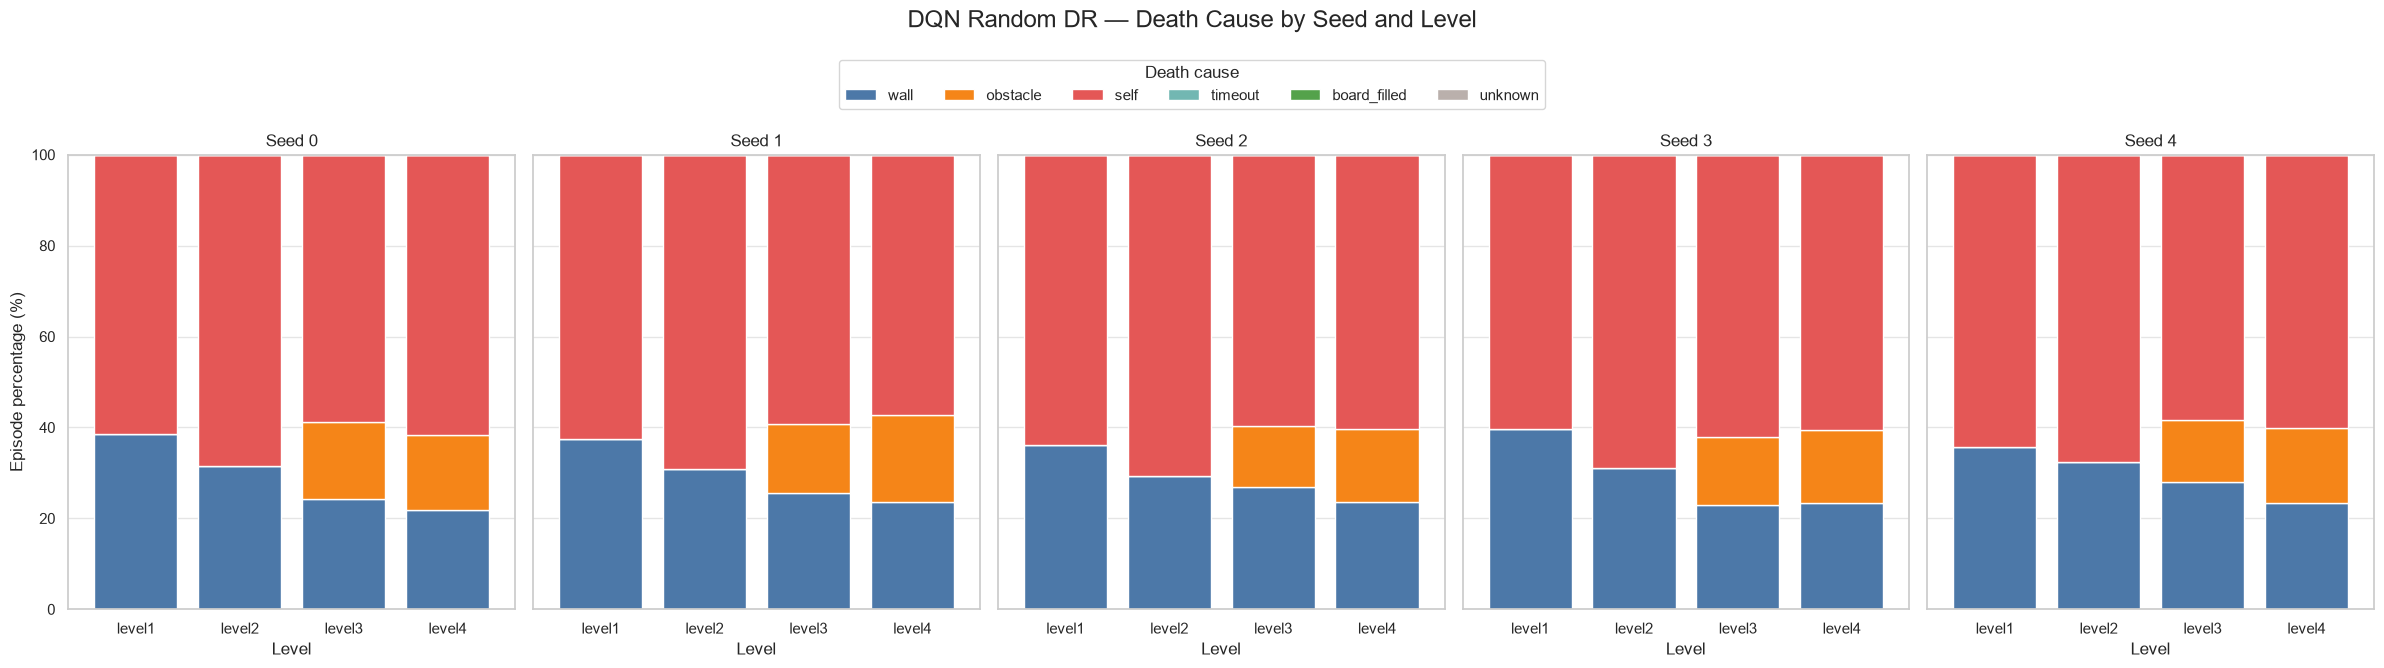

In [51]:
random_death_plot = (
    random_death_summary.pivot_table(
        index=["seed", "level"],
        columns="death_cause",
        values="percentage",
        fill_value=0,
    )
    .reindex(columns=DEATH_ORDER, fill_value=0)
)

fig, axes = plt.subplots(
    1,
    5,
    figsize=(24, 6),
    sharey=True,
)

for seed, ax in zip(range(5), axes):
    seed_plot = random_death_plot.loc[seed]

    seed_plot.plot(
        kind="bar",
        stacked=True,
        ax=ax,
        width=0.8,
        legend=False,
        color=[
            DEATH_COLORS[cause]
            for cause in seed_plot.columns
        ],
    )

    ax.set_title(f"Seed {seed}")
    ax.set_xlabel("Level")
    ax.set_ylabel(
        "Episode percentage (%)"
        if seed == 0
        else ""
    )
    ax.set_ylim(0, 100)
    ax.tick_params(axis="x", rotation=0)

handles, labels = axes[-1].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    title="Death cause",
    loc="upper center",
    ncol=len(labels),
    bbox_to_anchor=(0.5, 1.04),
)

fig.suptitle(
    "DQN Random DR — Death Cause by Seed and Level",
    fontsize=17,
    y=1.11,
)

plt.tight_layout()
plt.show()

Death cause Random DR theo thời gian

In [52]:
RANDOM_DEATH_WINDOW = 100
random_causes = ["wall", "obstacle", "self"]

for cause in random_causes:
    dqn_random[f"is_{cause}"] = (
        dqn_random["death_cause"] == cause
    ).astype(float)

    dqn_random[f"rolling_{cause}"] = (
        dqn_random.groupby("seed")[f"is_{cause}"]
        .transform(
            lambda x: x.rolling(
                RANDOM_DEATH_WINDOW,
                min_periods=20,
            ).mean() * 100
        )
    )

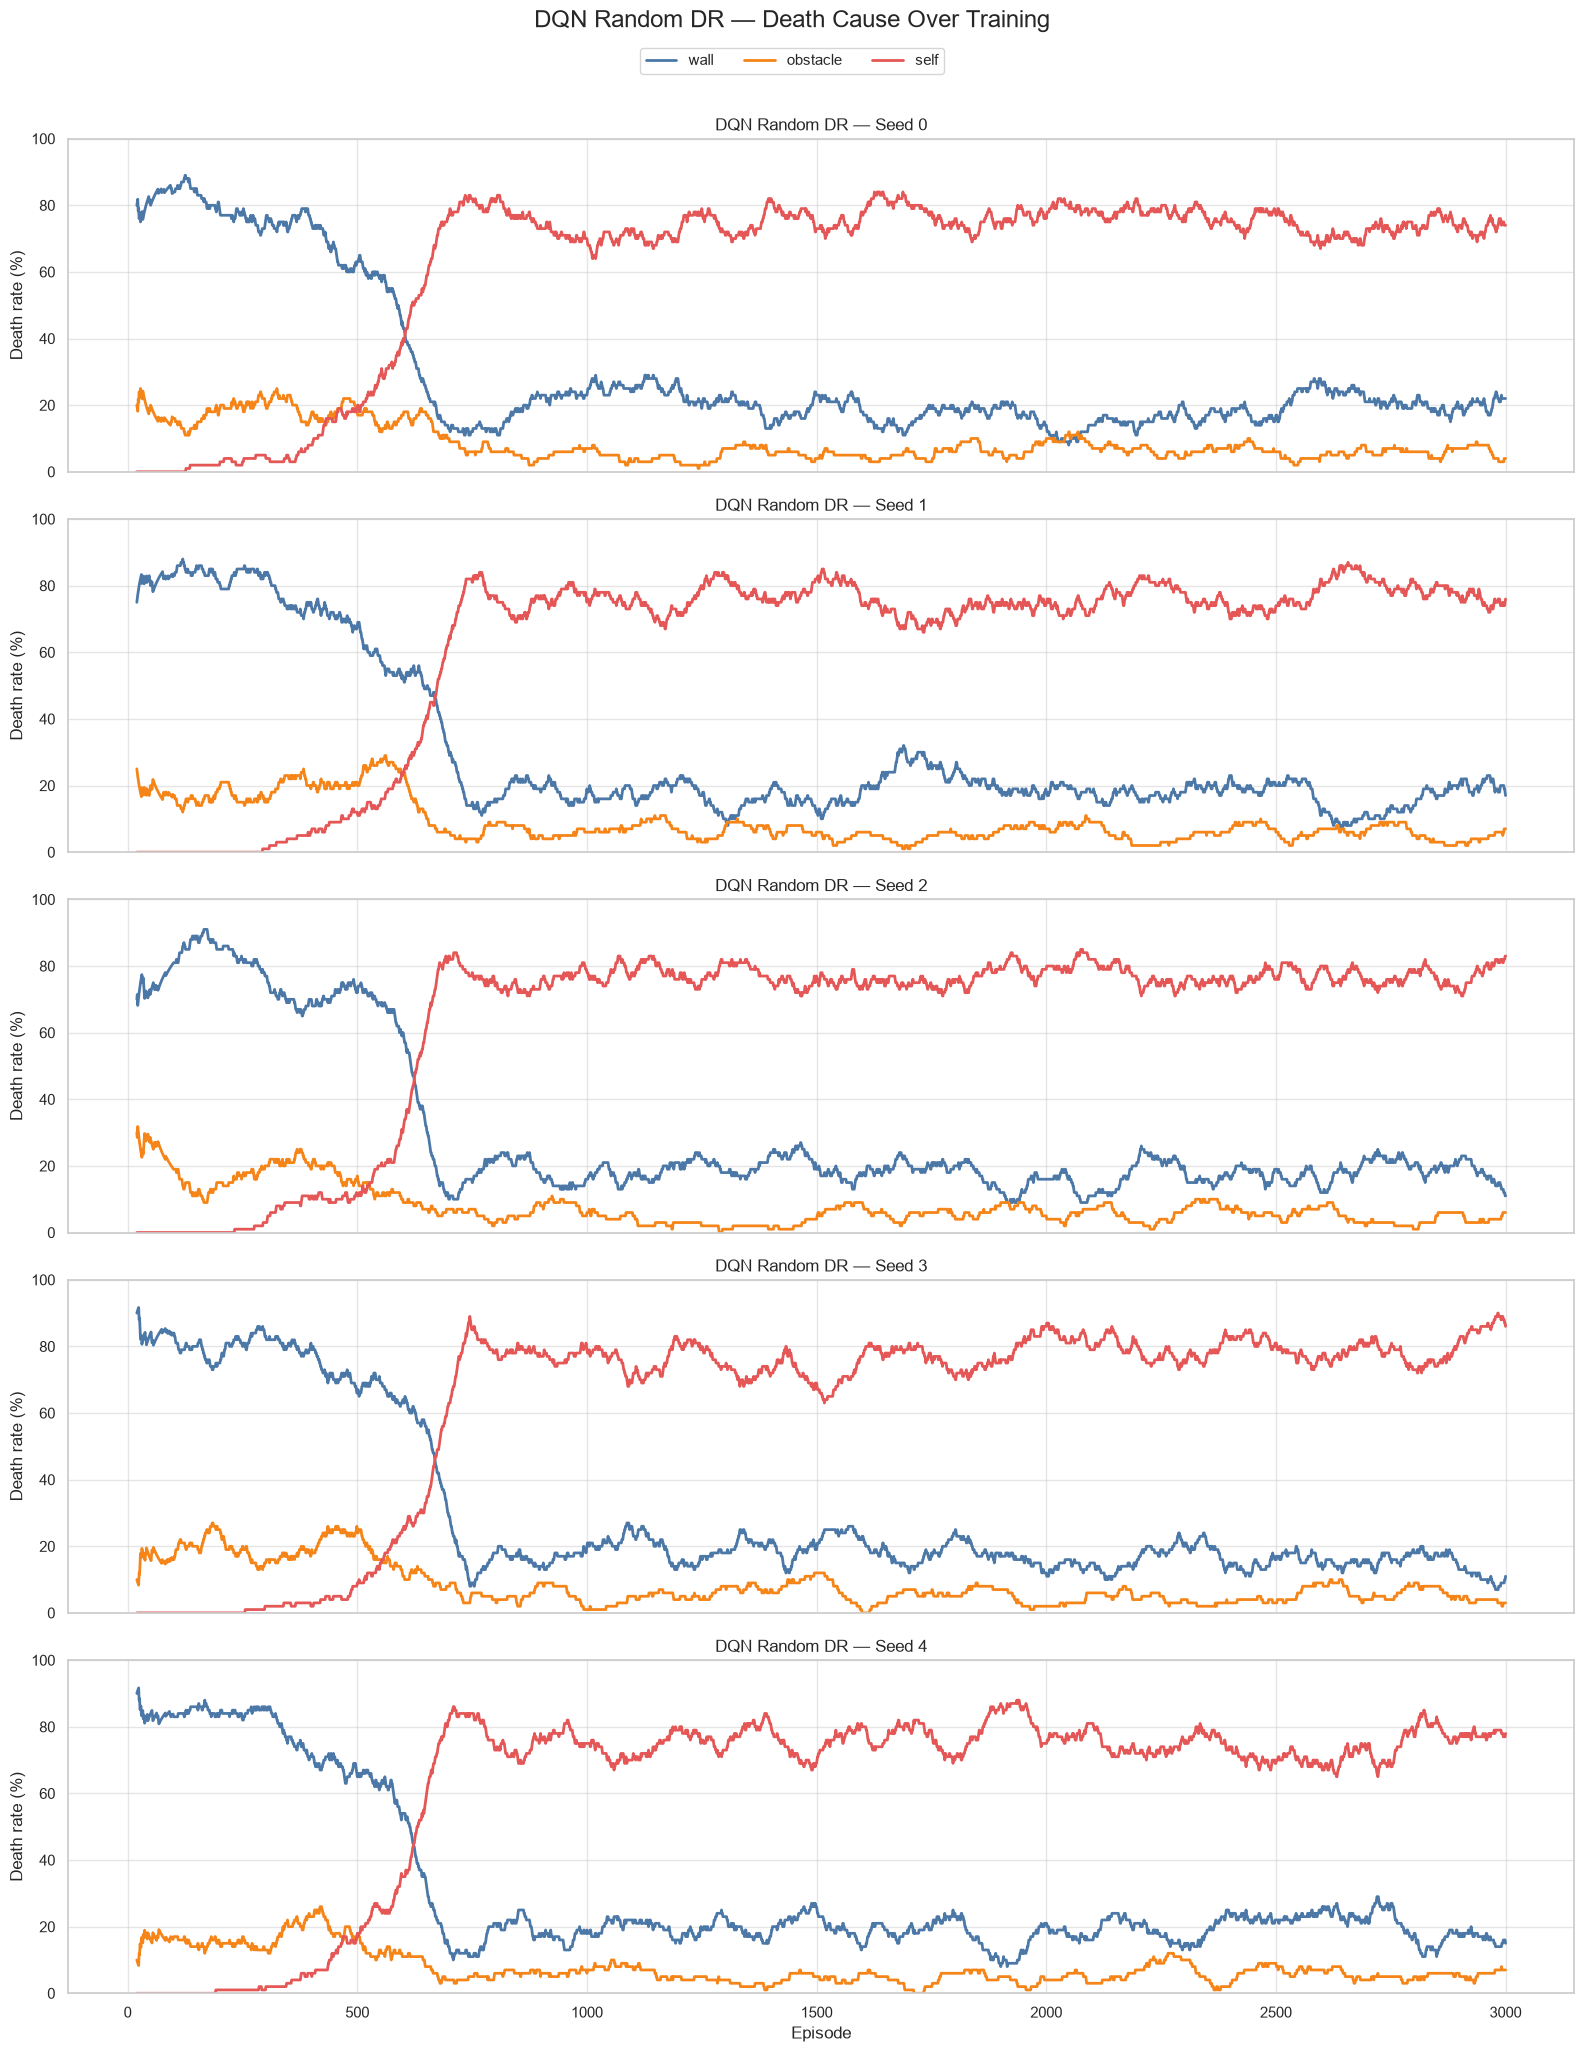

In [53]:
fig, axes = plt.subplots(
    5,
    1,
    figsize=(16, 20),
    sharex=True,
    sharey=True,
)

for seed, ax in zip(range(5), axes):
    seed_data = dqn_random[
        dqn_random["seed"] == seed
    ]

    for cause in random_causes:
        ax.plot(
            seed_data["episode"],
            seed_data[f"rolling_{cause}"],
            label=cause,
            color=DEATH_COLORS[cause],
            linewidth=2,
        )

    ax.set_title(f"DQN Random DR — Seed {seed}")
    ax.set_ylabel("Death rate (%)")
    ax.set_ylim(0, 100)

axes[-1].set_xlabel("Episode")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    bbox_to_anchor=(0.5, 1.01),
)

fig.suptitle(
    "DQN Random DR — Death Cause Over Training",
    fontsize=17,
    y=1.025,
)

plt.tight_layout()
plt.show()

Đọc cả ba cấu hình PPO

In [54]:
ppo_fixed = load_episode_logs("ppo_fixed")
ppo_random = load_episode_logs("ppo_random_dr")
ppo_curriculum = load_episode_logs("ppo_curriculum")

ppo_all = pd.concat(
    [
        ppo_fixed,
        ppo_random,
        ppo_curriculum,
    ],
    ignore_index=True,
)

print("PPO Fixed:", ppo_fixed.shape)
print("PPO Random DR:", ppo_random.shape)
print("PPO Curriculum:", ppo_curriculum.shape)
print("All PPO:", ppo_all.shape)

PPO Fixed: (15000, 9)
PPO Random DR: (15000, 9)
PPO Curriculum: (15000, 9)
All PPO: (45000, 9)


Kiểm tra số episode và level

In [55]:
ppo_data_check = (
    ppo_all.groupby(
        ["configuration", "seed", "level"],
        observed=True,
    )
    .agg(
        episodes=("episode", "count"),
        mean_score=("score", "mean"),
        max_score=("score", "max"),
        mean_steps=("steps", "mean"),
    )
    .round(3)
    .reset_index()
)

display(ppo_data_check)

,configuration,seed,level,episodes,mean_score,max_score,mean_steps
0,ppo_curriculum,0,level1,3000,0.946,11.0,17.403
1,ppo_curriculum,1,level1,3000,0.764,10.0,17.167
2,ppo_curriculum,2,level1,3000,1.107,12.0,19.003
3,ppo_curriculum,3,level1,3000,0.826,10.0,18.071
4,ppo_curriculum,4,level1,3000,0.974,11.0,18.631
5,ppo_fixed,0,level4,3000,0.768,11.0,27.013
6,ppo_fixed,1,level4,3000,0.681,13.0,26.939
7,ppo_fixed,2,level4,3000,0.623,10.0,26.032
8,ppo_fixed,3,level4,3000,0.439,7.0,24.879
9,ppo_fixed,4,level4,3000,0.695,15.0,27.019


In [56]:
episode_count_check = (
    ppo_all.groupby(
        ["configuration", "seed"],
        observed=True,
    )
    .size()
    .rename("episodes")
    .reset_index()
)

display(episode_count_check)

assert episode_count_check["episodes"].eq(3000).all()

,configuration,seed,episodes
0,ppo_curriculum,0,3000
1,ppo_curriculum,1,3000
2,ppo_curriculum,2,3000
3,ppo_curriculum,3,3000
4,ppo_curriculum,4,3000
5,ppo_fixed,0,3000
6,ppo_fixed,1,3000
7,ppo_fixed,2,3000
8,ppo_fixed,3,3000
9,ppo_fixed,4,3000


Bảng score đầy đủ

In [57]:
ppo_score_summary = (
    ppo_all.groupby(
        ["configuration", "seed", "level"],
        observed=True,
    )
    .agg(
        episodes=("episode", "count"),
        mean_score=("score", "mean"),
        median_score=("score", "median"),
        std_score=("score", "std"),
        max_score=("score", "max"),
        p90_score=("score", lambda x: x.quantile(0.90)),
        mean_steps=("steps", "mean"),
        max_steps=("steps", "max"),
    )
    .round(3)
    .reset_index()
)

display(ppo_score_summary)

,configuration,seed,level,episodes,mean_score,median_score,std_score,max_score,p90_score,mean_steps,max_steps
0,ppo_curriculum,0,level1,3000,0.946,0.0,1.511,11.0,3.0,17.403,99
1,ppo_curriculum,1,level1,3000,0.764,0.0,1.338,10.0,3.0,17.167,98
2,ppo_curriculum,2,level1,3000,1.107,0.0,1.692,12.0,3.0,19.003,107
3,ppo_curriculum,3,level1,3000,0.826,0.0,1.415,10.0,3.0,18.071,109
4,ppo_curriculum,4,level1,3000,0.974,0.0,1.538,11.0,3.0,18.631,120
5,ppo_fixed,0,level4,3000,0.768,0.0,1.334,11.0,2.0,27.013,196
6,ppo_fixed,1,level4,3000,0.681,0.0,1.222,13.0,2.0,26.939,209
7,ppo_fixed,2,level4,3000,0.623,0.0,1.174,10.0,2.0,26.032,198
8,ppo_fixed,3,level4,3000,0.439,0.0,0.919,7.0,2.0,24.879,161
9,ppo_fixed,4,level4,3000,0.695,0.0,1.313,15.0,2.0,27.019,227


In [58]:
ppo_mean_score_table = ppo_score_summary.pivot_table(
    index=["configuration", "seed"],
    columns="level",
    values="mean_score",
)

display(ppo_mean_score_table.round(3))

level                level1  level2  level3  level4
configuration  seed                                
ppo_curriculum 0      0.946     NaN     NaN     NaN
               1      0.764     NaN     NaN     NaN
               2      1.107     NaN     NaN     NaN
               3      0.826     NaN     NaN     NaN
               4      0.974     NaN     NaN     NaN
ppo_fixed      0        NaN     NaN     NaN   0.768
               1        NaN     NaN     NaN   0.681
               2        NaN     NaN     NaN   0.623
               3        NaN     NaN     NaN   0.439
               4        NaN     NaN     NaN   0.695
ppo_random_dr  0      1.580   1.861   0.912   0.916
               1      0.971   1.058   0.518   0.592
               2      1.520   1.582   0.909   0.851
               3      1.235   1.405   0.716   0.667
               4      1.500   1.625   0.784   0.793

In [59]:
ppo_max_score_table = ppo_score_summary.pivot_table(
    index=["configuration", "seed"],
    columns="level",
    values="max_score",
)

display(ppo_max_score_table)

level                level1  level2  level3  level4
configuration  seed                                
ppo_curriculum 0       11.0     NaN     NaN     NaN
               1       10.0     NaN     NaN     NaN
               2       12.0     NaN     NaN     NaN
               3       10.0     NaN     NaN     NaN
               4       11.0     NaN     NaN     NaN
ppo_fixed      0        NaN     NaN     NaN    11.0
               1        NaN     NaN     NaN    13.0
               2        NaN     NaN     NaN    10.0
               3        NaN     NaN     NaN     7.0
               4        NaN     NaN     NaN    15.0
ppo_random_dr  0       14.0    16.0     8.0    12.0
               1       11.0    11.0     9.0     6.0
               2       15.0    18.0     9.0    11.0
               3       11.0    12.0     7.0     8.0
               4       12.0    14.0    12.0    12.0

Tiến bộ từ 500 episode đầu đến 500 episode cuối

In [60]:
ppo_progress_rows = []

for (configuration, seed), group in ppo_all.groupby(
    ["configuration", "seed"],
    observed=True,
):
    group = group.sort_values("episode")

    first_500 = group.head(500)
    last_500 = group.tail(500)

    ppo_progress_rows.append(
        {
            "configuration": configuration,
            "seed": seed,
            "first_500_mean": first_500["score"].mean(),
            "last_500_mean": last_500["score"].mean(),
            "absolute_improvement": (
                last_500["score"].mean()
                - first_500["score"].mean()
            ),
        }
    )

ppo_progress = pd.DataFrame(ppo_progress_rows).round(3)
display(ppo_progress)

,configuration,seed,first_500_mean,last_500_mean,absolute_improvement
0,ppo_curriculum,0,0.090,2.630,2.540
1,ppo_curriculum,1,0.088,2.430,2.342
2,ppo_curriculum,2,0.098,3.002,2.904
3,ppo_curriculum,3,0.110,2.558,2.448
4,ppo_curriculum,4,0.128,2.604,2.476
5,ppo_fixed,0,0.042,1.782,1.740
6,ppo_fixed,1,0.058,1.664,1.606
7,ppo_fixed,2,0.058,1.600,1.542
8,ppo_fixed,3,0.034,1.376,1.342
9,ppo_fixed,4,0.050,1.848,1.798


In [61]:
ppo_progress_across_seeds = (
    ppo_progress.groupby("configuration")
    .agg(
        first_500_mean=("first_500_mean", "mean"),
        last_500_mean=("last_500_mean", "mean"),
        improvement=("absolute_improvement", "mean"),
        improvement_std=("absolute_improvement", "std"),
    )
    .round(3)
)

display(ppo_progress_across_seeds)

,first_500_mean,last_500_mean,improvement,improvement_std
configuration,,,,
ppo_curriculum,0.103,2.645,2.542,0.215
ppo_fixed,0.048,1.654,1.606,0.179
ppo_random_dr,0.083,2.709,2.626,0.345


Hàm vẽ learning curve 5 seed

In [62]:
def add_rolling_score(data, window=100):
    result = data.copy()
    result = result.sort_values(
        ["seed", "episode"]
    ).reset_index(drop=True)

    result["rolling_score"] = (
        result.groupby("seed")["score"]
        .transform(
            lambda x: x.rolling(
                window=window,
                min_periods=20,
            ).mean()
        )
    )

    return result

In [63]:
ppo_fixed = add_rolling_score(ppo_fixed)
ppo_random = add_rolling_score(ppo_random)
ppo_curriculum = add_rolling_score(ppo_curriculum)

In [64]:
def plot_five_seed_learning_curves(
    data,
    title,
    target=None,
    point_colors_by_level=False,
):
    fig, axes = plt.subplots(
        nrows=5,
        ncols=1,
        figsize=(16, 21),
        sharex=True,
        sharey=True,
    )

    for seed, ax in zip(range(5), axes):
        seed_data = data[
            data["seed"] == seed
        ]

        if point_colors_by_level:
            point_colors = seed_data["level"].map(
                LEVEL_COLORS
            )
        else:
            point_colors = "gray"

        ax.scatter(
            seed_data["episode"],
            seed_data["score"],
            c=point_colors,
            s=7,
            alpha=0.13,
        )

        ax.plot(
            seed_data["episode"],
            seed_data["rolling_score"],
            color="black",
            linewidth=2.4,
            label="Rolling mean",
        )

        if target is not None:
            ax.axhline(
                target,
                color="red",
                linestyle="--",
                linewidth=1.2,
                label=f"Target = {target}",
            )

        ax.set_title(f"Seed {seed}")
        ax.set_ylabel("Score")
        ax.set_ylim(bottom=0)

    axes[-1].set_xlabel("Episode")

    legend_handles = [
        plt.Line2D(
            [0],
            [0],
            color="black",
            linewidth=2,
            label="Rolling mean",
        )
    ]

    if point_colors_by_level:
        legend_handles = [
            plt.Line2D(
                [0],
                [0],
                marker="o",
                linestyle="",
                color=LEVEL_COLORS[level],
                label=level,
            )
            for level in LEVEL_ORDER
        ] + legend_handles

    if target is not None:
        legend_handles.append(
            plt.Line2D(
                [0],
                [0],
                color="red",
                linestyle="--",
                label=f"Target = {target}",
            )
        )

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        ncol=len(legend_handles),
        bbox_to_anchor=(0.5, 1.01),
    )

    fig.suptitle(
        title,
        fontsize=17,
        y=1.025,
    )

    plt.tight_layout()
    plt.show()

PPO Fixed

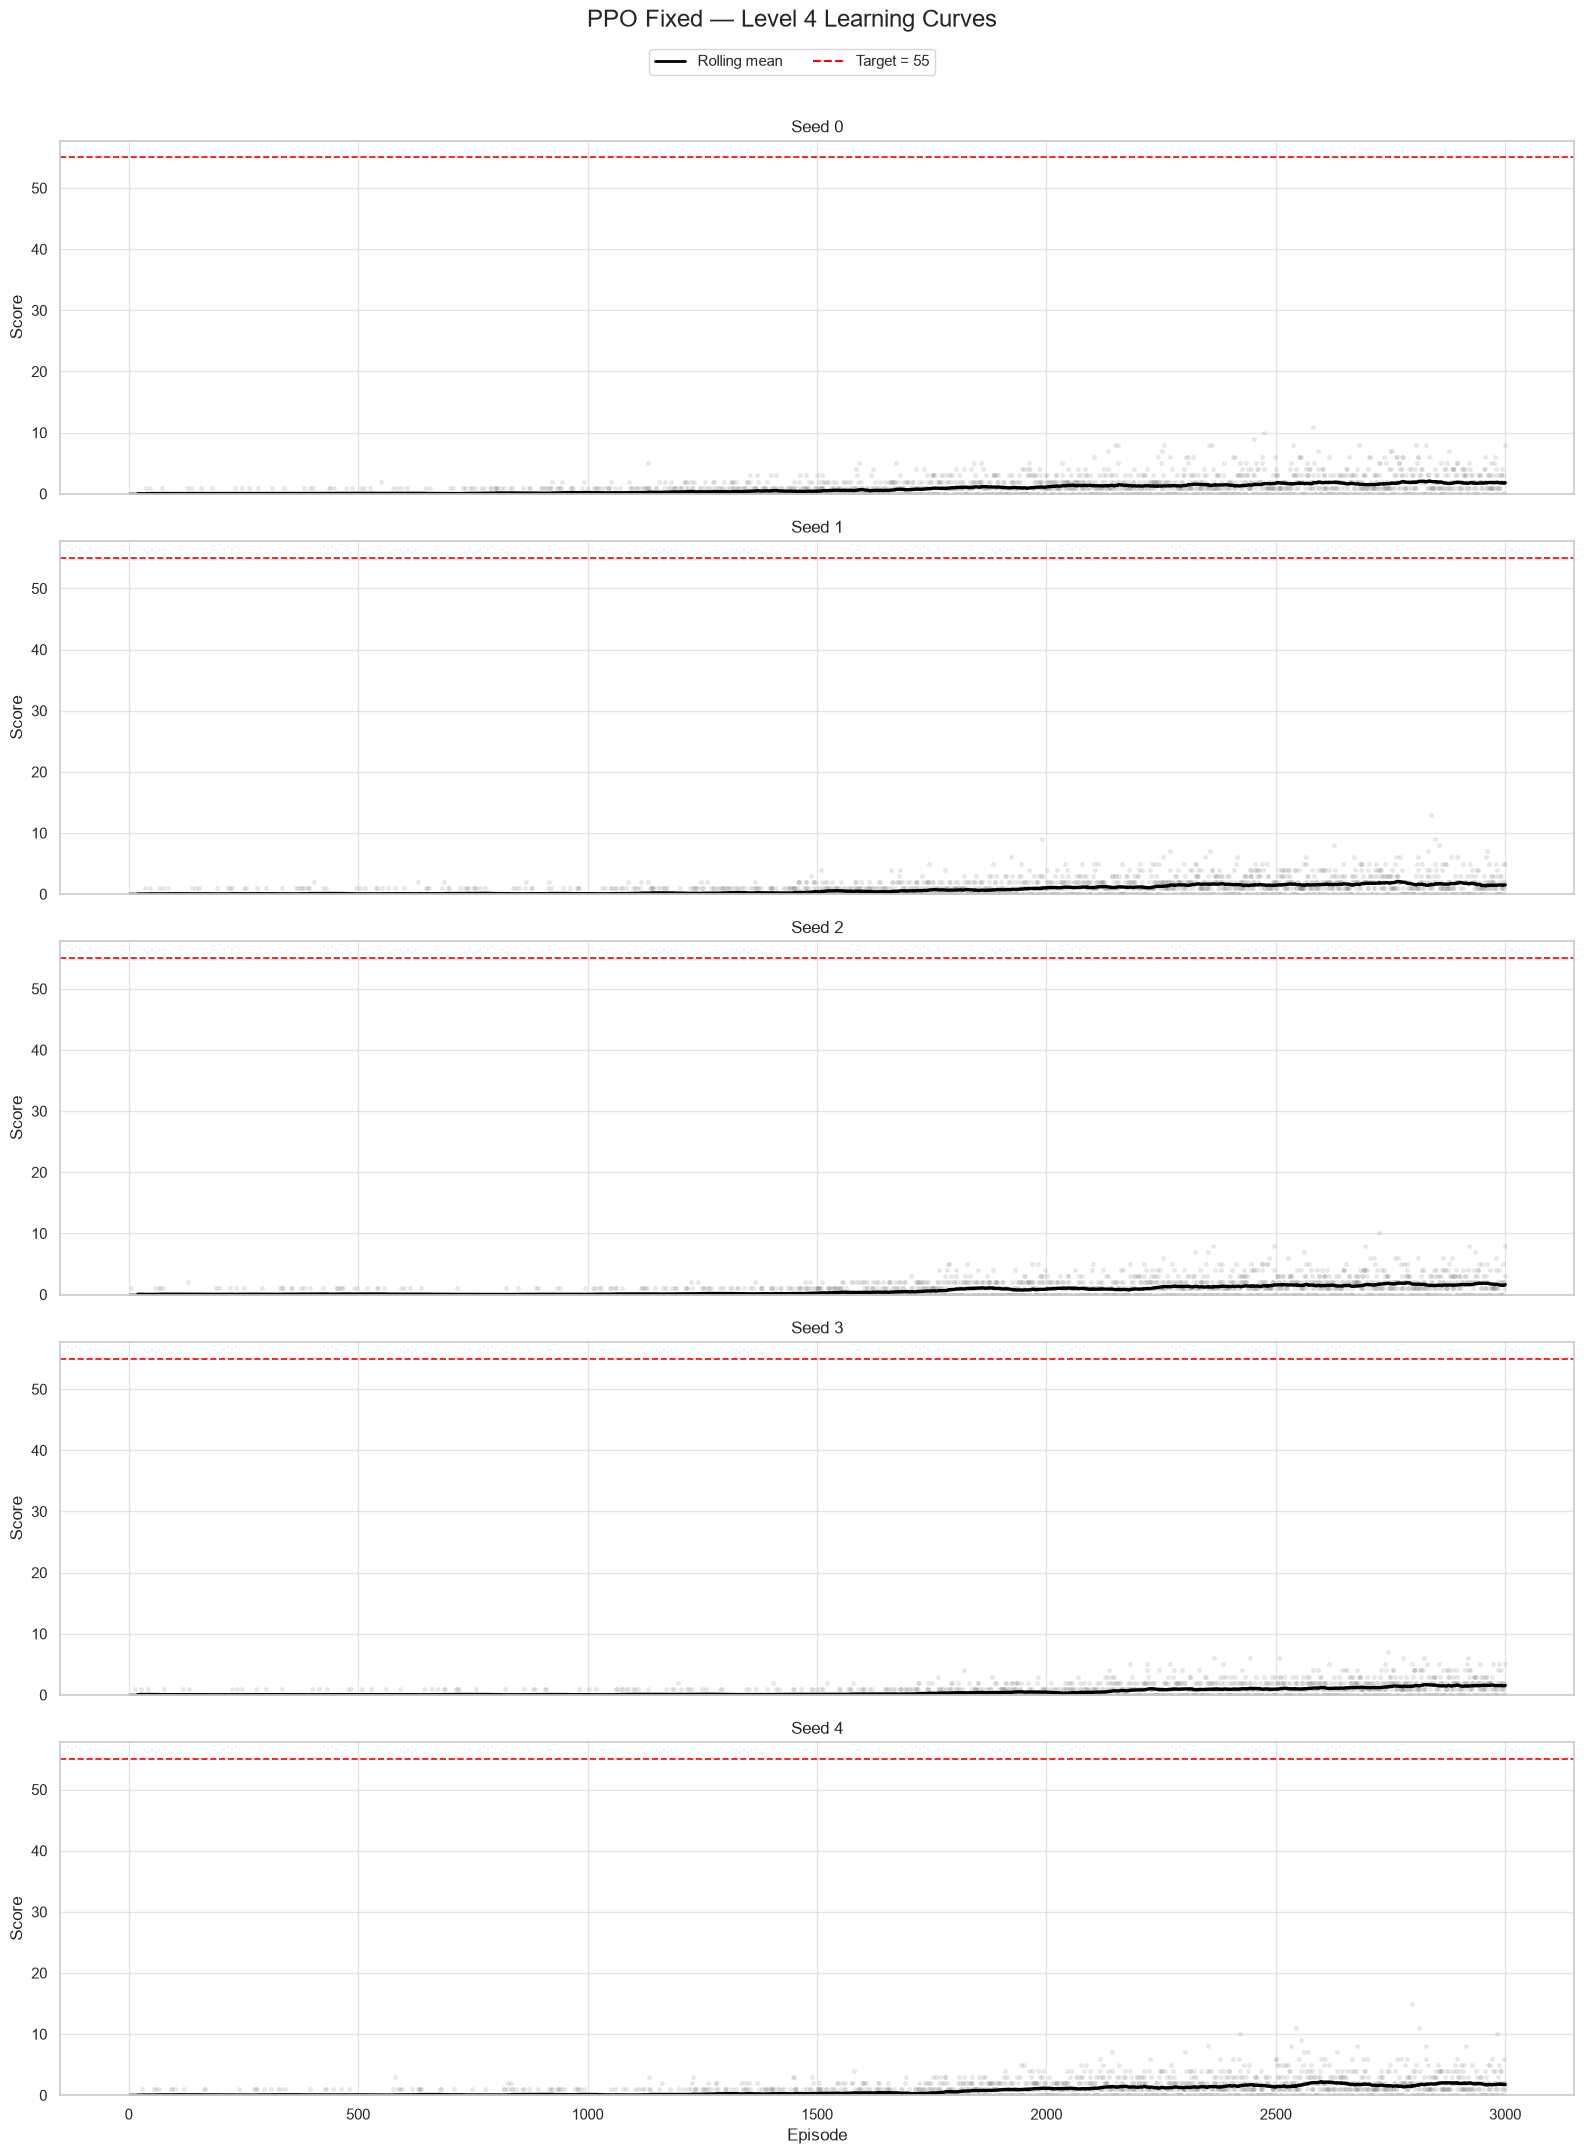

In [65]:
assert ppo_fixed["level"].dropna().eq("level4").all()

plot_five_seed_learning_curves(
    data=ppo_fixed,
    title="PPO Fixed — Level 4 Learning Curves",
    target=55,
)

Phân phối score PPO Fixed

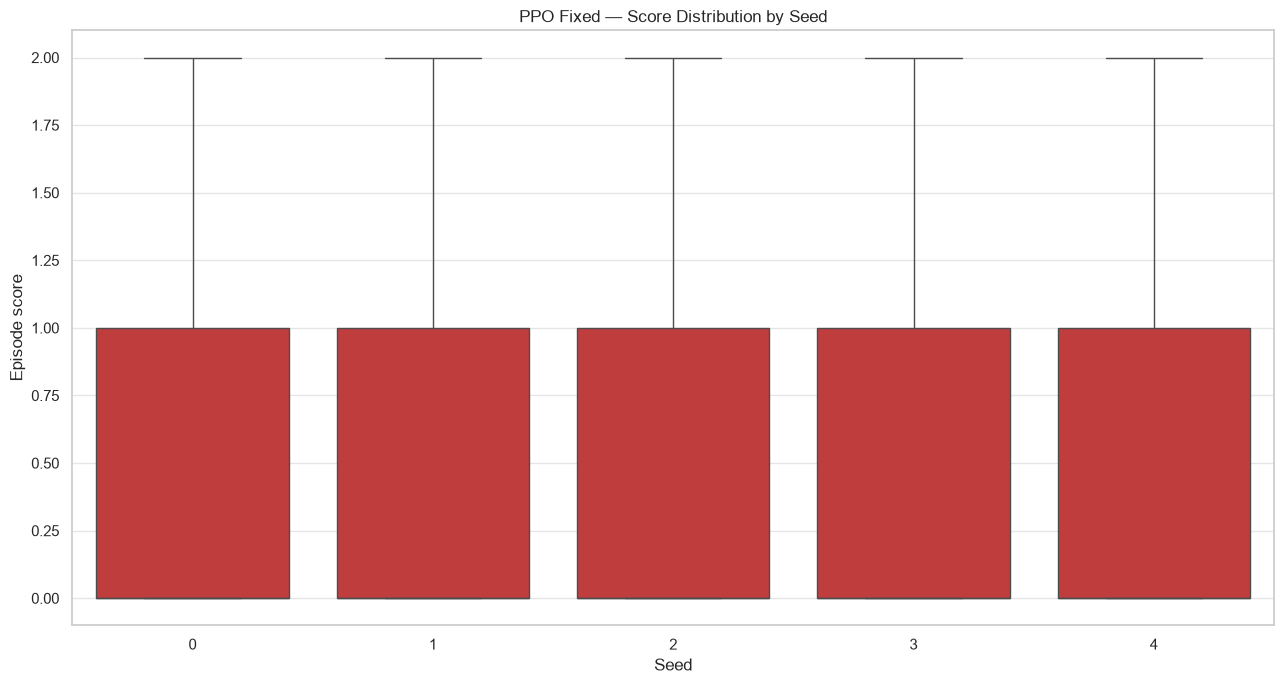

In [66]:
plt.figure(figsize=(13, 7))

sns.boxplot(
    data=ppo_fixed,
    x="seed",
    y="score",
    showfliers=False,
    color=LEVEL_COLORS["level4"],
)

plt.title("PPO Fixed — Score Distribution by Seed")
plt.xlabel("Seed")
plt.ylabel("Episode score")
plt.tight_layout()
plt.show()

PPO Random DR

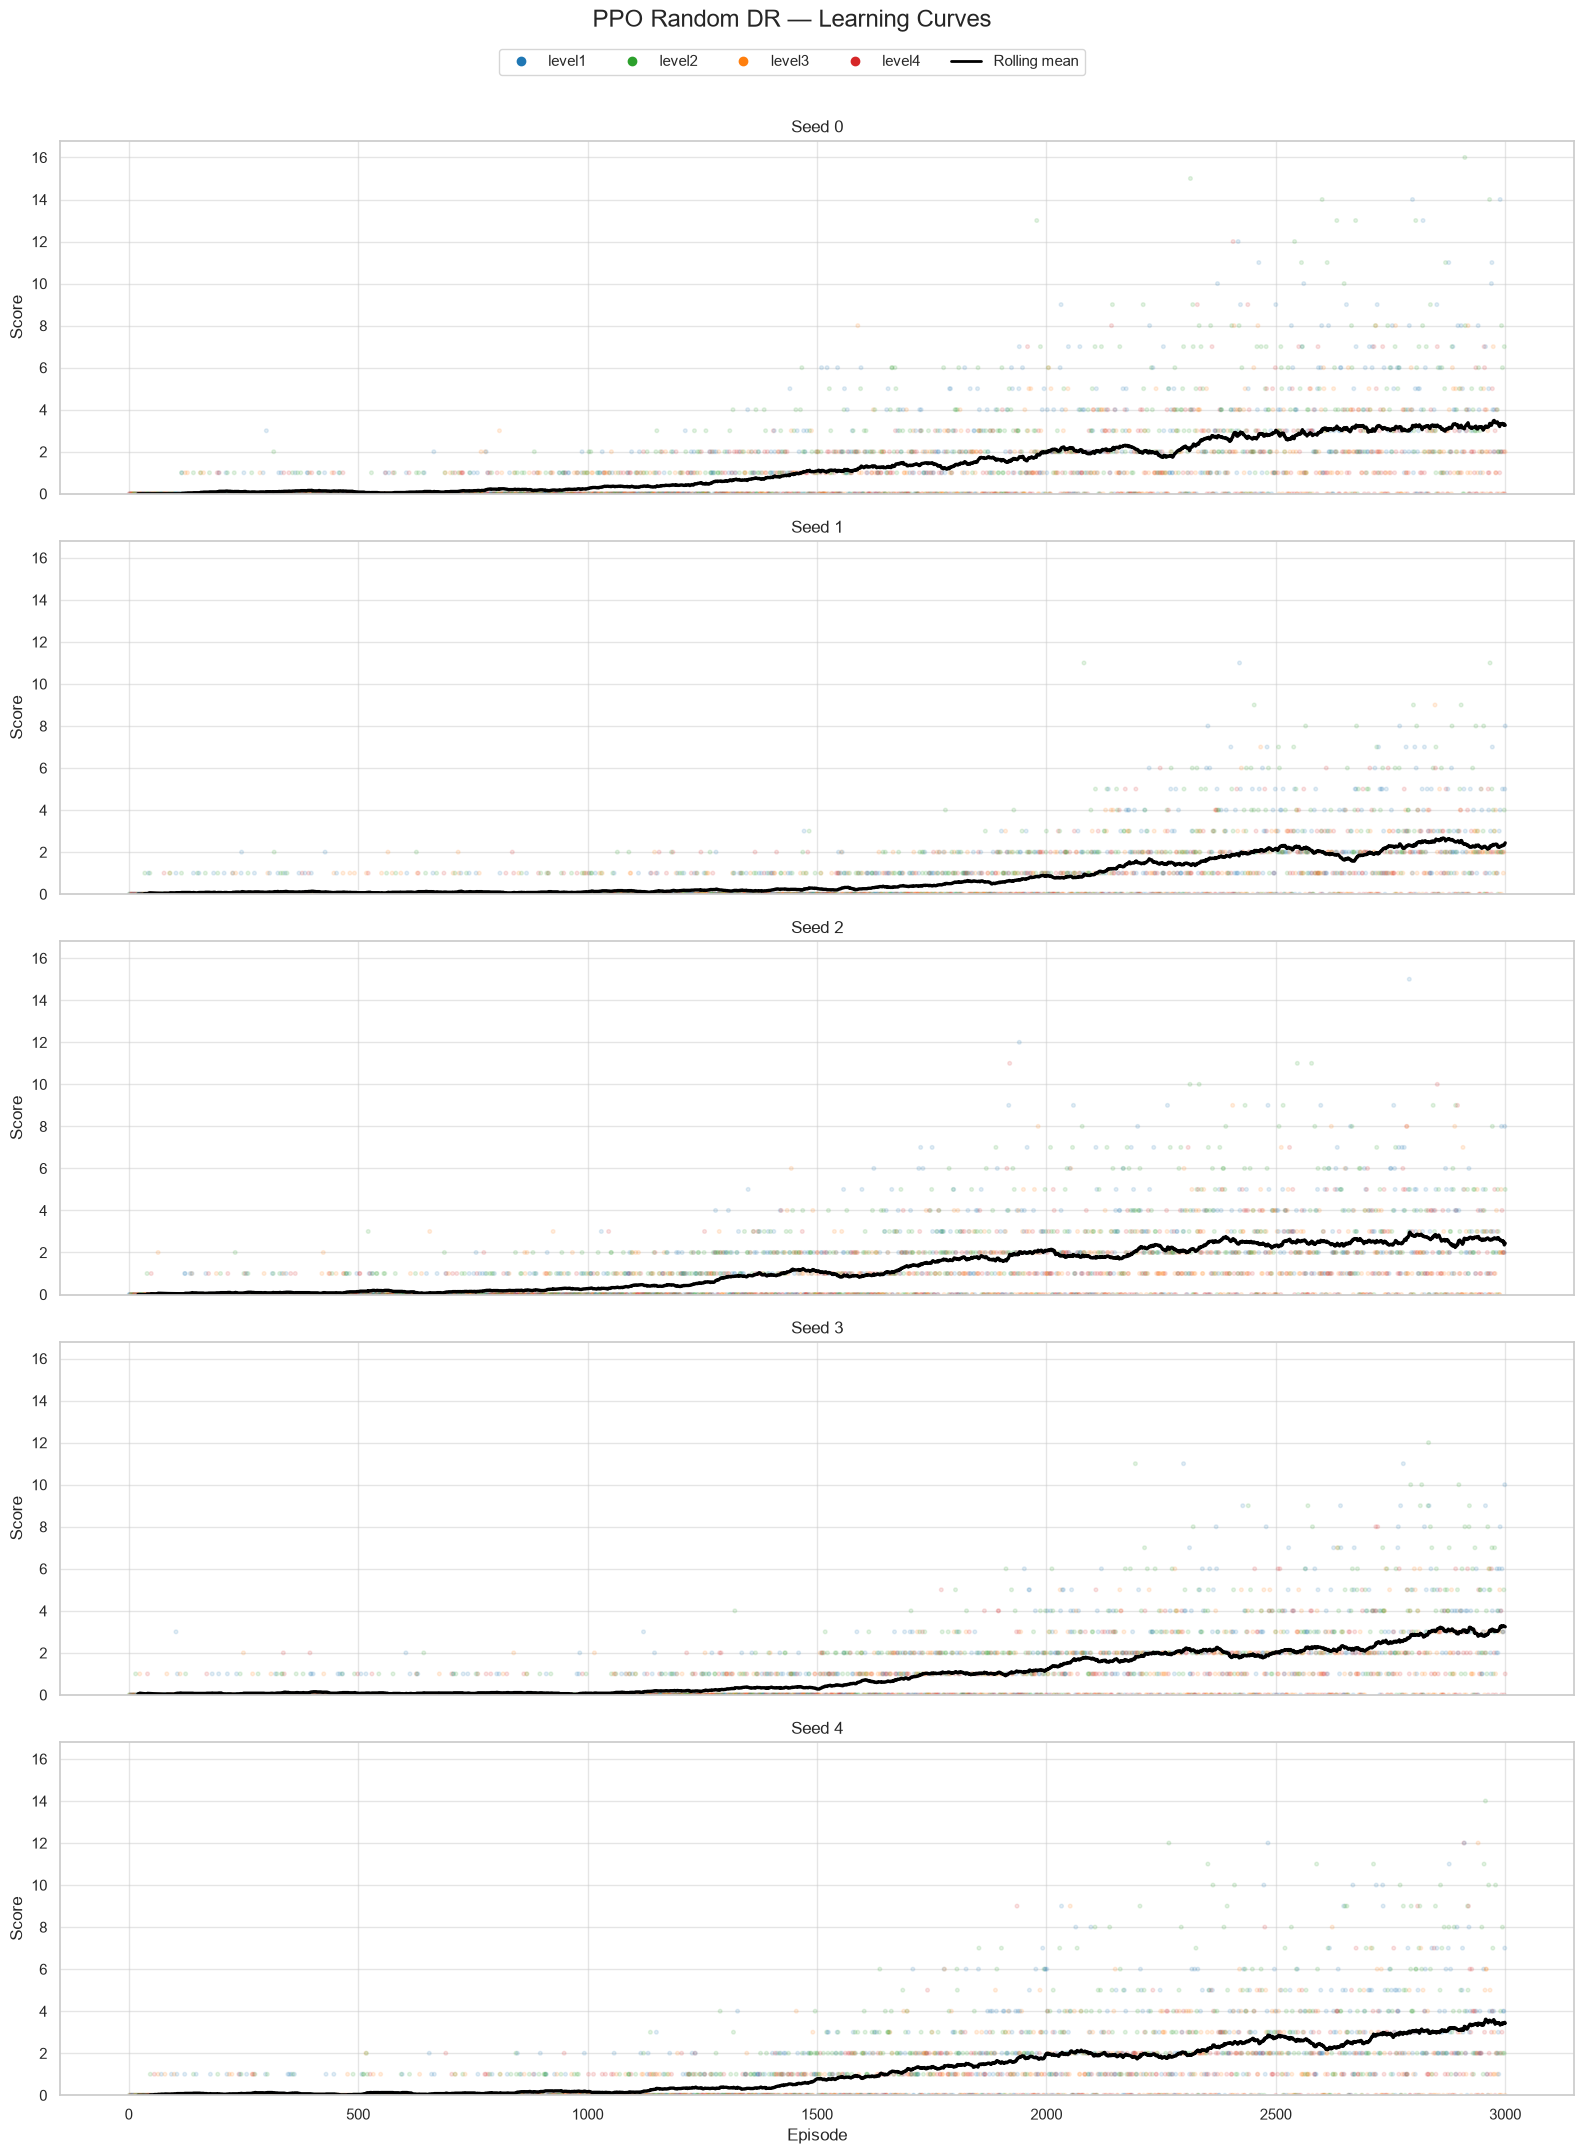

In [67]:
plot_five_seed_learning_curves(
    data=ppo_random,
    title="PPO Random DR — Learning Curves",
    point_colors_by_level=True,
)

In [68]:
ppo_random_level_counts = (
    ppo_random.groupby(
        ["seed", "level"],
        observed=True,
    )
    .size()
    .rename("episodes")
    .reset_index()
)

display(ppo_random_level_counts)

,seed,level,episodes
0,0,level1,752
1,0,level2,747
2,0,level3,730
3,0,level4,771
4,1,level1,748
5,1,level2,744
6,1,level3,765
7,1,level4,743
8,2,level1,734
9,2,level2,763


In [69]:
ppo_random_level_count_table = (
    ppo_random_level_counts.pivot(
        index="seed",
        columns="level",
        values="episodes",
    )
)

display(ppo_random_level_count_table)

level,level1,level2,level3,level4
seed,,,,
0,752,747,730,771
1,748,744,765,743
2,734,763,740,763
3,737,724,785,754
4,744,777,763,716


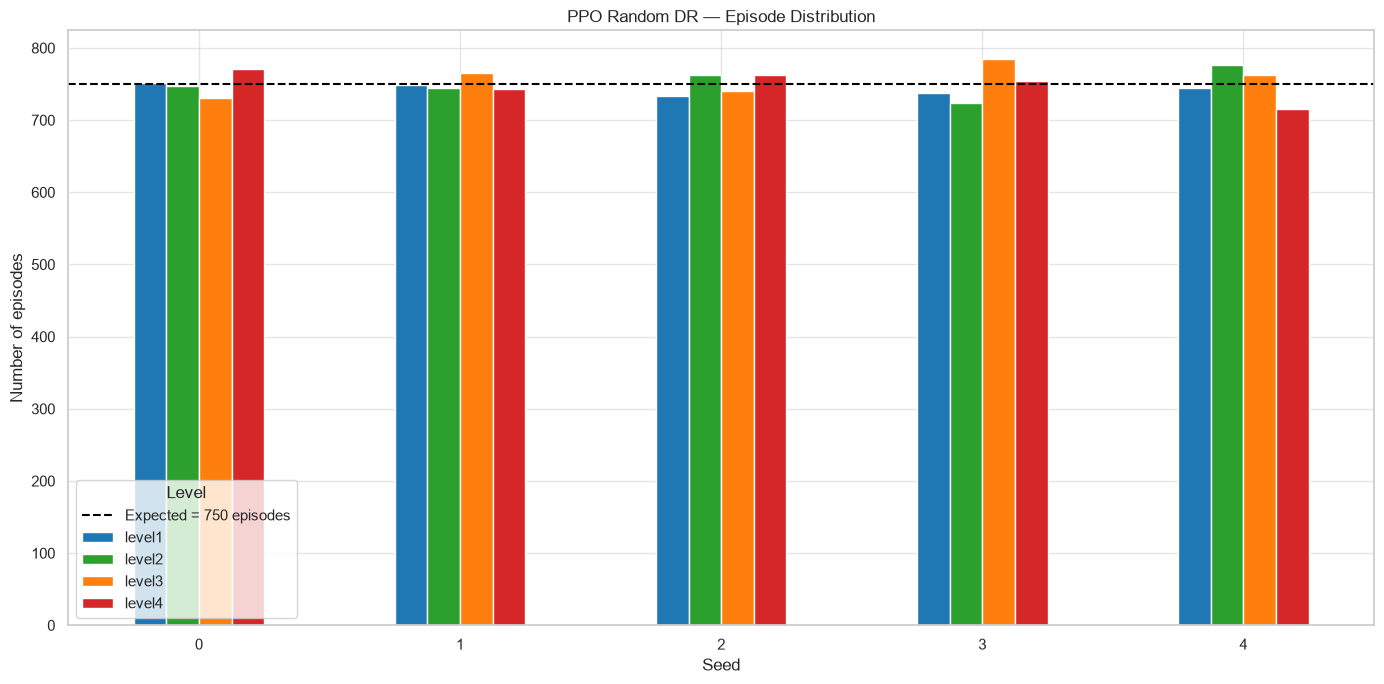

In [70]:
ax = ppo_random_level_count_table.plot(
    kind="bar",
    figsize=(14, 7),
    color=[
        LEVEL_COLORS[level]
        for level in ppo_random_level_count_table.columns
    ],
)

ax.axhline(
    750,
    color="black",
    linestyle="--",
    label="Expected = 750 episodes",
)

ax.set_title("PPO Random DR — Episode Distribution")
ax.set_xlabel("Seed")
ax.set_ylabel("Number of episodes")
ax.tick_params(axis="x", rotation=0)
ax.legend(title="Level")

plt.tight_layout()
plt.show()

In [71]:
BIN_SIZE = 100

ppo_random["episode_bin"] = (
    ((ppo_random["episode"] - 1) // BIN_SIZE)
    * BIN_SIZE
    + 1
)

ppo_random_binned = (
    ppo_random.groupby(
        ["seed", "episode_bin", "level"],
        observed=True,
    )
    .agg(
        mean_score=("score", "mean"),
        number_of_episodes=("score", "size"),
    )
    .reset_index()
)

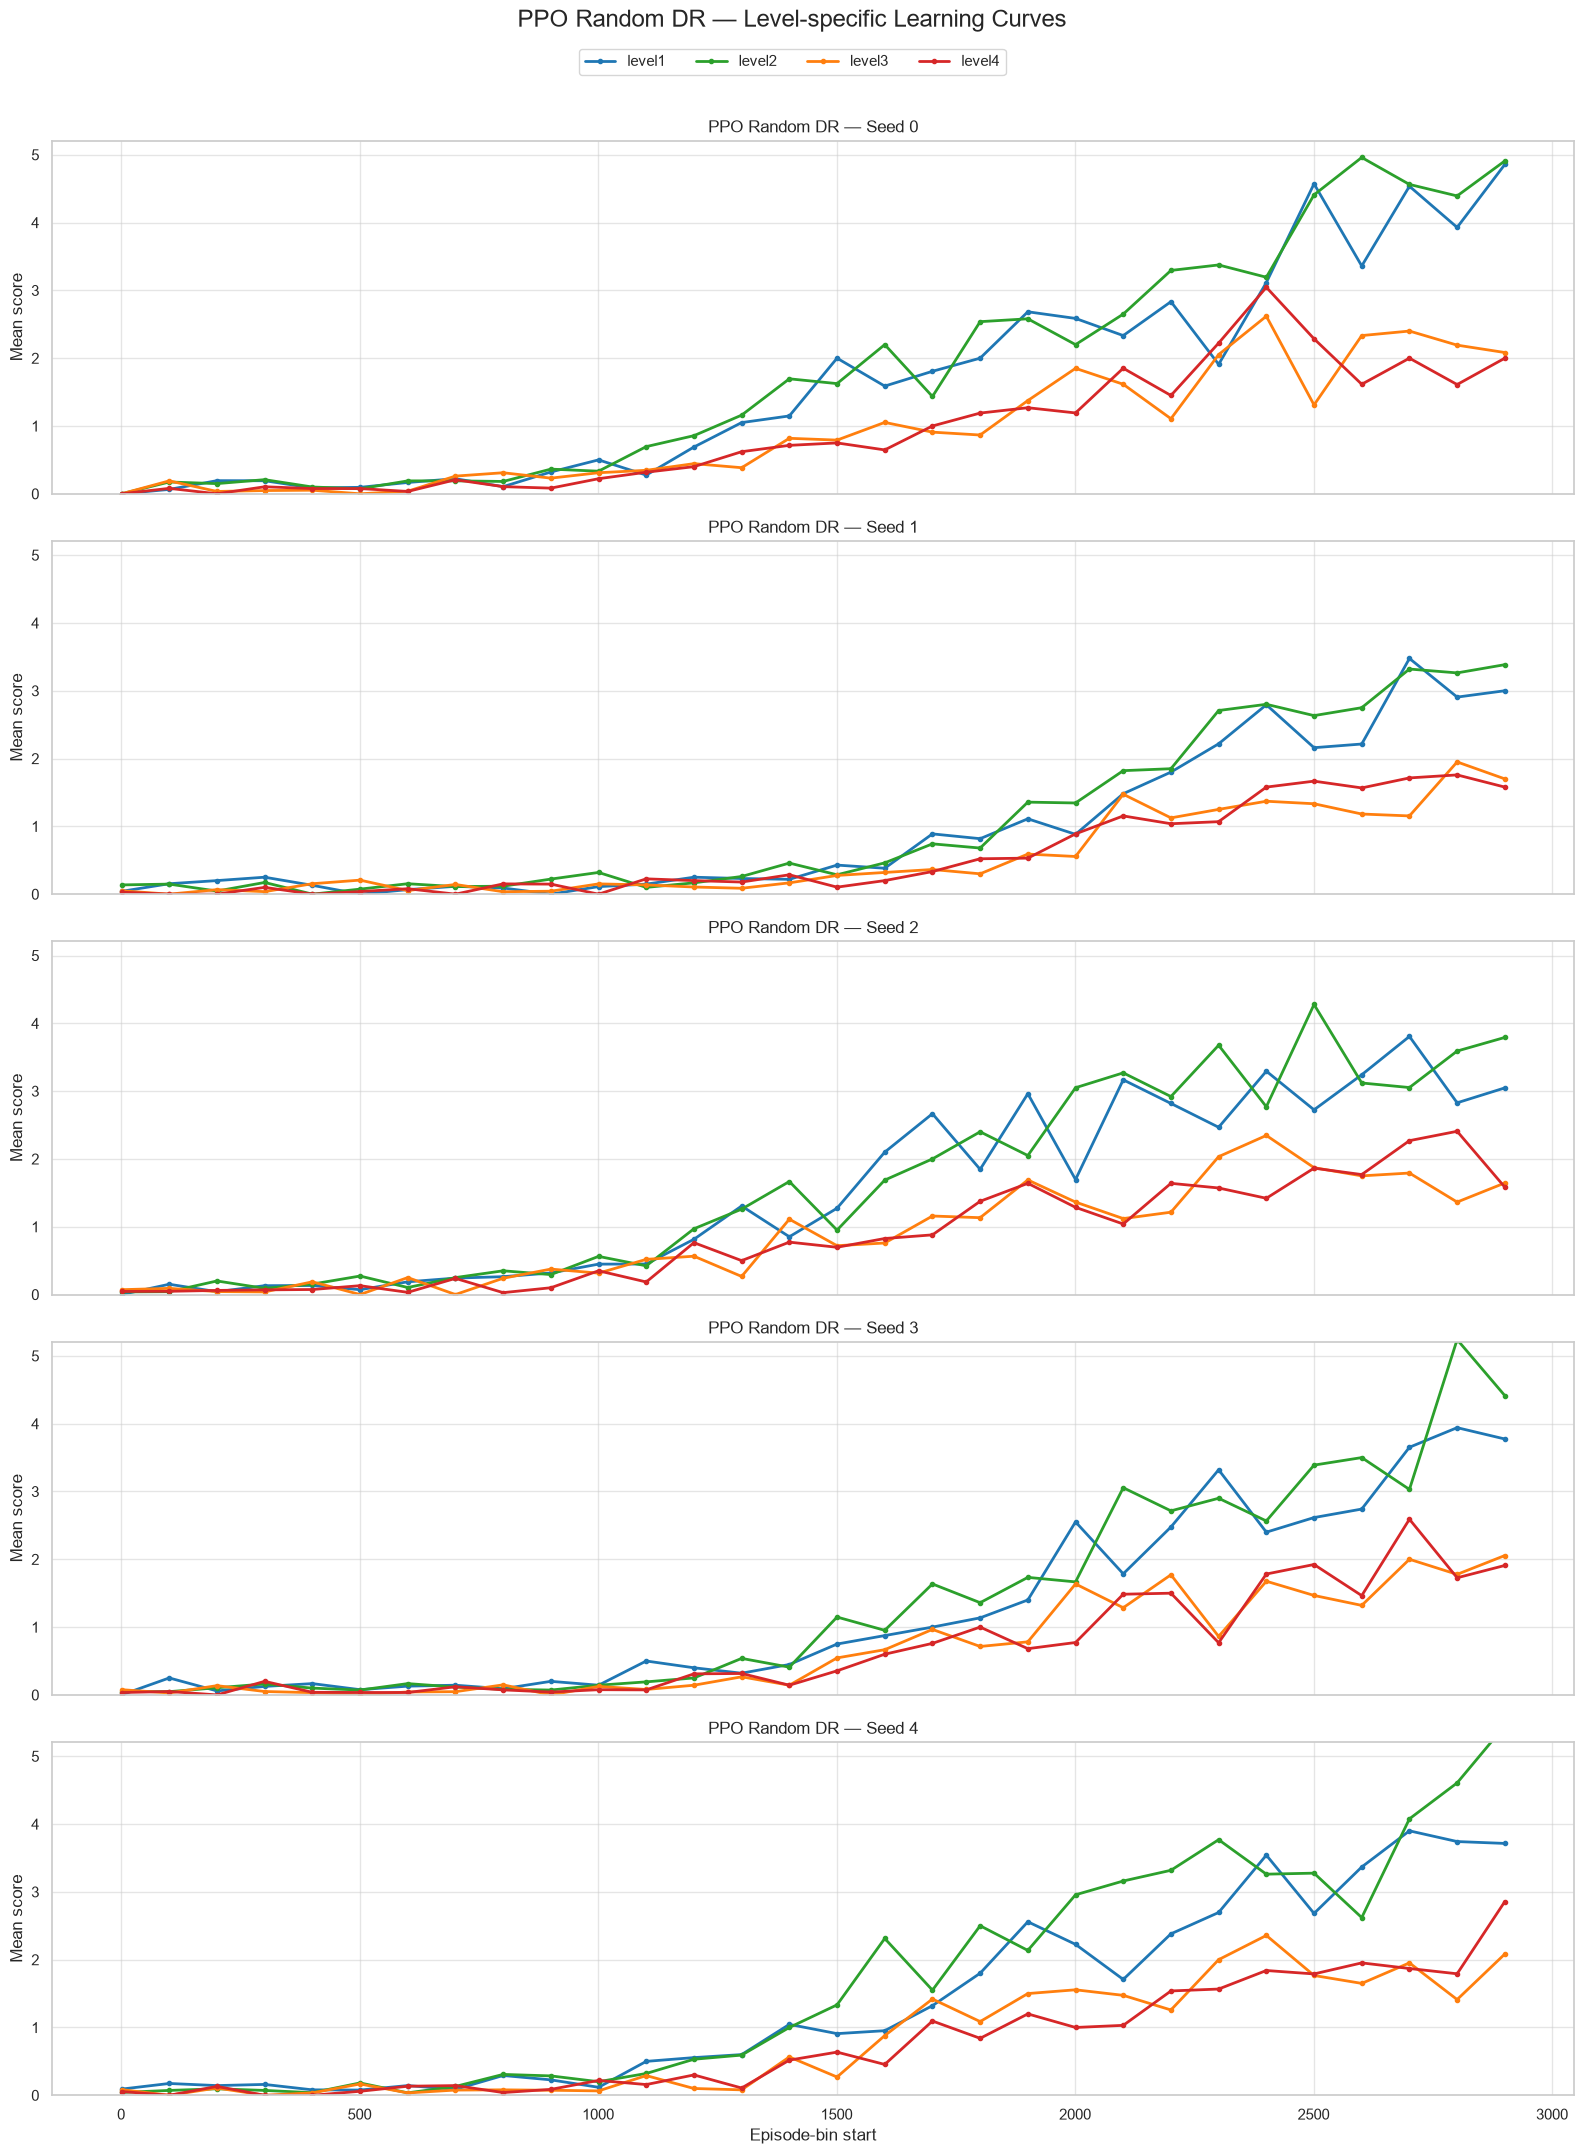

In [72]:
fig, axes = plt.subplots(
    5,
    1,
    figsize=(16, 21),
    sharex=True,
    sharey=True,
)

for seed, ax in zip(range(5), axes):
    seed_data = ppo_random_binned[
        ppo_random_binned["seed"] == seed
    ]

    for level in LEVEL_ORDER:
        level_data = seed_data[
            seed_data["level"] == level
        ]

        ax.plot(
            level_data["episode_bin"],
            level_data["mean_score"],
            color=LEVEL_COLORS[level],
            linewidth=2,
            marker="o",
            markersize=3,
            label=level,
        )

    ax.set_title(f"PPO Random DR — Seed {seed}")
    ax.set_ylabel("Mean score")
    ax.set_ylim(bottom=0)

axes[-1].set_xlabel("Episode-bin start")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.01),
)

fig.suptitle(
    "PPO Random DR — Level-specific Learning Curves",
    fontsize=17,
    y=1.025,
)

plt.tight_layout()
plt.show()

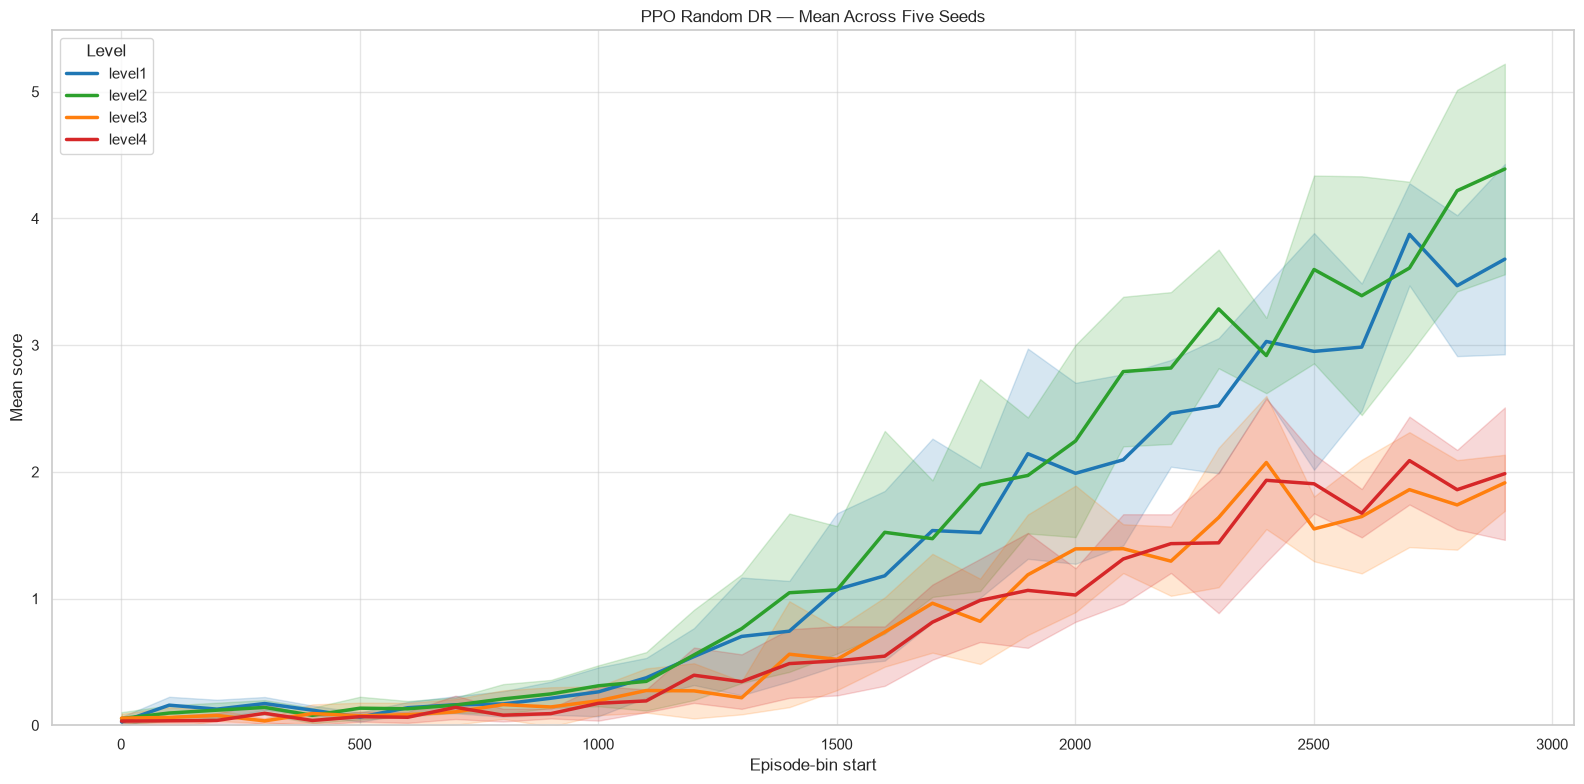

In [73]:
ppo_random_binned_mean = (
    ppo_random_binned.groupby(
        ["episode_bin", "level"],
        observed=True,
    )
    .agg(
        mean_score=("mean_score", "mean"),
        std_across_seeds=("mean_score", "std"),
    )
    .reset_index()
)

plt.figure(figsize=(16, 8))

for level in LEVEL_ORDER:
    level_data = ppo_random_binned_mean[
        ppo_random_binned_mean["level"] == level
    ]

    x = level_data["episode_bin"].to_numpy()
    mean = level_data["mean_score"].to_numpy()
    std = level_data["std_across_seeds"].to_numpy()

    plt.plot(
        x,
        mean,
        color=LEVEL_COLORS[level],
        linewidth=2.5,
        label=level,
    )

    plt.fill_between(
        x,
        mean - std,
        mean + std,
        color=LEVEL_COLORS[level],
        alpha=0.18,
    )

plt.title("PPO Random DR — Mean Across Five Seeds")
plt.xlabel("Episode-bin start")
plt.ylabel("Mean score")
plt.ylim(bottom=0)
plt.legend(title="Level")
plt.tight_layout()
plt.show()

PPO Curriculum

In [74]:
ppo_curriculum_level_counts = (
    ppo_curriculum.groupby(
        ["seed", "level"],
        observed=True,
    )
    .size()
    .rename("episodes")
    .reset_index()
)

display(ppo_curriculum_level_counts)

,seed,level,episodes
0,0,level1,3000
1,1,level1,3000
2,2,level1,3000
3,3,level1,3000
4,4,level1,3000


In [75]:
assert ppo_curriculum["level"].dropna().eq("level1").all()
assert ppo_curriculum["mastered_level"].eq("").all()

print(
    "Cả 5 PPO Curriculum seed đều ở Level 1 "
    "trong toàn bộ 3.000 episode."
)

Cả 5 PPO Curriculum seed đều ở Level 1 trong toàn bộ 3.000 episode.


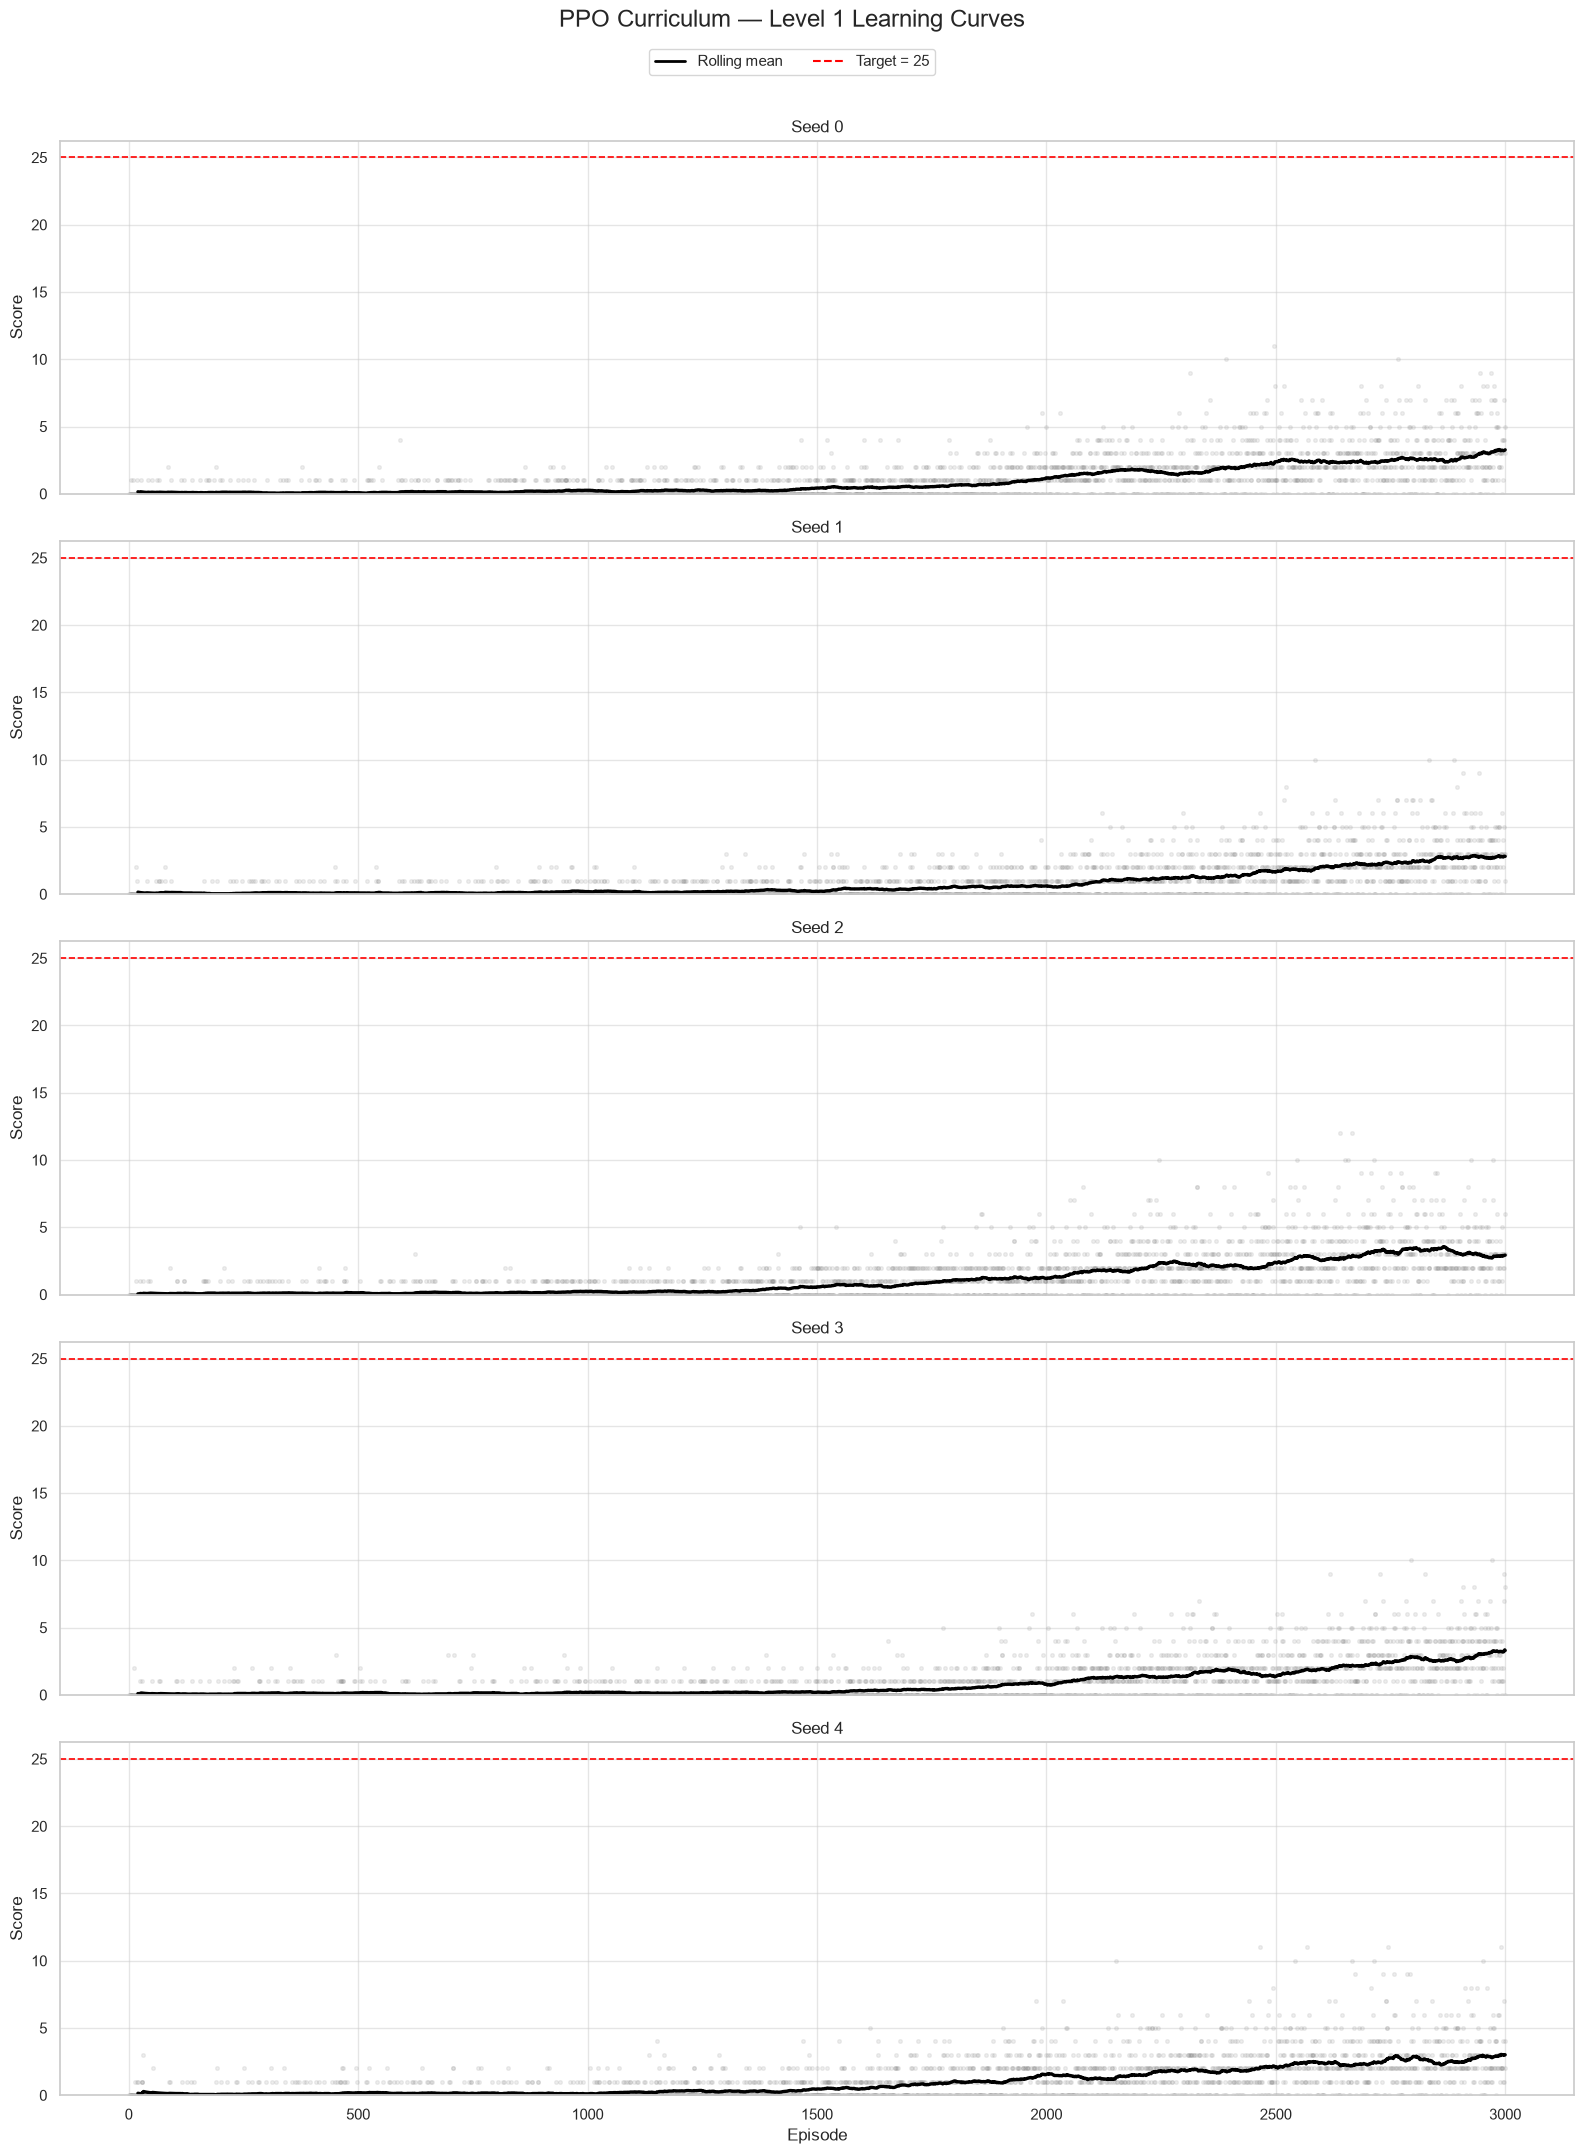

In [76]:
plot_five_seed_learning_curves(
    data=ppo_curriculum,
    title="PPO Curriculum — Level 1 Learning Curves",
    target=25,
)

In [77]:
ppo_curriculum_target_analysis = (
    ppo_curriculum.groupby("seed")
    .agg(
        mean_score=("score", "mean"),
        max_score=("score", "max"),
        p90_score=("score", lambda x: x.quantile(0.90)),
        mean_steps=("steps", "mean"),
    )
    .reset_index()
)

ppo_curriculum_target_analysis["target"] = 25
ppo_curriculum_target_analysis["distance_to_target"] = (
    ppo_curriculum_target_analysis["target"]
    - ppo_curriculum_target_analysis["max_score"]
)

display(
    ppo_curriculum_target_analysis.round(3)
)

,seed,mean_score,max_score,p90_score,mean_steps,target,distance_to_target
0,0,0.946,11.0,3.0,17.403,25,14.0
1,1,0.764,10.0,3.0,17.167,25,15.0
2,2,1.107,12.0,3.0,19.003,25,13.0
3,3,0.826,10.0,3.0,18.071,25,15.0
4,4,0.974,11.0,3.0,18.631,25,14.0


So sánh learning curve trung bình của ba PPO

In [78]:
ppo_combined_rolling = pd.concat(
    [
        ppo_fixed,
        ppo_random,
        ppo_curriculum,
    ],
    ignore_index=True,
)

ppo_mean_curves = (
    ppo_combined_rolling.groupby(
        ["configuration", "episode"],
        observed=True,
    )
    .agg(
        mean_rolling_score=("rolling_score", "mean"),
        std_rolling_score=("rolling_score", "std"),
    )
    .reset_index()
)

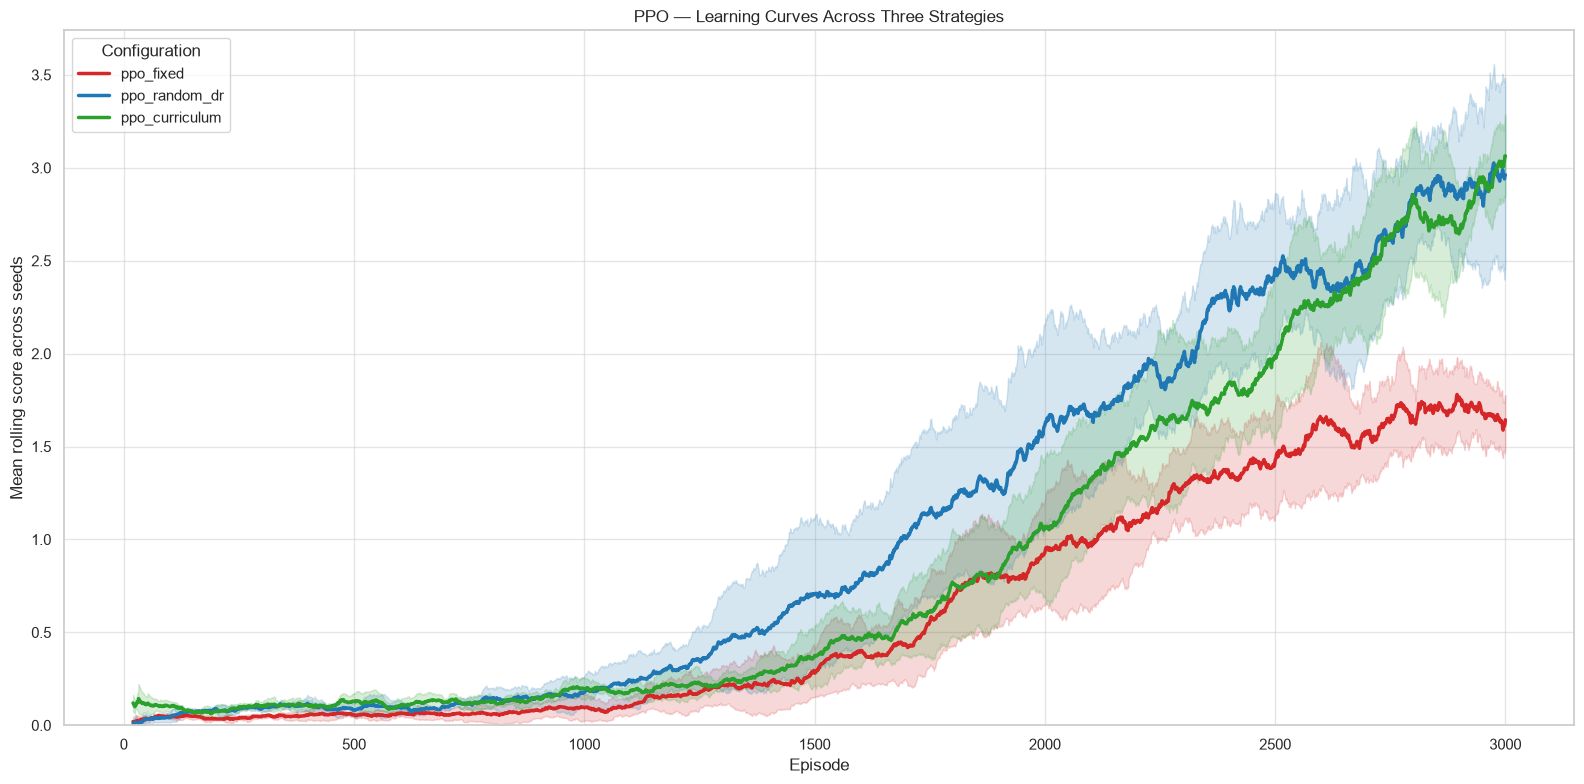

In [79]:
configuration_colors = {
    "ppo_fixed": "#d62728",
    "ppo_random_dr": "#1f77b4",
    "ppo_curriculum": "#2ca02c",
}

plt.figure(figsize=(16, 8))

for configuration, color in configuration_colors.items():
    config_data = ppo_mean_curves[
        ppo_mean_curves["configuration"]
        == configuration
    ]

    x = config_data["episode"].to_numpy()
    mean = config_data["mean_rolling_score"].to_numpy()
    std = config_data["std_rolling_score"].to_numpy()

    plt.plot(
        x,
        mean,
        color=color,
        linewidth=2.5,
        label=configuration,
    )

    plt.fill_between(
        x,
        mean - std,
        mean + std,
        color=color,
        alpha=0.18,
    )

plt.title("PPO — Learning Curves Across Three Strategies")
plt.xlabel("Episode")
plt.ylabel("Mean rolling score across seeds")
plt.ylim(bottom=0)
plt.legend(title="Configuration")
plt.tight_layout()
plt.show()

Death cause của cả ba PPO

In [80]:
ppo_death_summary = (
    ppo_all.groupby(
        [
            "configuration",
            "seed",
            "level",
            "death_cause",
        ],
        observed=True,
    )
    .size()
    .rename("count")
    .reset_index()
)

ppo_death_summary["percentage"] = (
    ppo_death_summary["count"]
    / ppo_death_summary.groupby(
        ["configuration", "seed", "level"],
        observed=True,
    )["count"].transform("sum")
    * 100
)

ppo_death_summary["percentage"] = (
    ppo_death_summary["percentage"].round(2)
)

display(ppo_death_summary)

,configuration,seed,level,death_cause,count,percentage
0,ppo_curriculum,0,level1,self,359,11.97
1,ppo_curriculum,0,level1,wall,2641,88.03
2,ppo_curriculum,1,level1,self,296,9.87
3,ppo_curriculum,1,level1,wall,2704,90.13
4,ppo_curriculum,2,level1,self,456,15.20
...,...,...,...,...,...,...
70,ppo_random_dr,4,level3,self,53,6.95
71,ppo_random_dr,4,level3,wall,368,48.23
72,ppo_random_dr,4,level4,obstacle,376,52.51
73,ppo_random_dr,4,level4,self,46,6.42


In [81]:
ppo_death_overall = (
    ppo_all.groupby(
        ["configuration", "death_cause"],
        observed=True,
    )
    .size()
    .rename("count")
    .reset_index()
)

ppo_death_overall["percentage"] = (
    ppo_death_overall["count"]
    / ppo_death_overall.groupby(
        "configuration"
    )["count"].transform("sum")
    * 100
)

display(ppo_death_overall.round(2))

,configuration,death_cause,count,percentage
0,ppo_curriculum,self,1807,12.05
1,ppo_curriculum,wall,13193,87.95
2,ppo_fixed,obstacle,7260,48.40
3,ppo_fixed,self,939,6.26
4,ppo_fixed,wall,6801,45.34
5,ppo_random_dr,obstacle,3578,23.85
6,ppo_random_dr,self,2029,13.53
7,ppo_random_dr,wall,9393,62.62


Stacked bar death cause của ba PPO

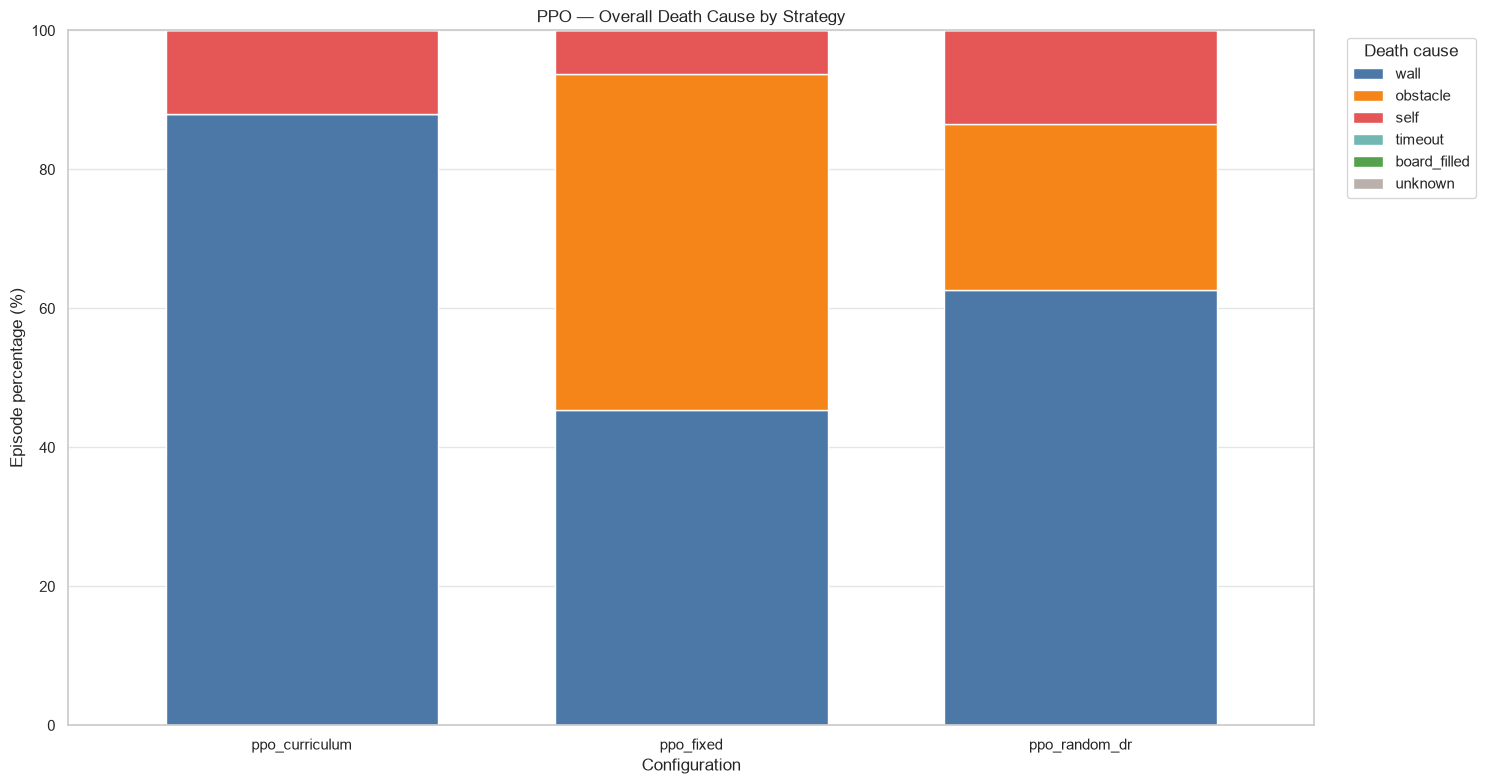

In [82]:
ppo_death_configuration_plot = (
    ppo_death_overall.pivot_table(
        index="configuration",
        columns="death_cause",
        values="percentage",
        fill_value=0,
    )
    .reindex(columns=DEATH_ORDER, fill_value=0)
)

ax = ppo_death_configuration_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(15, 8),
    color=[
        DEATH_COLORS[cause]
        for cause in ppo_death_configuration_plot.columns
    ],
    width=0.7,
)

ax.set_title("PPO — Overall Death Cause by Strategy")
ax.set_xlabel("Configuration")
ax.set_ylabel("Episode percentage (%)")
ax.set_ylim(0, 100)
ax.tick_params(axis="x", rotation=0)
ax.legend(
    title="Death cause",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

Death cause chi tiết theo seed và level

In [83]:
def plot_death_causes_by_seed(data, configuration_name):
    summary = (
        data.groupby(
            ["seed", "level", "death_cause"],
            observed=True,
        )
        .size()
        .rename("count")
        .reset_index()
    )

    summary["percentage"] = (
        summary["count"]
        / summary.groupby(
            ["seed", "level"],
            observed=True,
        )["count"].transform("sum")
        * 100
    )

    pivot = (
        summary.pivot_table(
            index=["seed", "level"],
            columns="death_cause",
            values="percentage",
            fill_value=0,
        )
        .reindex(columns=DEATH_ORDER, fill_value=0)
    )

    fig, axes = plt.subplots(
        1,
        5,
        figsize=(24, 6),
        sharey=True,
    )

    for seed, ax in zip(range(5), axes):
        seed_plot = pivot.loc[seed]

        seed_plot.plot(
            kind="bar",
            stacked=True,
            ax=ax,
            width=0.8,
            legend=False,
            color=[
                DEATH_COLORS[cause]
                for cause in seed_plot.columns
            ],
        )

        ax.set_title(f"Seed {seed}")
        ax.set_xlabel("Level")
        ax.set_ylabel(
            "Episode percentage (%)"
            if seed == 0
            else ""
        )
        ax.set_ylim(0, 100)
        ax.tick_params(axis="x", rotation=0)

    handles, labels = axes[-1].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        title="Death cause",
        loc="upper center",
        ncol=max(1, len(labels)),
        bbox_to_anchor=(0.5, 1.04),
    )

    fig.suptitle(
        f"{configuration_name} — Death Cause by Seed and Level",
        fontsize=17,
        y=1.11,
    )

    plt.tight_layout()
    plt.show()

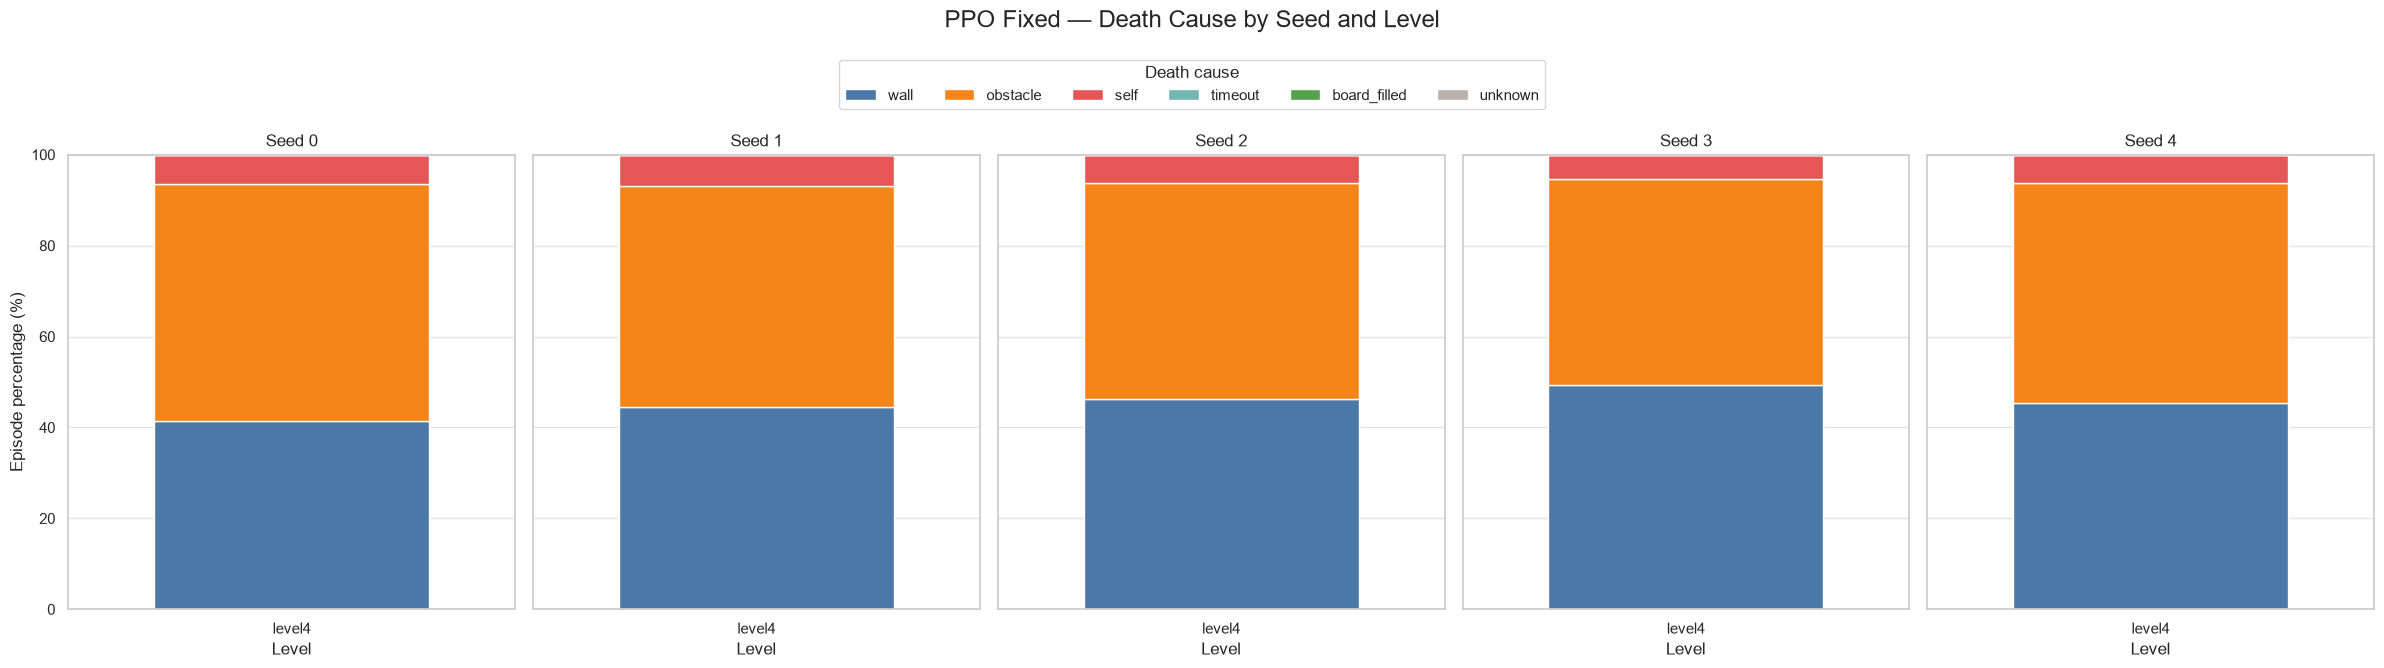

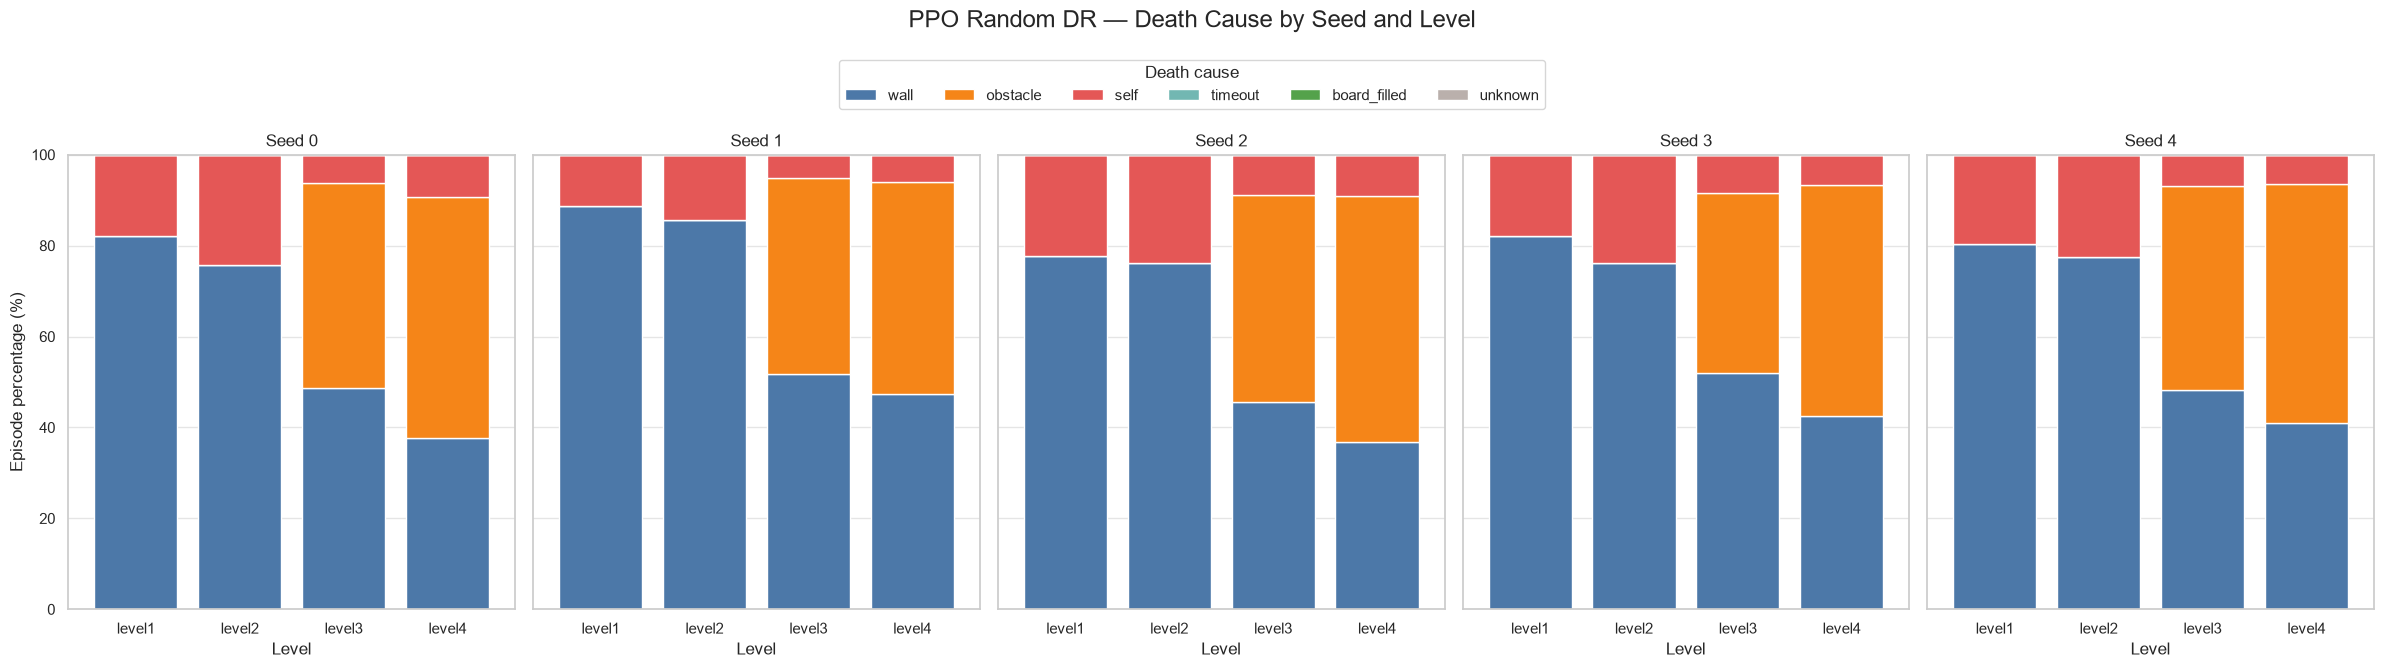

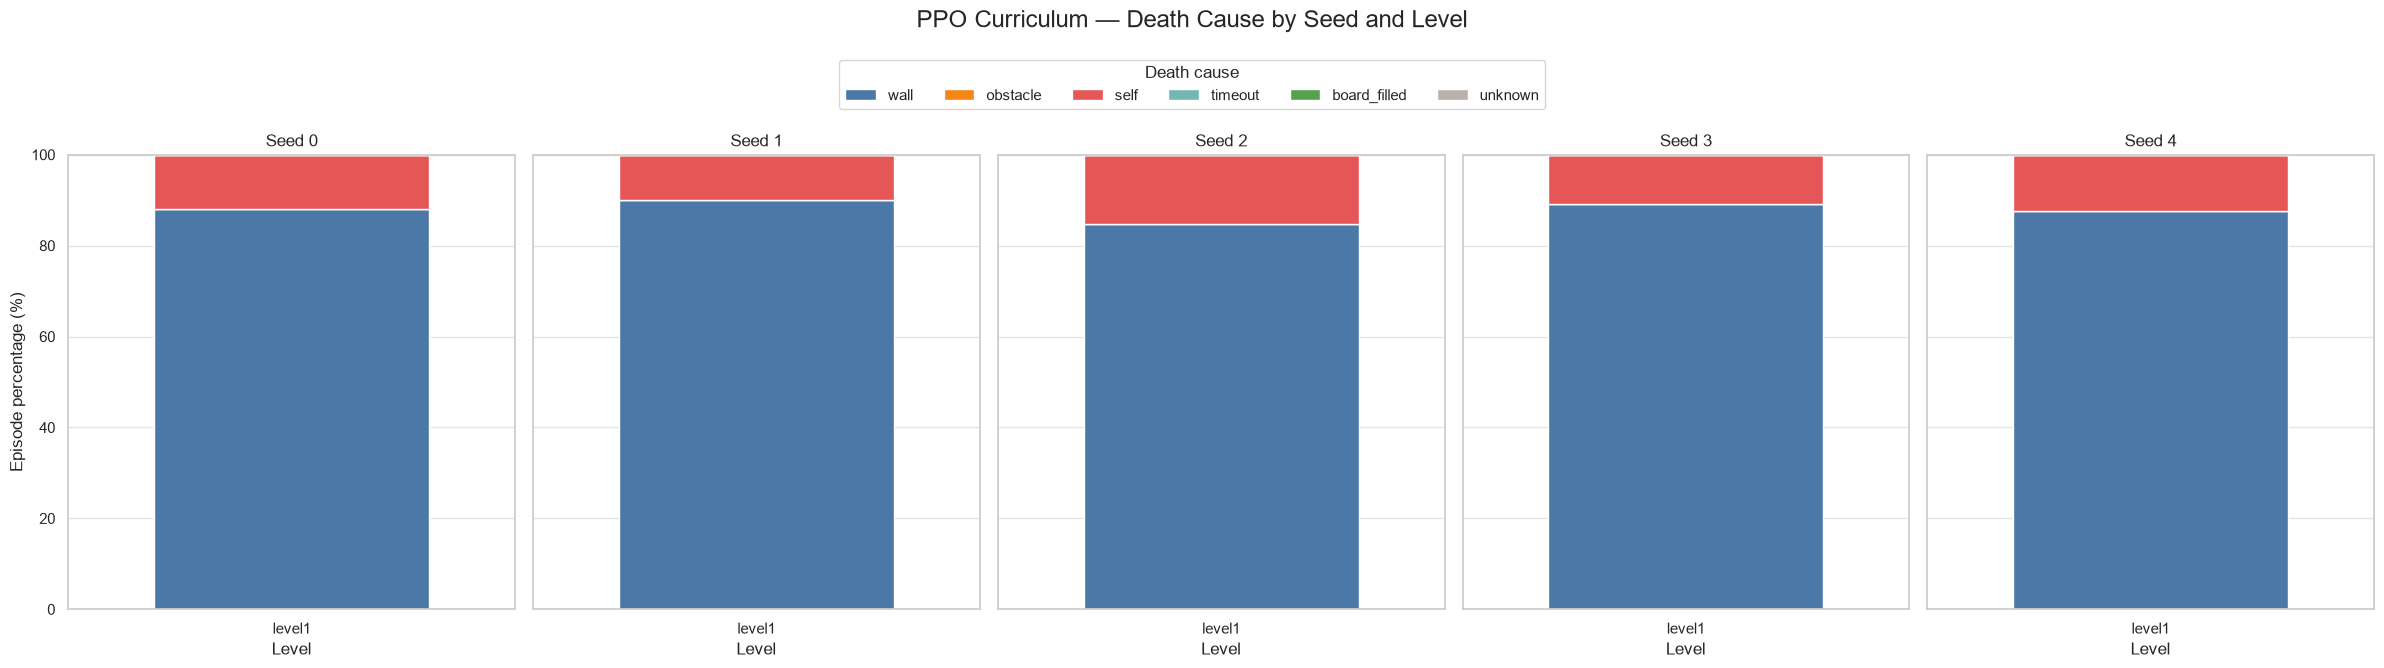

In [84]:
plot_death_causes_by_seed(
    ppo_fixed,
    "PPO Fixed",
)

plot_death_causes_by_seed(
    ppo_random,
    "PPO Random DR",
)

plot_death_causes_by_seed(
    ppo_curriculum,
    "PPO Curriculum",
)

Death cause thay đổi theo thời gian

In [85]:
def plot_death_causes_over_time(
    data,
    configuration_name,
    window=100,
):
    result = data.copy()
    tracked_causes = ["wall", "obstacle", "self"]

    for cause in tracked_causes:
        result[f"is_{cause}"] = (
            result["death_cause"] == cause
        ).astype(float)

        result[f"rolling_{cause}"] = (
            result.groupby("seed")[f"is_{cause}"]
            .transform(
                lambda x: x.rolling(
                    window,
                    min_periods=20,
                ).mean() * 100
            )
        )

    fig, axes = plt.subplots(
        5,
        1,
        figsize=(16, 20),
        sharex=True,
        sharey=True,
    )

    for seed, ax in zip(range(5), axes):
        seed_data = result[
            result["seed"] == seed
        ]

        for cause in tracked_causes:
            ax.plot(
                seed_data["episode"],
                seed_data[f"rolling_{cause}"],
                label=cause,
                color=DEATH_COLORS[cause],
                linewidth=2,
            )

        ax.set_title(f"Seed {seed}")
        ax.set_ylabel("Death rate (%)")
        ax.set_ylim(0, 100)

    axes[-1].set_xlabel("Episode")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=3,
        bbox_to_anchor=(0.5, 1.01),
    )

    fig.suptitle(
        f"{configuration_name} — Death Cause Over Training",
        fontsize=17,
        y=1.025,
    )

    plt.tight_layout()
    plt.show()

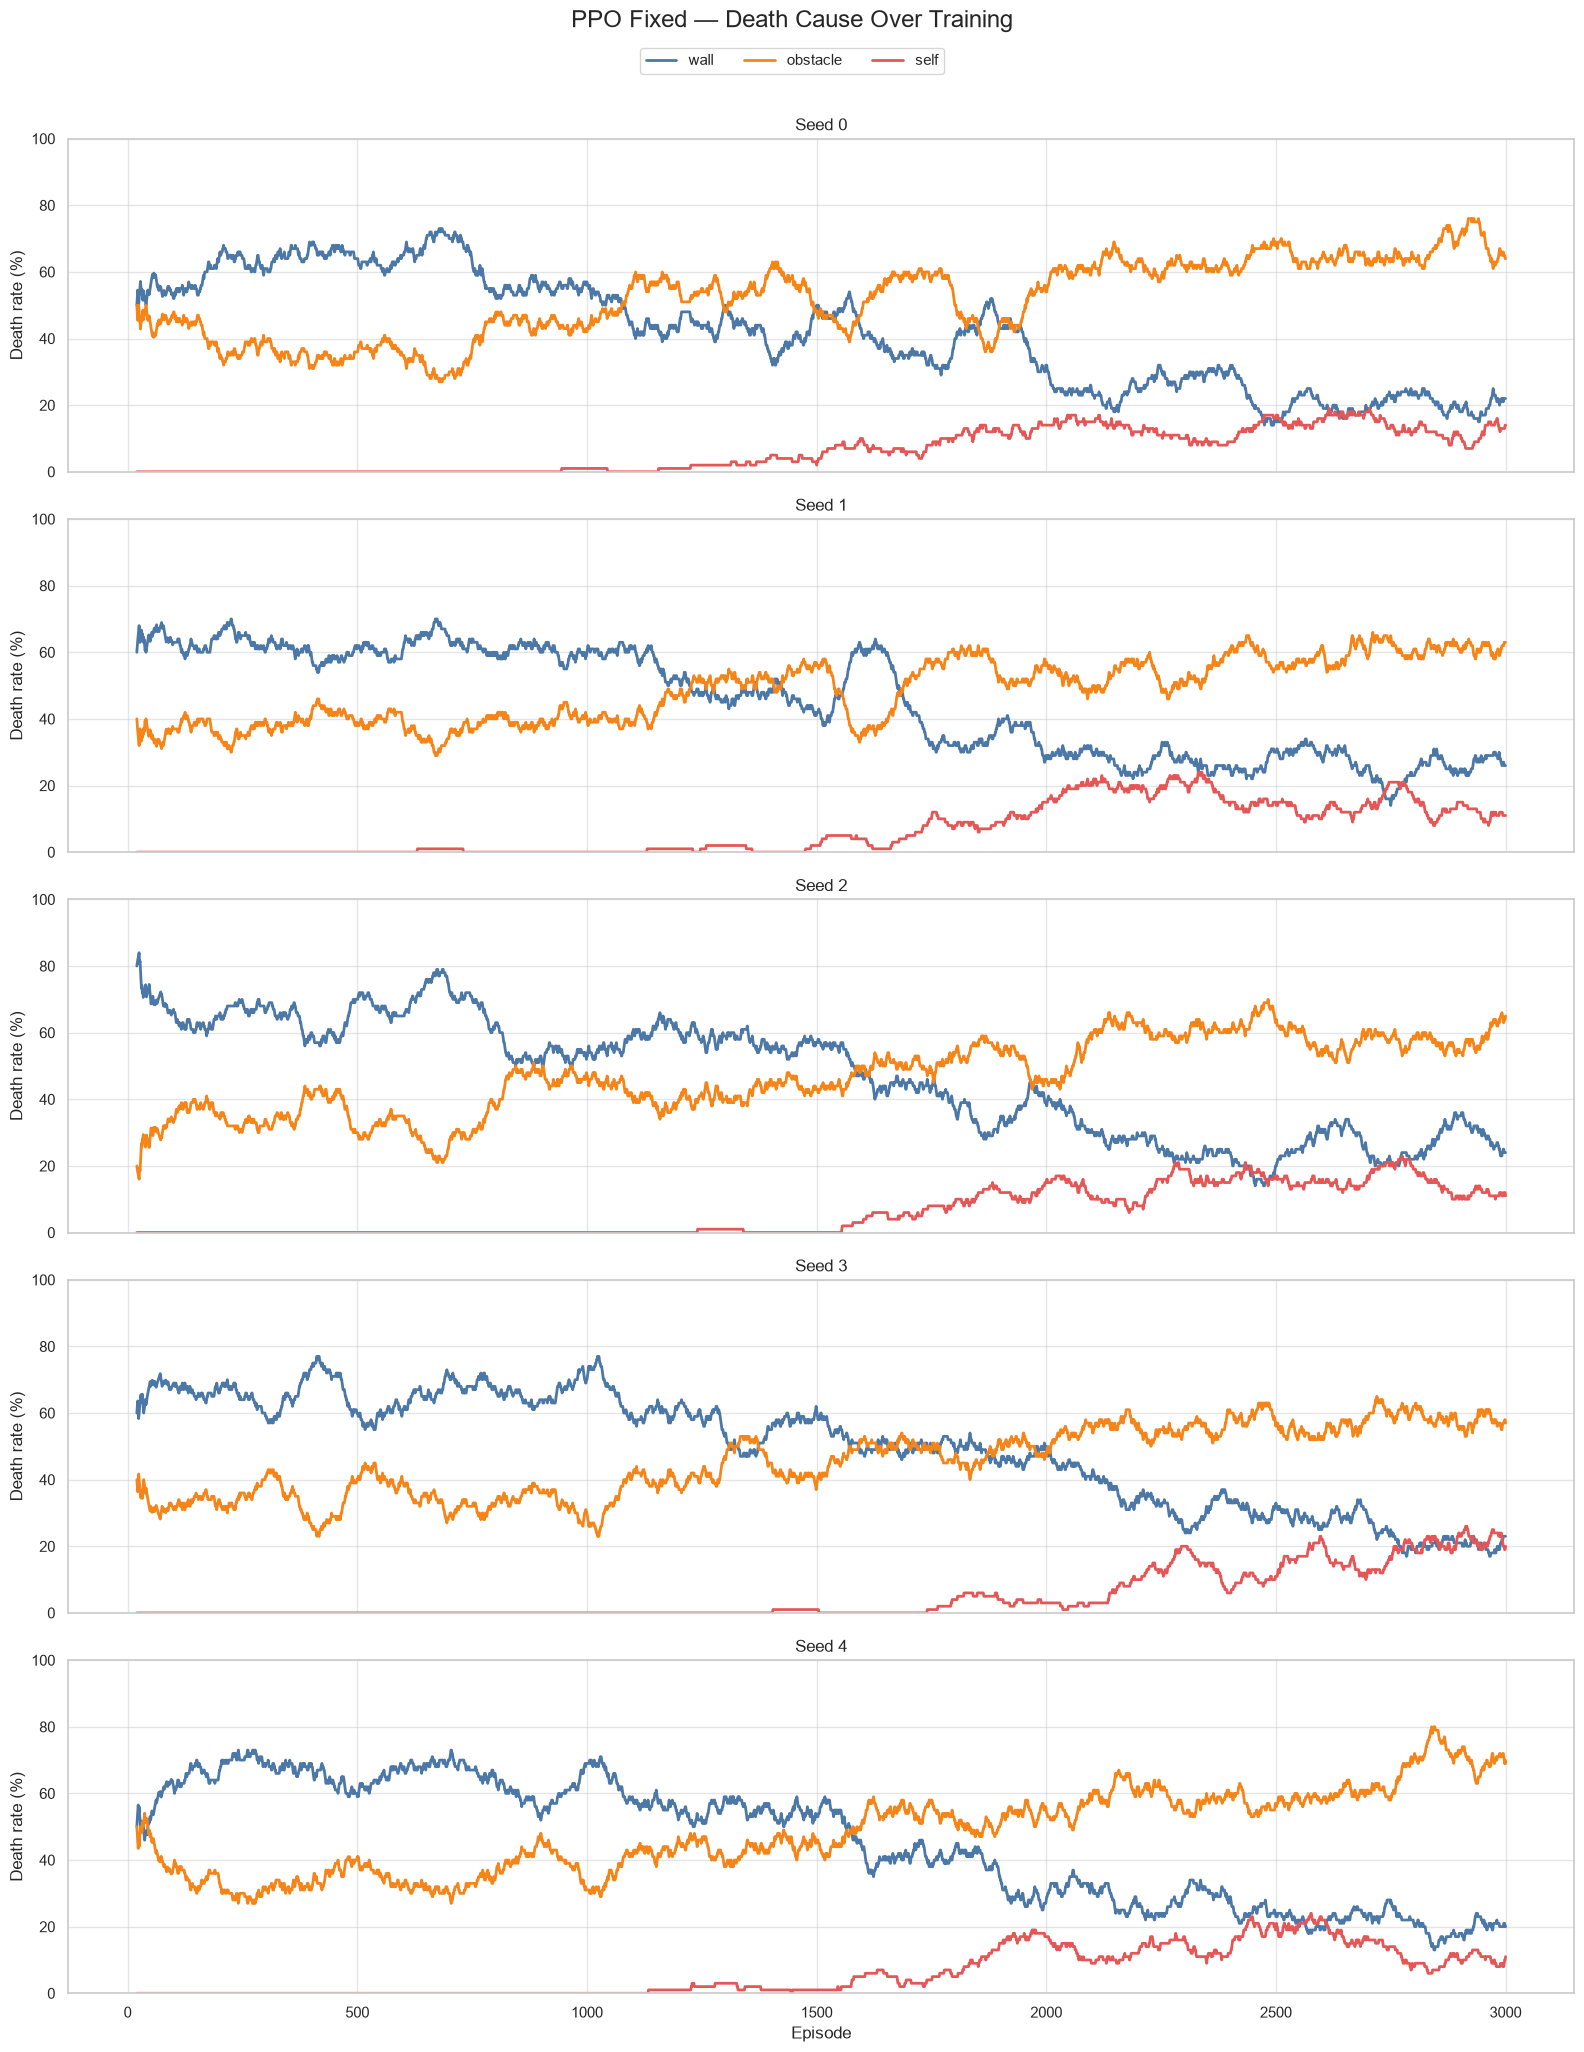

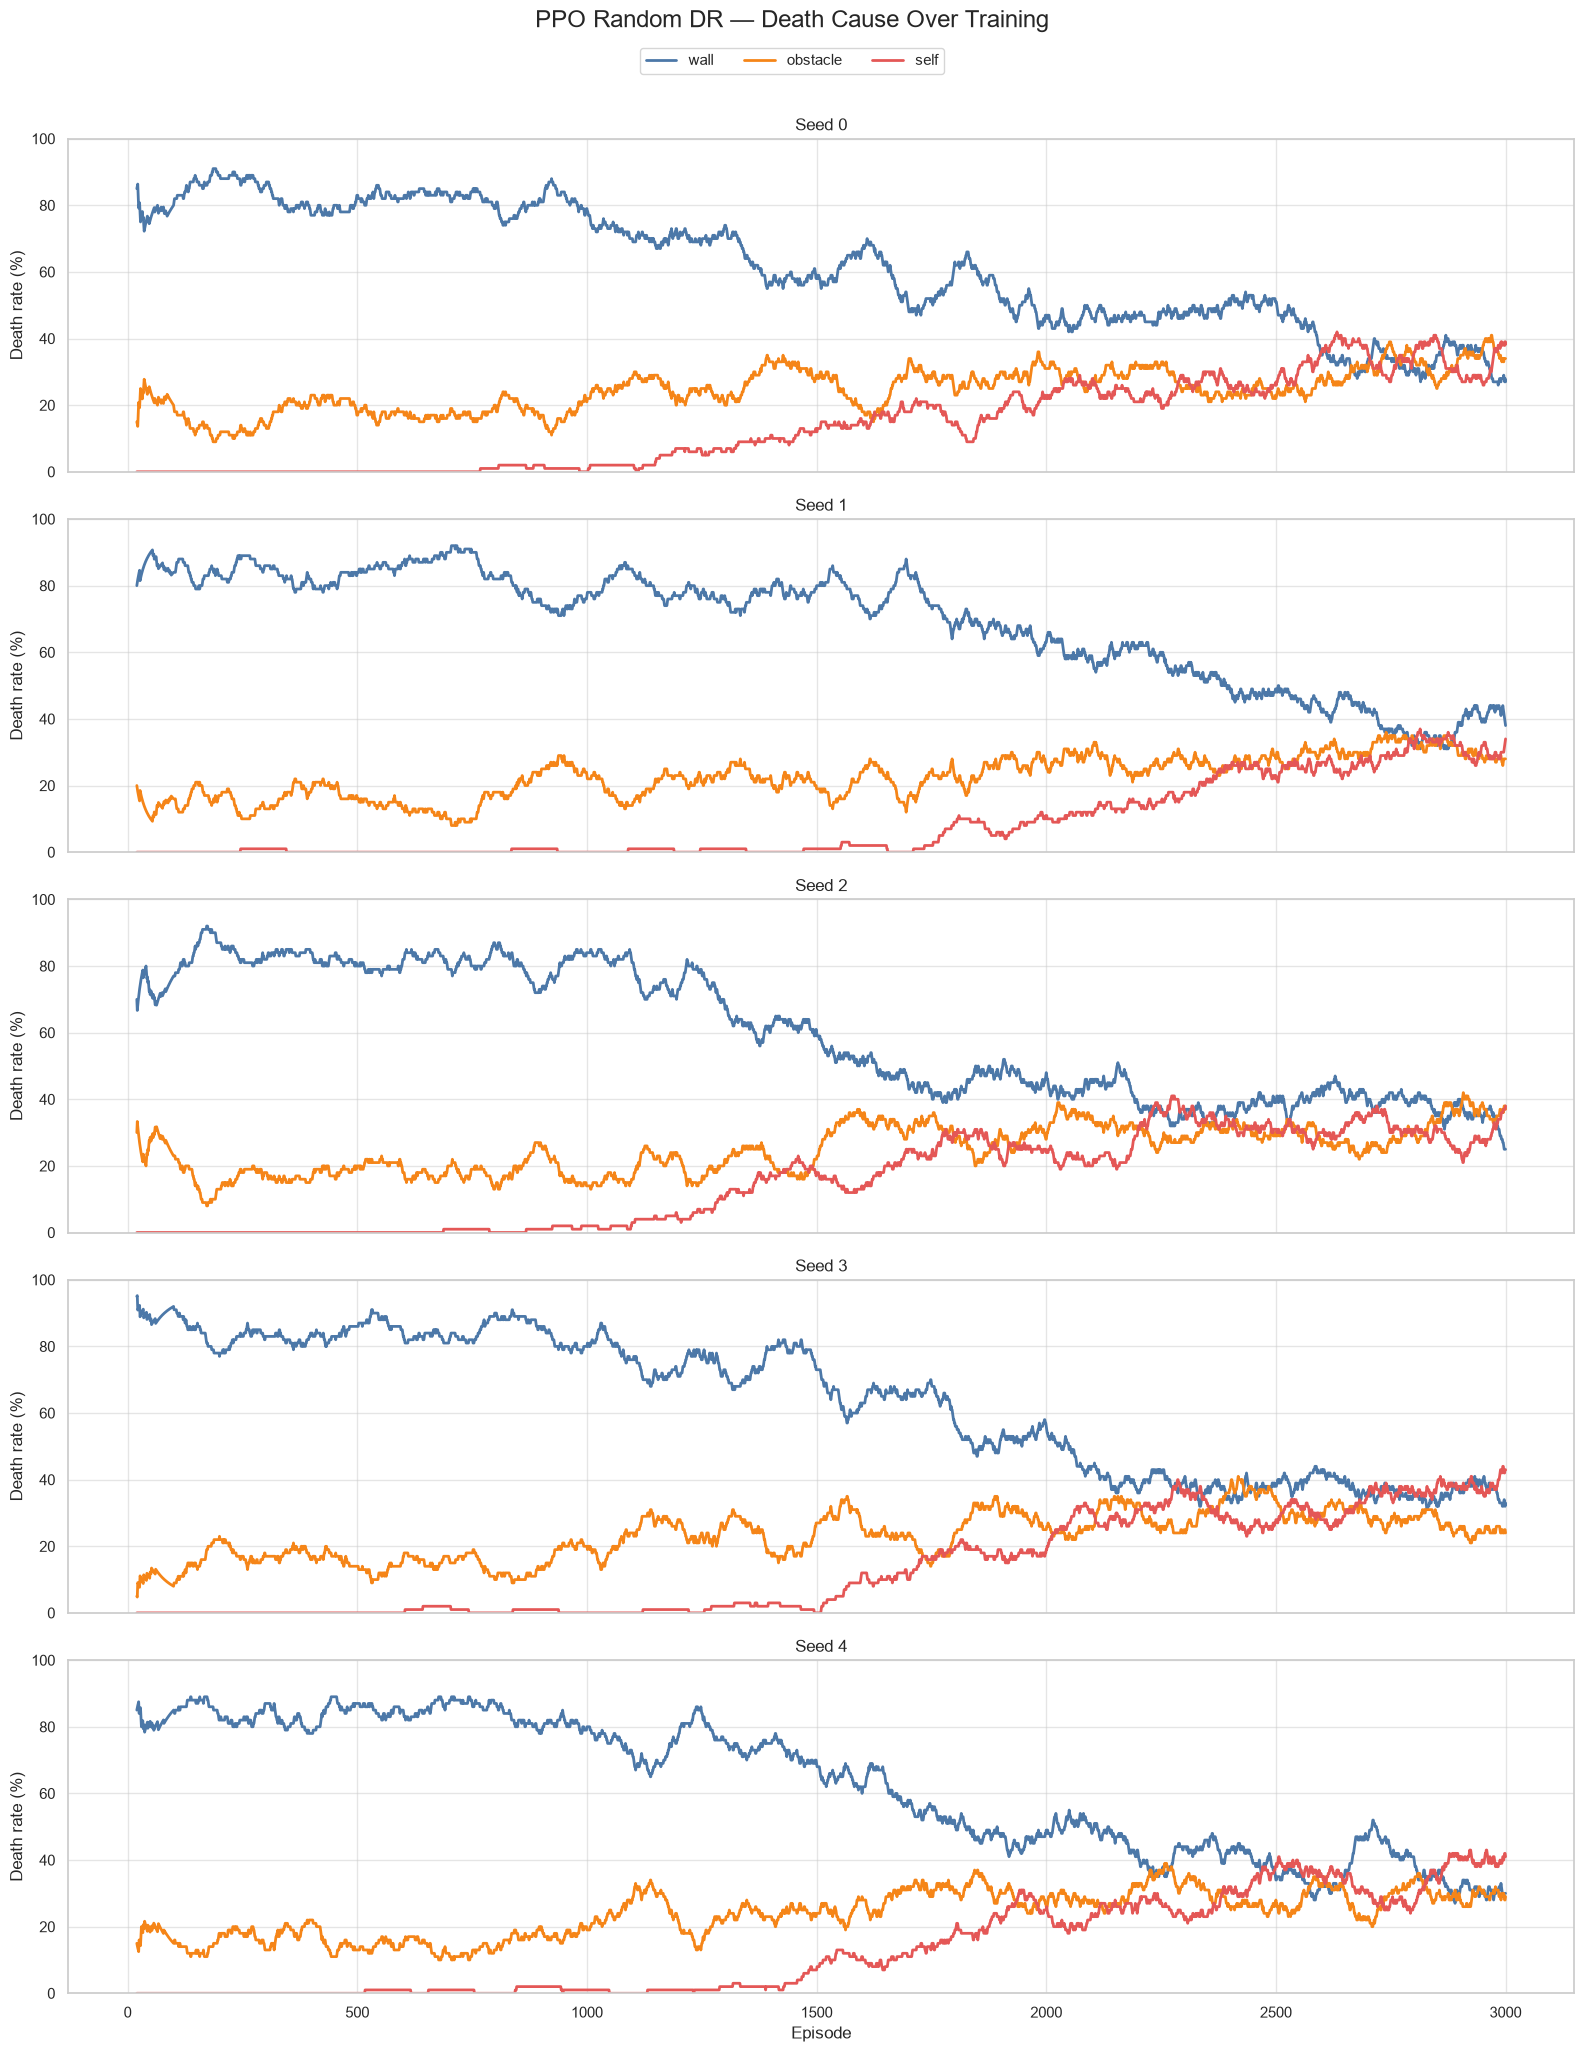

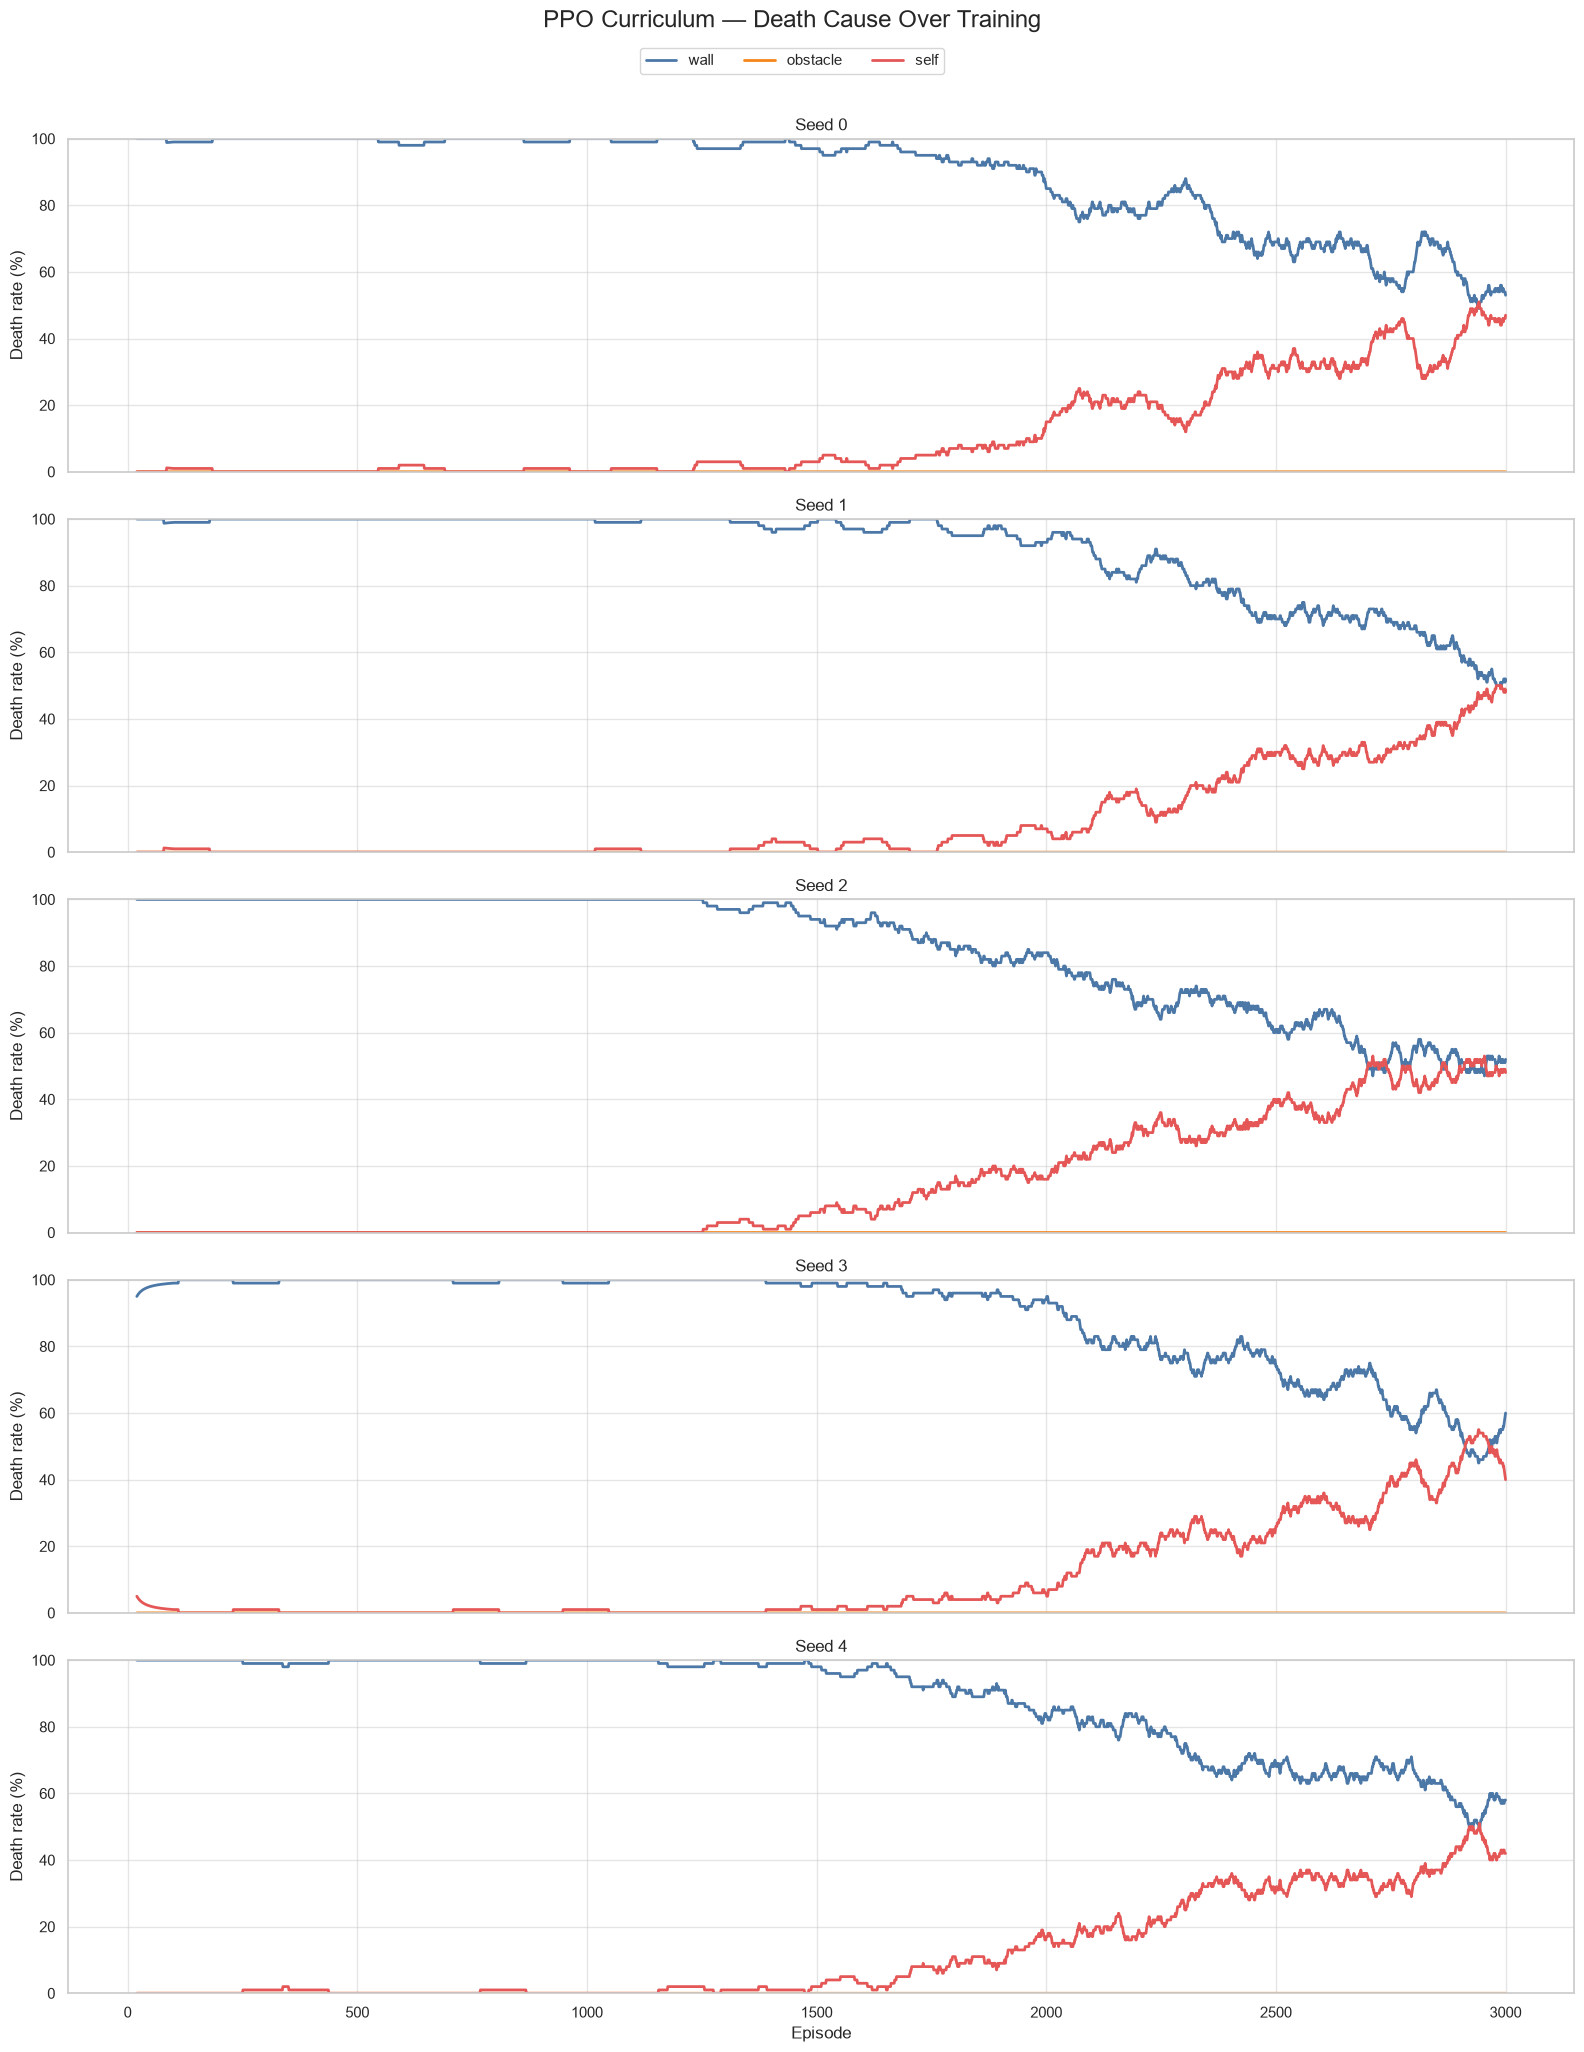

In [86]:
plot_death_causes_over_time(
    ppo_fixed,
    "PPO Fixed",
)

plot_death_causes_over_time(
    ppo_random,
    "PPO Random DR",
)

plot_death_causes_over_time(
    ppo_curriculum,
    "PPO Curriculum",
)